# Baryonic feedback in the Roman 3x2pt data vector

Feedback from active galactic nuclei and supernovae pushes gas out of halos
and suppresses the matter power spectrum on small scales. A feedback model
returns that suppression as $S(k,z)=P_{\rm hydro}/P_{\rm DMO}$, the ratio of
the nonlinear matter power with and without baryonic physics (DMO:
dark-matter only). This notebook takes six such models from the `bfmt`
theory block (`external_modules/code/baryon_suppression`), the code the
CosmoLike likelihoods call when `external_baryon_suppression` is on, and
shows how each one changes the Roman real-space 3x2pt data vector.

The notebook has two parts:

1. **Data vectors.** For each model at its fiducial parameters, the
   suppression multiplies the nonlinear power spectrum, and the notebook
   computes $C_\ell^{EE}$, $\xi_\pm(\theta)$, $C_\ell^{gs}$,
   $\gamma_t(\theta)$, the masked data vector and its $\chi^2$ against the
   stored data vector, which has no feedback.
2. **Parameter sweeps.** Each model's free parameters vary one at a time,
   and the figures show $S(k)$ at $z=0$ and $z=1$.

Terms used throughout:

- **3x2pt data vector**: $\xi_+$ and $\xi_-$ for the 36 pairs of the 8
  source bins, $\gamma_t$ for 61 lens–source pairs and $w$ for the 8 lens
  bins, each in 15 angular bins between 2.5 and 250 arcmin: 2,115 entries.
  The **mask**, a 0/1 list over the data vector, keeps the 1,950 entries the
  likelihood uses.
- **SP(k)**: a semi-analytical model that predicts the suppression from the
  baryon fraction of halos as a function of their mass.
- **Emulator**: a fast fitted replacement for an expensive calculation.
  BCEmu and BCemu2025 emulate baryonification models; the FLAMINGO emulator
  emulates the FLAMINGO hydrodynamical simulations.
- **Cobaya**: the sampler framework whose theory blocks (CAMB, `bfmt`)
  compute the quantities a likelihood requests.

The `bfmt` packages must be installed; see the project's
[baryonic-feedback instructions](README.md#roman_baryonic_feedback). The
sweeps run CAMB about 130 times and take tens of minutes.

## Set up the Python session

The first cell imports the libraries and sets the figure style; the second
puts CAMB, the shared notebook package and this project's wrappers on the
Python path.

- `ci` is `cosmolike_roman_real_interface`, the compiled C/C++ library of
  this project: the same code the Cobaya likelihood calls.
- `cnu` is `cosmolike_notebook_utils`, shared by every Cocoa project
  (`external_modules/code/cosmolike_core/cosmolike_notebook_utils`): the
  CAMB run, the data-vector and response-function plots, and the Fisher
  tools.
- `nw` is `cosmolike_roman_real_notebook_wrappers`, in this project's
  `interface/` folder: one Python function per observable, each returning
  NumPy arrays.
- `matplotlib.rcParams` is matplotlib's global style dictionary; the values
  set here apply to every later figure. `text.usetex = True` typesets the
  labels with LaTeX, which must be installed (the cell lists the packages).
- `OMP_NUM_THREADS` sets how many OpenMP threads the compiled loops use; it
  is set before the library is imported, so the OpenMP runtime reads it
  when it starts.
- Importing `euclidemu2` prints a notice that CLASS (`classy`) is missing.
  The EuclidEmulator2 boost used here does not need CLASS.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
# OpenMP threads of the compiled CosmoLike loops; set before the
# library is imported.
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
# euclidemu2 prints a notice that classy (CLASS) is missing; the
# EuclidEmulator2 boost used here does not need it.
import euclidemu2
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
from scipy.interpolate import interp1d
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# Figure style: matplotlib.rcParams is the global style dictionary that
# every later figure reads.
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# usetex typesets every label with LaTeX. It needs the system packages
# texlive-latex-base, texlive-latex-extra, texlive-fonts-recommended,
# dvipng, ghostscript and cm-super; set it to False without them.
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.


3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real


In [2]:
# Import CAMB. The path below is CAMB's Linux build folder; elsewhere
# Python finds the installed camb package, and the print shows which.
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# Import the shared notebook utilities (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


# Import the project's notebook wrappers (projects/roman_real/interface):
# the probe, chi2, response, Fisher, and bfmt wrappers every notebook
# of this project shares
import cosmolike_roman_real_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real/interface/cosmolike_roman_real_notebook_wrappers.py


## Choose the settings the wrappers read

`nw.configure` stores the values that differ between this project's
notebooks; every later wrapper call reads them:

- `lmax`: the largest multipole of the internal $C_\ell$ tables that the
  Legendre sums to real space use (100,000, as in EXAMPLE_EVALUATE2.yaml).
- `ntheta`, `theta_min_arcmin`, `theta_max_arcmin`: 15 logarithmic angular
  bins between 2.5 and 250 arcmin, as in the dataset file.
- `non_linear_emul`: the nonlinear matter power spectrum, 2 for CAMB's
  halofit (Takahashi version) and 1 for EuclidEmulator2.

`CLprobe = "3x2pt"` is passed to `nw.init_cosmolike` below. The other names
in the cell restate settings that the wrappers already hold; nothing reads
these notebook variables. The data-file and intrinsic-alignment options
(`path`, `data_file`, `ggl_exclude`, `IA_model`, `IA_redshift_evolution`,
`IA_code`) change through `nw.configure` before `nw.init_cosmolike` runs.

In [3]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="3x2pt"

path= "../../external_modules/data/roman_real"
data_file="example1.dataset"
ggl_exclude=[[6,0],[7,0],[7,1]]

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

ntheta = 15
theta_min_arcmin = 2.5 
theta_max_arcmin = 250
lmax = 100000


# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(lmax=lmax,
             ntheta=ntheta,
             theta_min_arcmin=theta_min_arcmin,
             theta_max_arcmin=theta_max_arcmin,
             non_linear_emul=non_linear_emul)

## The fiducial parameter point

The wrappers module defines one fiducial point, the
`sampler: evaluate: override` values of the example YAML files. This cell
imports the names so the sweeps below can build shifted vectors from them.
Every wrapper also uses them as defaults, and a call overrides any of them,
for example `nw.C_ss_tomo_limber(ell=ell, omegam=0.31)`.

| Name | Meaning | Fiducial |
| --- | --- | --- |
| `As_1e9` | $10^9 A_s$, amplitude of the primordial power spectrum | 2.1 |
| `ns` | scalar spectral index $n_s$ | 0.96605 |
| `H0` | Hubble constant in km/s/Mpc | 67.32 |
| `omegab`, `omegam` | $\Omega_b$ and $\Omega_m$ (matter includes massive neutrinos) | 0.04, 0.3 |
| `mnu` | sum of the neutrino masses in eV | 0.06 |
| `w`, `w0pwa` | dark-energy $w_0$ and $w_0+w_a$ | −1, −1 |
| `roman_A1_1`, `roman_A1_2` | NLA amplitude $A_{\rm IA}$ and its redshift index $\eta_{\rm IA}$ | 0.6, −1.5 |
| `roman_DZ_S1` … `roman_DZ_S8` | redshift shifts of the 8 source $n(z)$ (source photo-z) | 0 |
| `roman_M1` … `roman_M8` | multiplicative shear calibration $m$ of each source bin | 0 |
| `roman_DZ_L1` … `roman_DZ_L8` | redshift shifts of the 8 lens $n(z)$ (lens photo-z) | 0 |
| `roman_B1_1` … `roman_B1_8` | linear galaxy bias $b_1$ of each lens bin | 1.18 … 2.44 |
| `roman_PM1` … `roman_PM8` | point-mass amplitudes of $\gamma_t$, one per lens bin | 0 |

`nw.compute_probes` evaluates every observable at this point, with the 
fiducial nuisance parameters.

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_roman_real_notebook_wrappers.py), shared by
# every notebook. The names are imported so the sweep cells below can
# build shifted vectors from them; override any value per call
# instead, e.g. nw.get_chi2(omegam=0.31).
from cosmolike_roman_real_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    roman_A1_1, roman_A1_2,
    roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4,
    roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8,
    roman_M1, roman_M2, roman_M3, roman_M4,
    roman_M5, roman_M6, roman_M7, roman_M8,
    roman_DZ_L1, roman_DZ_L2, roman_DZ_L3, roman_DZ_L4,
    roman_DZ_L5, roman_DZ_L6, roman_DZ_L7, roman_DZ_L8,
    roman_B1_1, roman_B1_2, roman_B1_3, roman_B1_4,
    roman_B1_5, roman_B1_6, roman_B1_7, roman_B1_8,
    roman_PM1, roman_PM2, roman_PM3, roman_PM4,
    roman_PM5, roman_PM6, roman_PM7, roman_PM8)

## Initialize CosmoLike

`nw.init_cosmolike` reads [data/example1.dataset](data/example1.dataset),
a short text file that names the redshift distributions (one file,
`example1.nz`, serves lenses and sources), the covariance, the mask and
the data vector, and gives the angular binning. It then installs the excluded
galaxy–galaxy-lensing pairs, the 8 lens and 8 source $n(z)$ tables, the
angular binning and the intrinsic-alignment model (NLA with power-law
redshift evolution). With `CLprobe="3x2pt"` and `with_data=True` it also
selects $\xi_\pm$, $\gamma_t$ and $w$, installs the galaxy-bias model, and
loads the stored data vector, the covariance and the mask that
$\chi^2$ needs. The printed lines list the three lens–source pairs removed
from $\gamma_t$, counted from 0.

In [5]:
# Init Cosmolike for the masked 3x2pt data vector (the full
# sequence lives in nw.init_cosmolike)
ini = nw.init_cosmolike(CLprobe=CLprobe, with_data=True)
allsims = nw.allsims

[2026-10-08 02:33:19.162] [info] init_ntomo_powerspectra: GGL pair L6-S0 is excluded
[2026-10-08 02:33:19.162] [info] init_ntomo_powerspectra: GGL pair L7-S0 is excluded


[2026-10-08 02:33:19.162] [info] init_ntomo_powerspectra: GGL pair L7-S1 is excluded


## The baryonic feedback methods of the `bfmt` theory block

The `bfmt` theory block (`external_modules/code/baryon_suppression`)
implements seven ways to compute the suppression
$S(k, z) = P_{\rm hydro}/P_{\rm DMO}$ of the nonlinear matter power
spectrum: three semi-analytical SP(k) baryon-fraction relations and four
emulators. Instead of re-implementing any of them here, this notebook drives
the block itself through a minimal Cobaya model: CAMB, `bfmt` and Cobaya's
`one` likelihood, a constant placeholder that lets the model run the theory
blocks. The model requests the suppression on the $(z, k)$ nodes of the
notebook's CAMB tables, and the same `bfmt` code computes it that the
CosmoLike likelihoods call in an MCMC run.

The next cell lists the methods with their `bfmt` options and fixed
parameter values; its comment explains why BACCOemu is left out. The two
cells after it record where the wrappers used below are defined.

In [6]:
# One entry per feedback method: (label, bfmt options, fixed parameter
# point). The SP(k) points are pyspk's documented examples; the emulator
# points are the fiducial values quoted in the example yamls. BACCOemu
# is commented out on this project: its omega_baryon training box
# starts at 0.04001, exactly above this notebook's omegab = 0.04, so
# the block (correctly) rejects the fiducial.
BARYON_METHODS = [
    ("SP(k) power law", {"baryon_model": 1, "spk_fb_model": 1},
     {"fb_a_spk": 0.4, "fb_pow_spk": 0.3}),
    ("SP(k) Akino et al. 2022", {"baryon_model": 1, "spk_fb_model": 2},
     {"alpha_spk": 4.189, "beta_spk": 1.273, "gamma_spk": 0.298}),
    # this point matches the Akino relation's amplitude at the pivot
    # and stays inside SP(k)'s calibrated baryon-fraction band over
    # the full z grid; pyspk's documented example (0.3, 1.1, 0.2,
    # 0.5) exits the band at z >~ 1.4, and the block then falls back
    # to unity for those redshifts
    ("SP(k) double power law", {"baryon_model": 1, "spk_fb_model": 3},
     {"epsilon_spk": 0.66, "alpha_spk": 0.35, "beta_spk": 0.2,
      "gamma_spk": 0.3}),
    ("BCEmu", {"baryon_model": 2},
     {"log10Mc_bcemu": 13.32, "mu_bcemu": 0.93, "thej_bcemu": 4.235,
      "gamma_bcemu": 2.25, "delta_bcemu": 6.40, "eta_bcemu": 0.15,
      "deta_bcemu": 0.14}),
    ("Flamingo", {"baryon_model": 3},
     {"fgas_sigma_flamingo": 0.0, "mstar_sigma_flamingo": 0.0,
      "jet_frac_flamingo": 0.0}),
    #("BACCOemu", {"baryon_model": 4},
    # {"M_c_baccoemu": 14.0, "eta_baccoemu": -0.3, "beta_baccoemu": -0.22,
    #  "M1_z0_cen_baccoemu": 10.5, "theta_inn_baccoemu": -0.86}),
    ("BCemu2025", {"baryon_model": 5},
     {"Theta_co_bcemu25": 0.3, "log10Mc_bcemu25": 13.1, "mu_bcemu25": 1.0,
      "delta_bcemu25": 6.0, "eta_bcemu25": 0.10, "deta_bcemu25": 0.22,
      "Nstar_bcemu25": 0.028}),
]


In [7]:
# get_baryon_suppression lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.get_baryon_suppression.

In [8]:
# compute_probes lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.compute_probes.

## Compute the data vector without and with each feedback method

`nw.compute_probes()` runs, once, the stages of a likelihood evaluation:

1. **CAMB.** `cnu.get_camb_cosmology` computes the linear and nonlinear
   matter power spectra, the growth factor and the distances at the
   fiducial cosmology.
2. **Feedback.** With `sup` given, it adds $\ln S$ to $\ln P_{\rm NL}$ at
   every redshift of the CAMB grid, the operation the likelihood performs.
3. **set_cosmology.** `ci.set_cosmology` copies the tables into the C
   library.
4. **Nuisance setters.** `ci.set_nuisance_shear_calib`,
   `ci.set_nuisance_shear_photoz`, `ci.set_nuisance_clustering_photoz`,
   `ci.set_nuisance_ia`, `ci.set_nuisance_bias` and `ci.set_point_mass`
   install the fiducial nuisance parameters.
5. **Observables.** It returns a dictionary with $C_\ell^{EE}$ and
   $C_\ell^{gs}$ for $\ell$ from 25 to 2,995 in steps of 15, $\xi_\pm$ and
   $\gamma_t$ in the 15 angular bins, the masked data vector (2,115
   positions, masked entries set to zero), its $\chi^2$ against the stored
   data vector, and the $(z, k)$ grid of the CAMB tables.

`nw.get_baryon_suppression` evaluates one method on that grid through
Cobaya and returns $\{z: S(k)\}$. The printed $\chi^2$ measures how far each
method's suppression moves the prediction away from the feedback-free data
vector, in units of the Roman covariance.

In [9]:
ref = nw.compute_probes()
print("no feedback: chi2 = %.6f, data vector length = %d" % (ref["chi2"], len(ref["dv"])))

no feedback: chi2 = 0.503095, data vector length = 2115


In [10]:
results = {}
for label, theory_options, point in BARYON_METHODS:
    sup = nw.get_baryon_suppression(theory_options, point,
                                 ref["z_grid"], ref["log10k_grid"])
    results[label] = nw.compute_probes(sup = sup)
    print("%-28s chi2 = %10.4f" % (label, results[label]["chi2"]),
          flush=True)


SP(k) power law              chi2 =   987.1987


SP(k) Akino et al. 2022      chi2 =   453.3026


SP(k) double power law       chi2 =   446.2219


BCEmu                        chi2 =   464.7701


Flamingo                     chi2 =   194.7943


Loading BCemu2025 models (backend='numpy')...


Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

...BCemu2025 emulator is ready.


BCemu2025                    chi2 =    57.0192


## Save the data vectors

The table has one row per entry of the full 2,115-entry data vector, with
the masked entries equal to zero, and one column per prediction: no
feedback first, then one column per method, in the order of
`BARYON_METHODS`. The cell saves it as a text file with a header line,
`chains/EXAMPLE_EVALUATE3.datavectors`, and prints six sample rows. The
previous cell printed the $\chi^2$ of each column.

In [11]:
chains_dir = os.environ["ROOTDIR"] + "/projects/roman_real/chains"
os.makedirs(chains_dir, exist_ok=True)
table = np.column_stack([ref["dv"]] +
                        [results[label]["dv"] for label, _, _ in BARYON_METHODS])
header = "no_feedback " + " ".join(
    label.replace(" ", "_") for label, _, _ in BARYON_METHODS)
np.savetxt(chains_dir + "/EXAMPLE_EVALUATE3.datavectors",
           table, header=header)
print(header)
for i in (0, 1, 2, len(table)//2, len(table)-2, len(table)-1):
    print(("%6d" % i) + "".join(" %.6e" % v for v in table[i]))
print("full table saved to " + chains_dir + "/EXAMPLE_EVALUATE3.datavectors")


no_feedback SP(k)_power_law SP(k)_Akino_et_al._2022 SP(k)_double_power_law BCEmu Flamingo BCemu2025
     0 7.234410e-06 6.562474e-06 6.714927e-06 6.715986e-06 6.755597e-06 6.854301e-06 7.200272e-06
     1 5.861868e-06 5.390592e-06 5.500059e-06 5.500476e-06 5.533962e-06 5.631595e-06 5.879183e-06
     2 4.624386e-06 4.317119e-06 4.391698e-06 4.391831e-06 4.417772e-06 4.498772e-06 4.661477e-06
  1057 3.138272e-05 3.051913e-05 3.084711e-05 3.084935e-05 3.078182e-05 3.115742e-05 3.143586e-05
  2113 -3.100394e-05 -3.100440e-05 -3.100586e-05 -3.100587e-05 -3.100397e-05 -3.100144e-05 -3.100483e-05
  2114 -1.375413e-05 -1.375434e-05 -1.375519e-05 -1.375519e-05 -1.375411e-05 -1.375220e-05 -1.375344e-05
full table saved to /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real/chains/EXAMPLE_EVALUATE3.datavectors


## Cosmic shear with feedback: $C_\ell^{EE}$

Each panel shows a method's $C_\ell^{EE}$ relative to the prediction without
feedback, $C_\ell/C_\ell^{\rm DMO}-1$, for $\ell$ from 25 to 3,000, in a band
from −18% to +5% (`ylim=(0.82, 1.05)`). The colors index the methods in the
order of `BARYON_METHODS`, and the legend names them. Panel labels in the
stored figures start at (0,0); running the cell again labels them from
(1,1), the package convention (array index + 1).

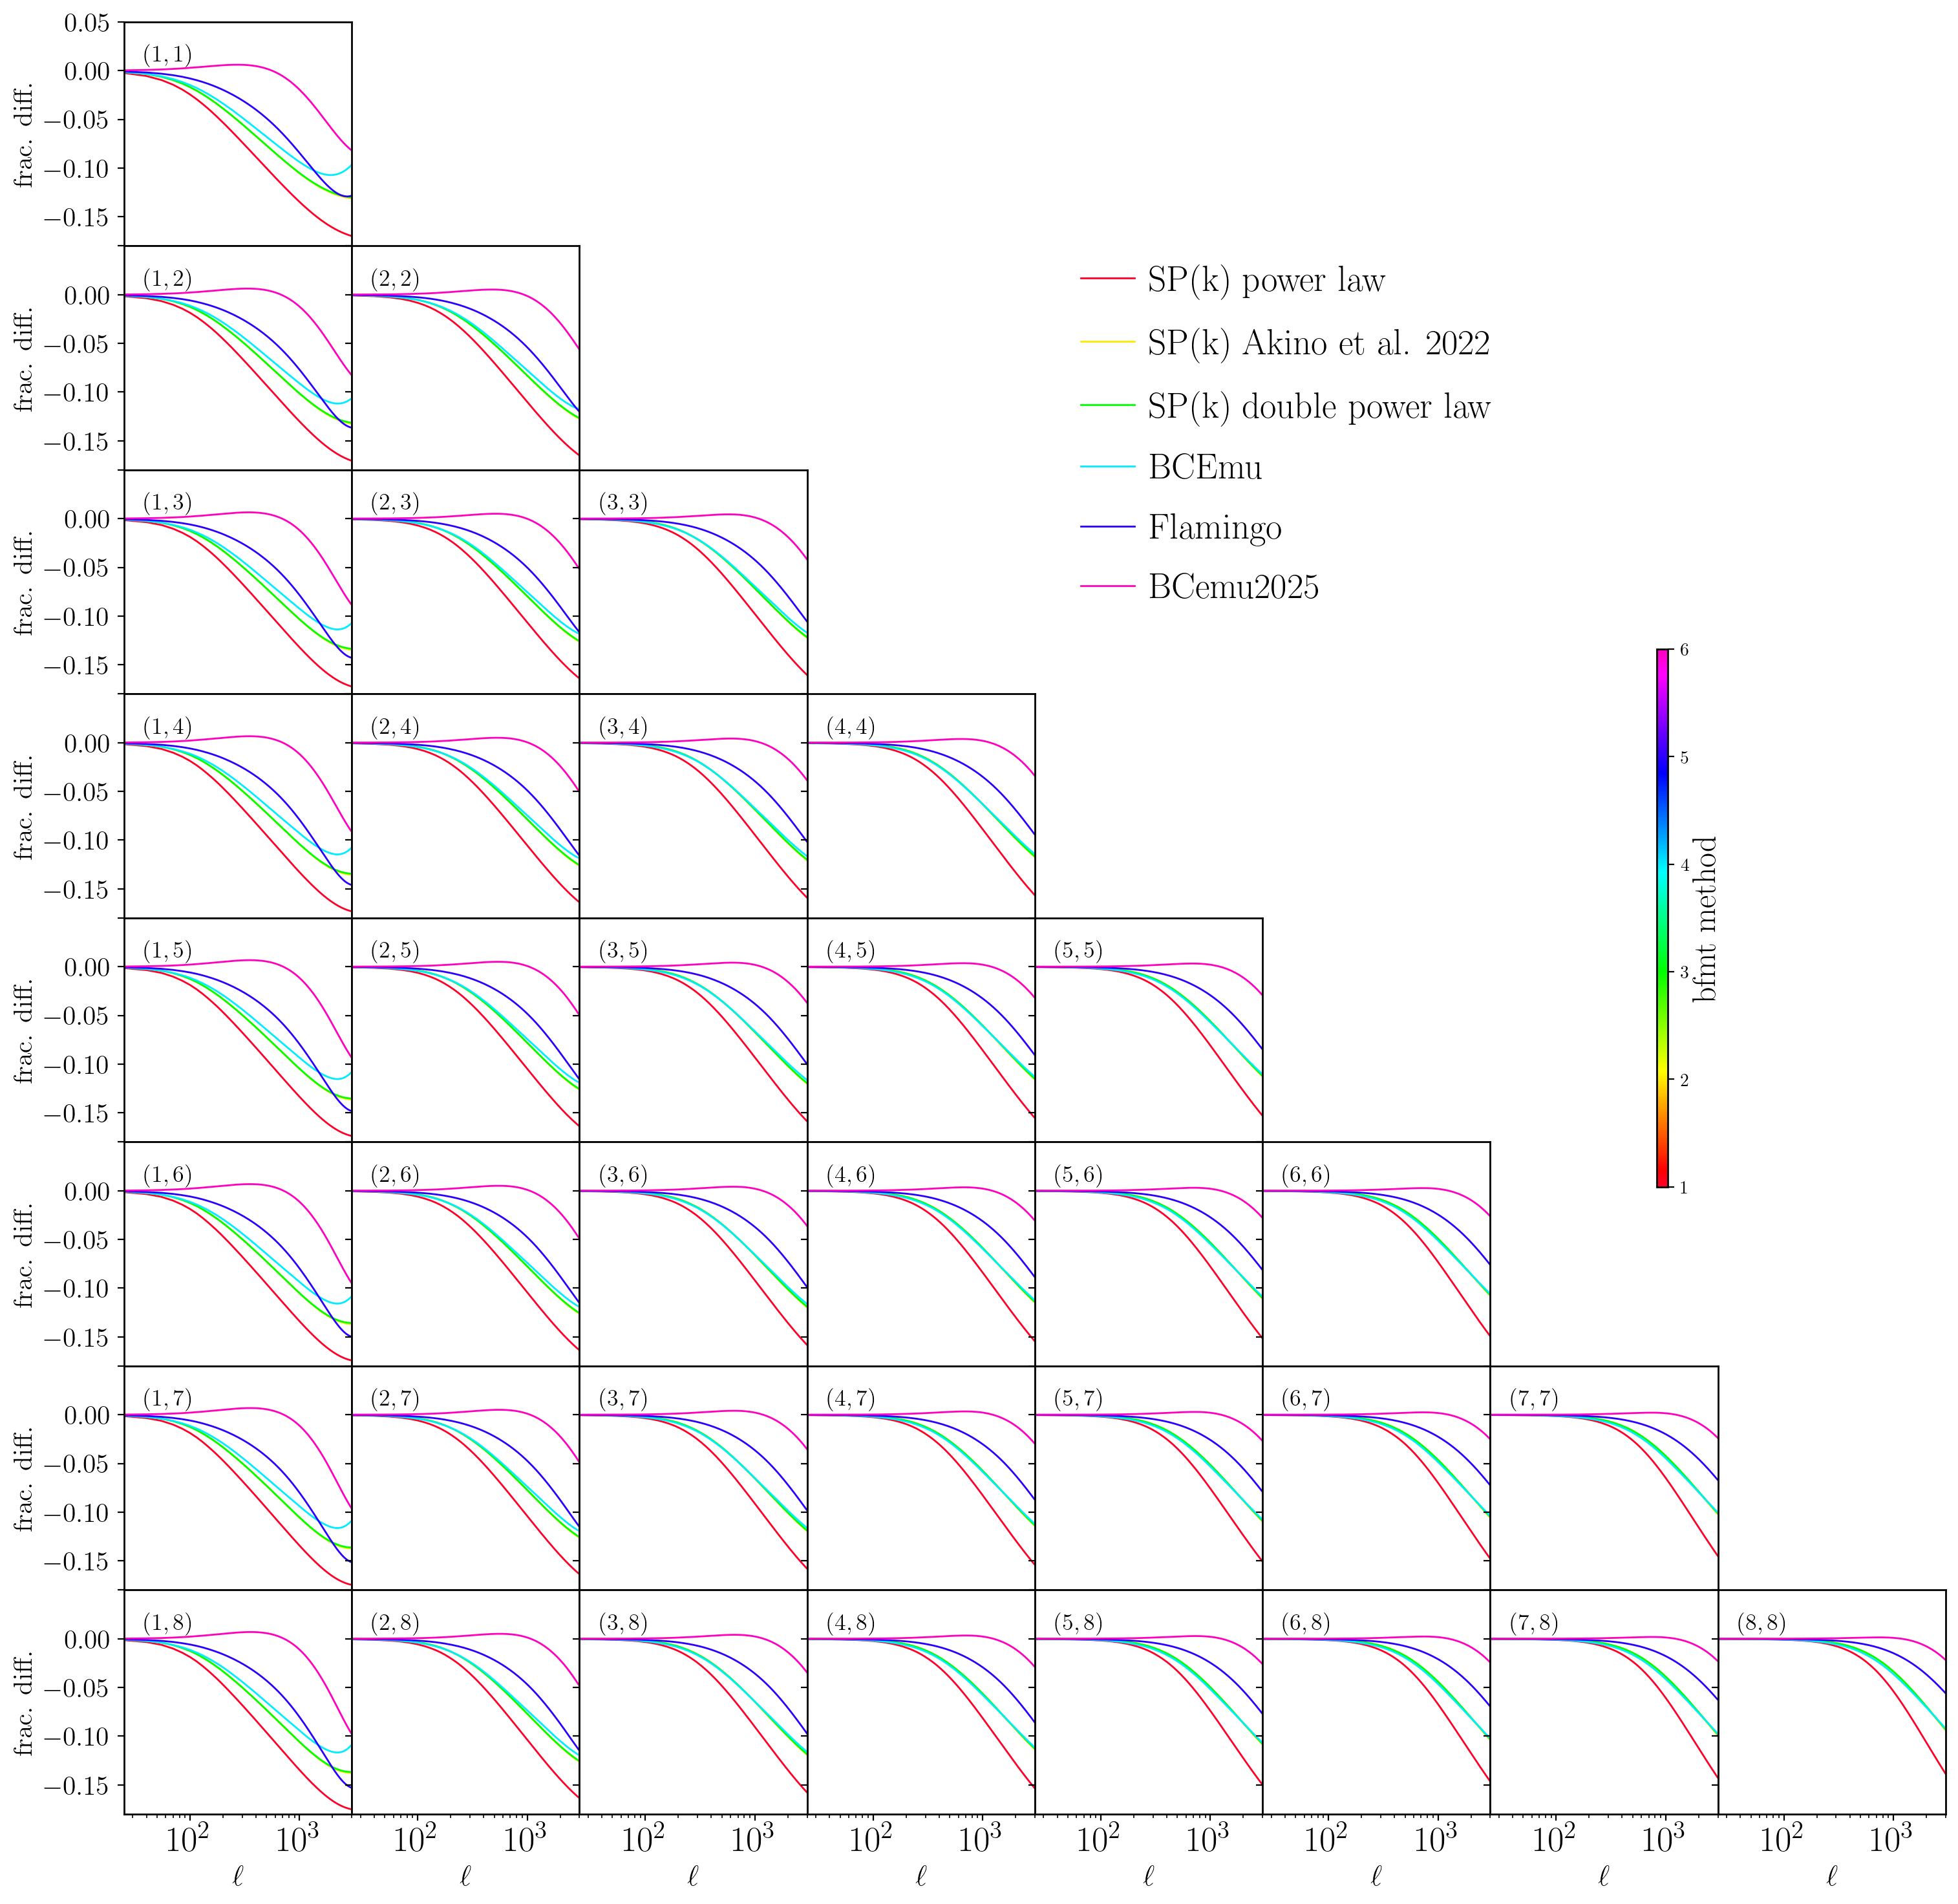

In [12]:
labels = [label for label, _, _ in BARYON_METHODS]

param = np.arange(1.0, 1.0 + len(labels))

C_ss_list = [results[label]["C_ss"] for label in labels]

cnu.plot_C_ss_tomo_limber(ell=ref["ell"],
                          C_ss=C_ss_list,
                          C_ss_ref=ref["C_ss"],
                          param=param,
                          lmin=25,
                          lmax=3000,
                          ylim=(0.82, 1.05),
                          colorbarlabel="bfmt method",
                          legend=labels,
                          figsize=(18, 18),
                          legendloc=(0.55, 0.68),
                          legendfontsize=20,
                          xaxisticklabelsize=20,
                          yaxisticklabelsize=15,
                          yaxislabelsize=15)

## Cosmic shear with feedback: $\xi_\pm(\theta)$

The same comparison in real space: $\xi_+$ (`pm=1`) and then $\xi_-$
(`pm=0`), between 2.5 and 250 arcmin, in a band from −12.5% to +5%. At a
given angle $\xi_-$ probes smaller scales than $\xi_+$, so feedback reaches
it out to larger angles.

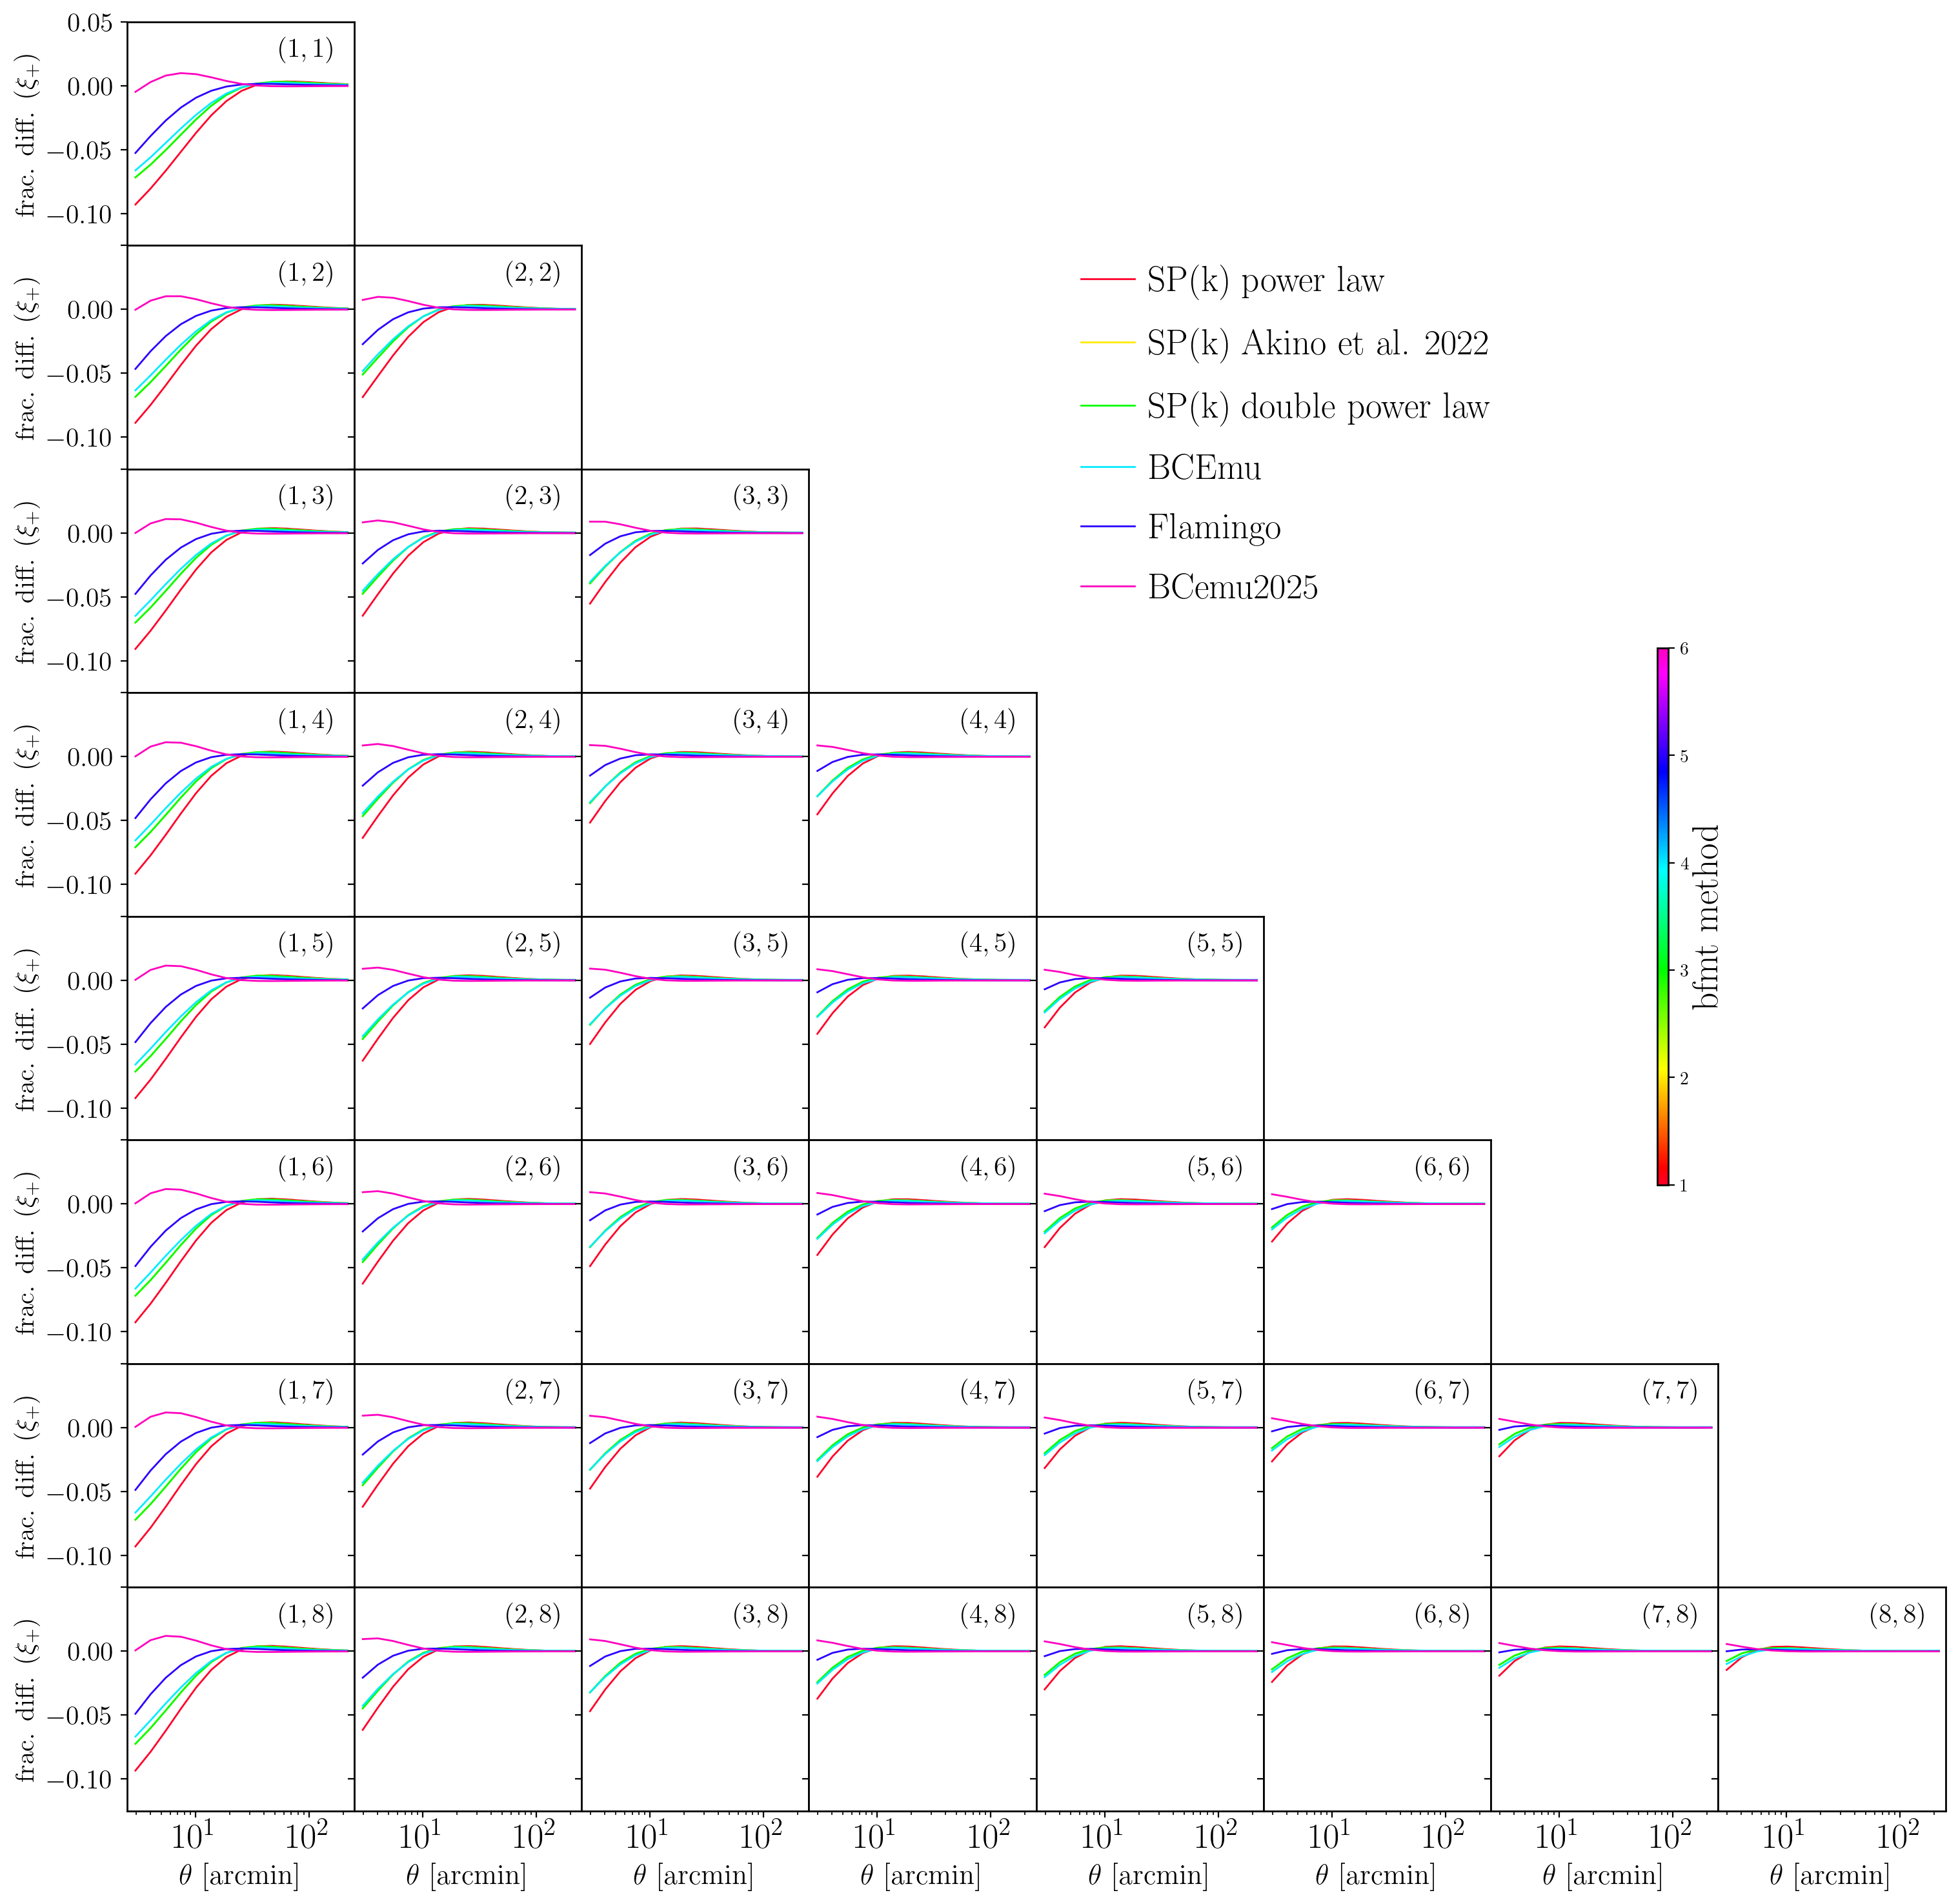

In [13]:
xi_list = [(results[label]["theta"], results[label]["xip"],
            results[label]["xim"]) for label in labels]

xi_ref = (ref["theta"], ref["xip"], ref["xim"])

cnu.plot_xi(pm=1,
            xi=xi_list,
            xi_ref=xi_ref,
            param=param,
            ylim=(0.875, 1.05),
            colorbarlabel="bfmt method",
            legend=labels,
            thetashow=[2.5, 250],
            legendloc=(0.55, 0.68),
            legendfontsize=20,
            xaxisticklabelsize=20,
            yaxisticklabelsize=15,
            yaxislabelsize=15)

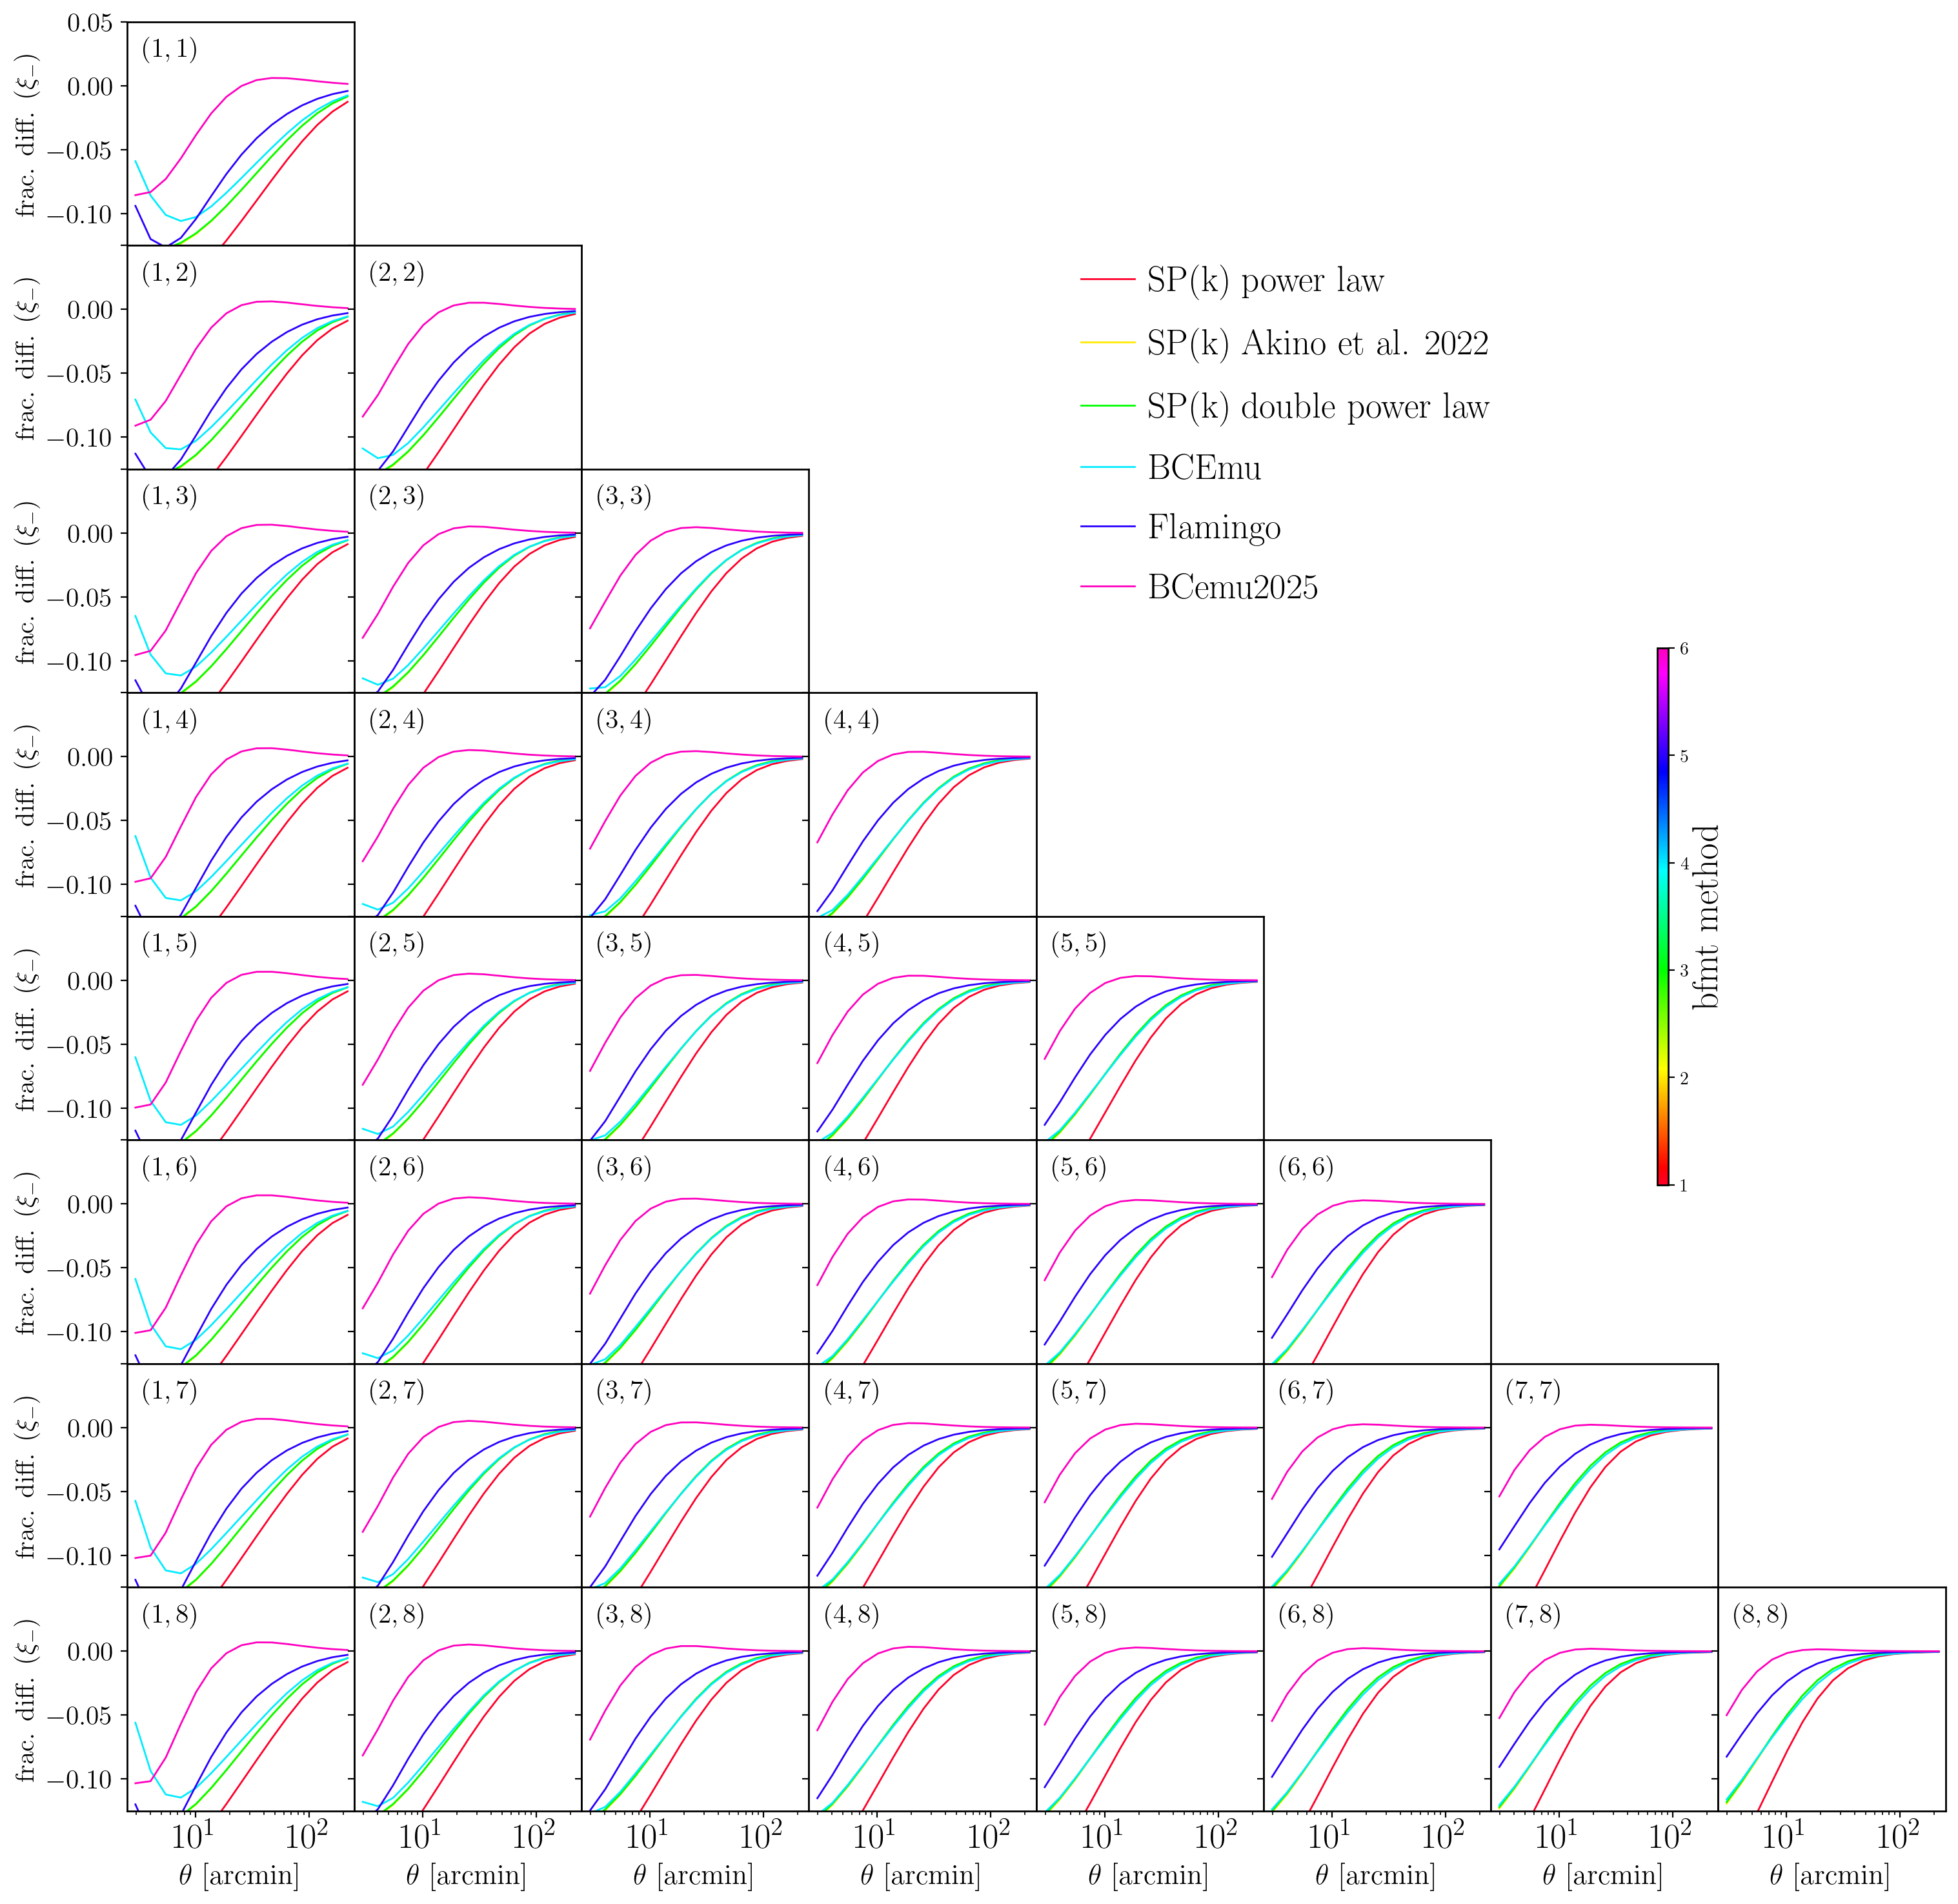

In [14]:
cnu.plot_xi(pm=0,
            xi=xi_list,
            xi_ref=xi_ref,
            param=param,
            ylim=(0.875, 1.05),
            colorbarlabel="bfmt method",
            legend=labels,
            figsize=(18, 18),
            thetashow=[2.5, 250],
            legendloc=(0.55, 0.68),
            legendfontsize=20,
            xaxisticklabelsize=20,
            yaxisticklabelsize=15,
            yaxislabelsize=15)

## Galaxy–galaxy lensing with feedback: $C_\ell^{gs}$

$C_\ell^{gs}$ of every lens–source pair relative to the prediction without
feedback, for $\ell$ from 25 to 3,000, in a band from −20% to +5%. Rows are
source bins and columns lens bins; the three excluded pairs are empty.

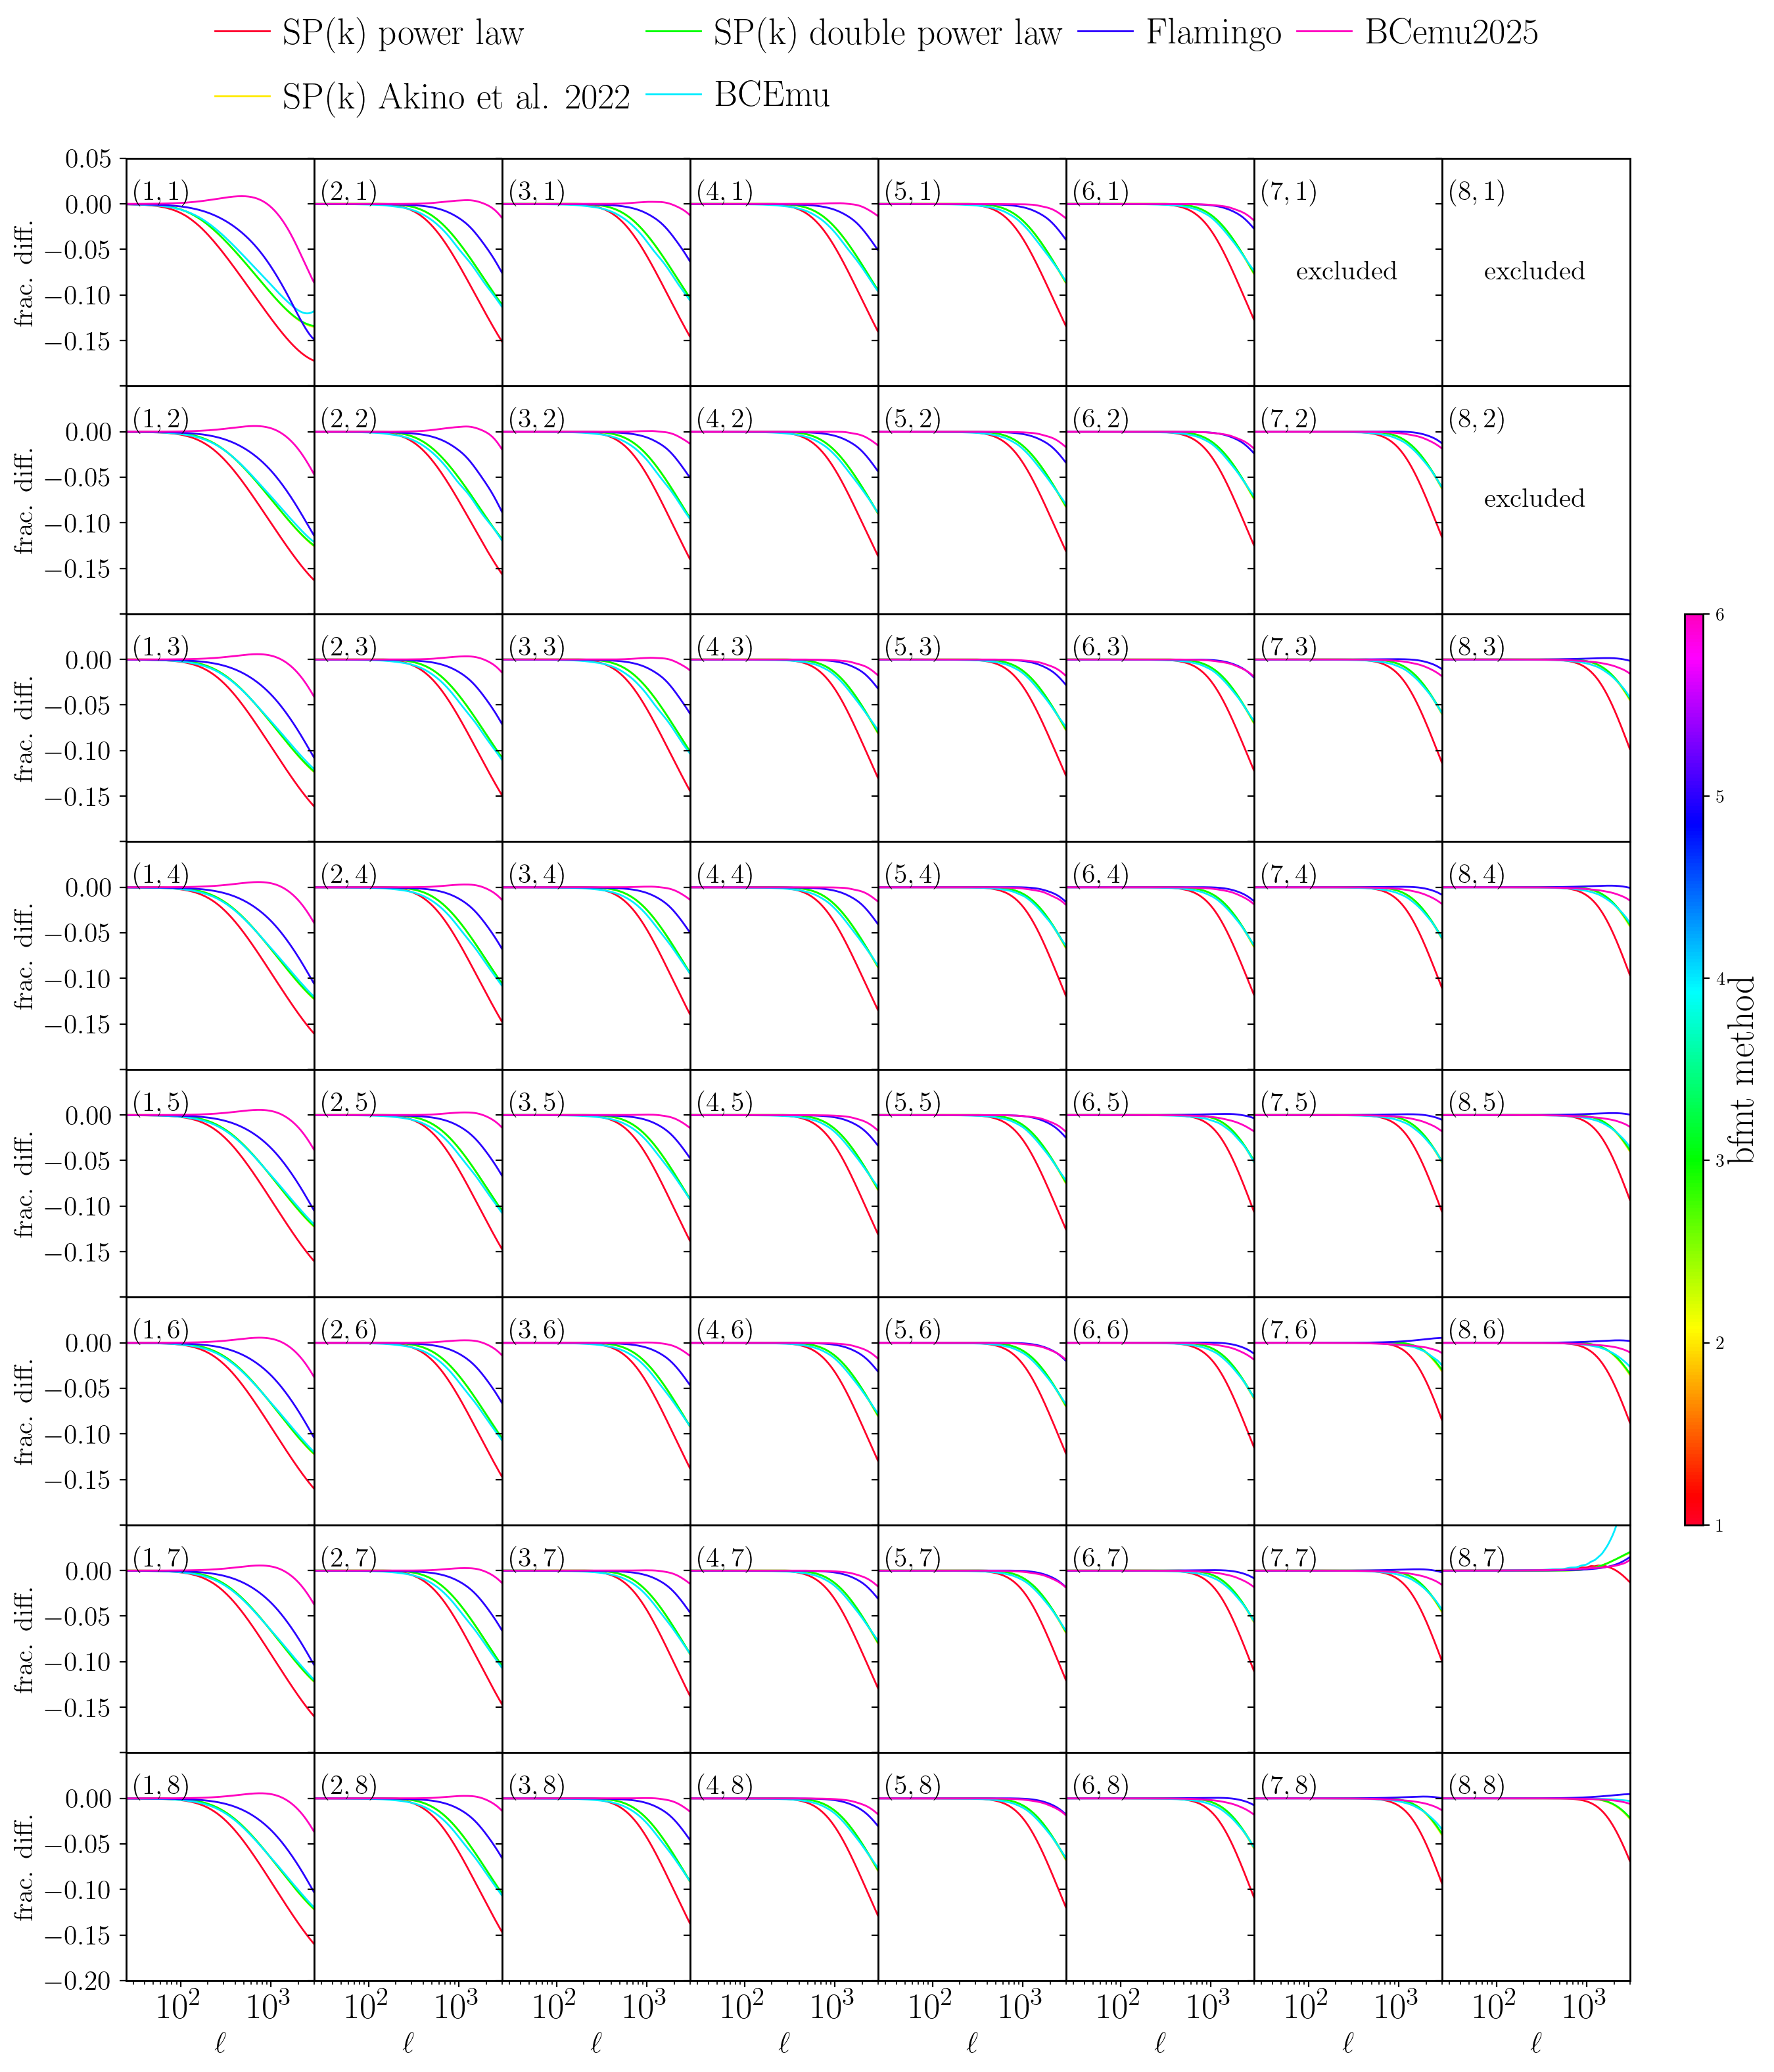

In [15]:
C_gs_list = [results[label]["C_gs"] for label in labels]

cnu.plot_C_gs_tomo_limber(ell=ref["ell"],
                          C_gs=C_gs_list,
                          C_gs_ref=ref["C_gs"],
                          param=param,
                          lmin=25,
                          lmax=3000,
                          figsize=(18, 18),
                          ylim=(0.8, 1.05),
                          colorbarlabel="bfmt method",
                          legend=labels,
                          legendfontsize=20,
                          xaxisticklabelsize=20,
                          yaxisticklabelsize=15,
                          yaxislabelsize=15)

## Galaxy–galaxy lensing with feedback: $\gamma_t(\theta)$

The same comparison for the tangential shear, between 2.5 and 250 arcmin.

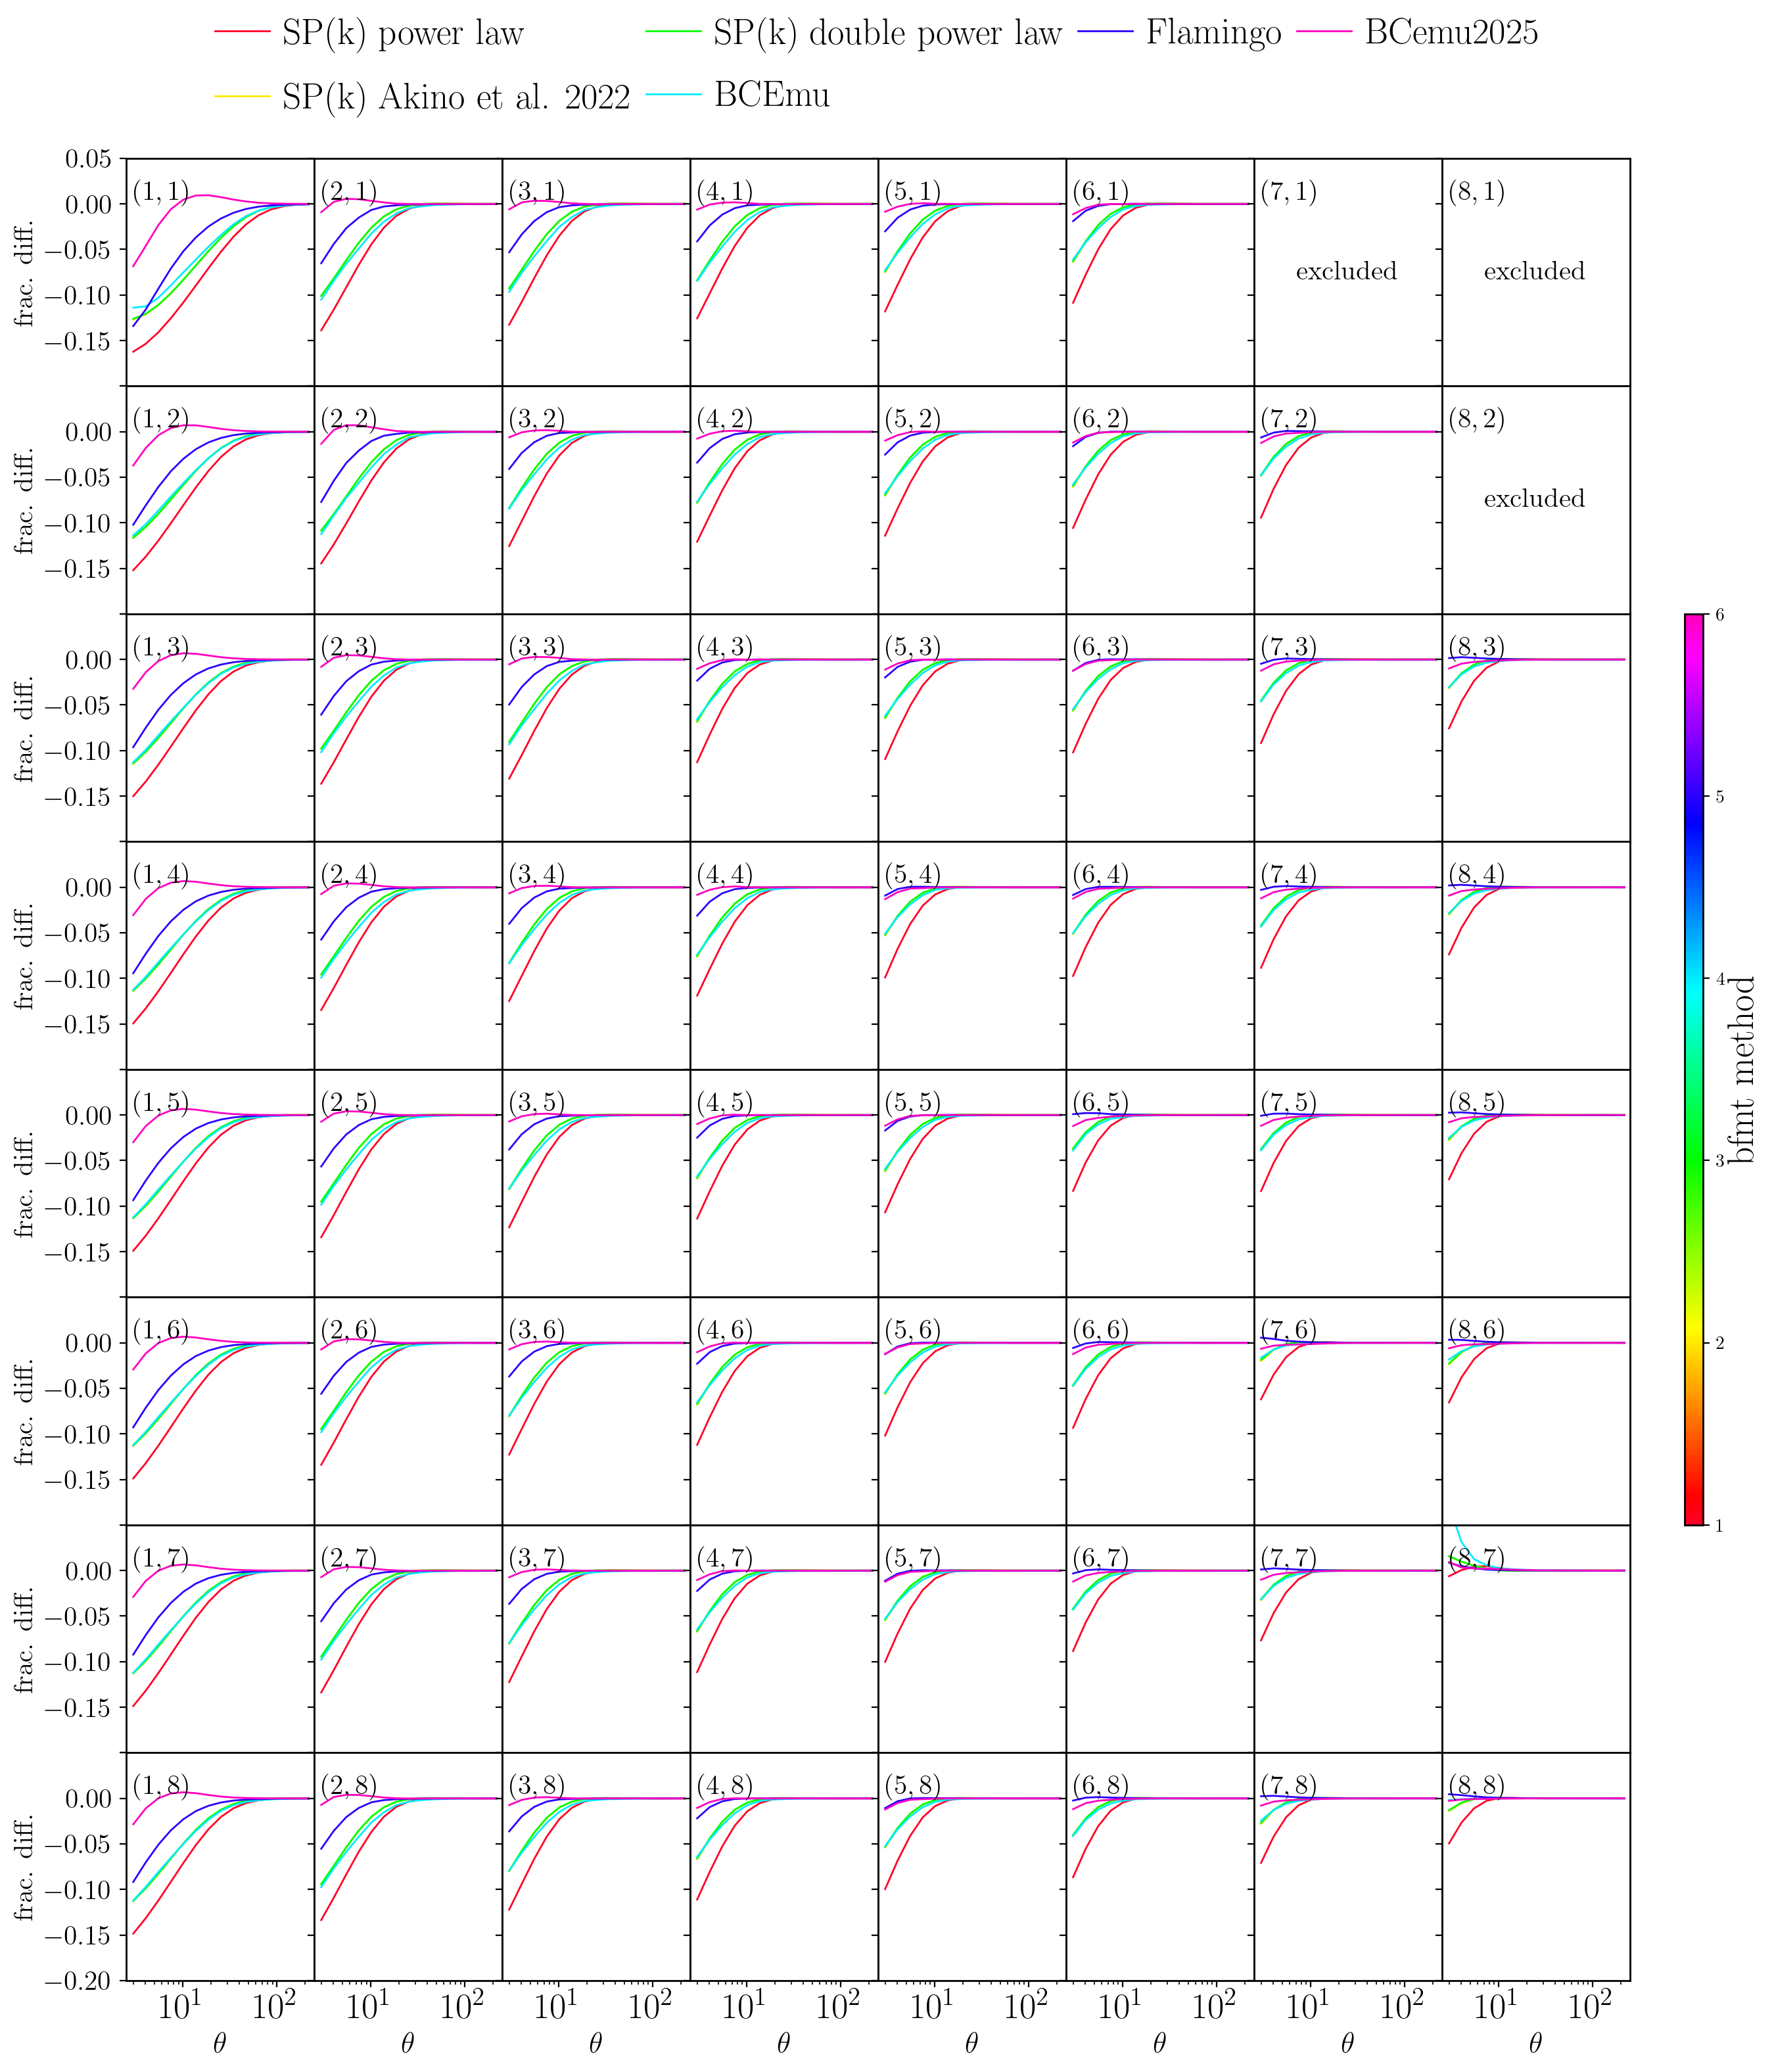

In [16]:
gammat_list = [(results[label]["theta"], results[label]["gammat"])
               for label in labels]
gammat_ref = (ref["theta"], ref["gammat"])
cnu.plot_gammat_tomo_limber(theta_gammat=gammat_list,
                            gammat_ref=gammat_ref,
                            param=param,
                            ylim=(0.8, 1.05),
                            figsize=(18, 18),
                            colorbarlabel="bfmt method",
                            legend=labels,
                            thetashow=[2.5, 250],
                            legendfontsize=20,
                            xaxisticklabelsize=20,
                            yaxisticklabelsize=15,
                            yaxislabelsize=15)

## Vary each method's free parameters, one at a time

Each figure below sweeps a single parameter of one feedback method,
holding everything else at the method's fiducial point, and shows the
suppression $S(k) = P_{\rm feedback}/P_{\rm DM}$ at $z = 0$ (solid) and
$z = 1$ (dashed); the colorbar gives the swept value. The horizontal axis is
$\log_{10}$ of $k$ in 1/Mpc, the unit the likelihoods send, from 0.05 to
12.6 Mpc$^{-1}$. The sweep ranges sit inside the bfmt validation boxes
(the 3$\sigma$ boxes of the yaml priors for SP(k) Akino, the emulator
training boxes otherwise). SP(k) is calibrated for $0.125\le z\le3$: below
$z=0.125$ the block reuses its $z=0.125$ suppression, so the solid SP(k)
curves show that redshift. An SP(k) curve can also revert to unity at a
redshift where the swept parameter pushes the baryon fraction outside
pyspk's calibrated band; this is the block's documented fallback, not a
bug. Every value is one `get_baryon_suppression` call (a fresh CAMB run),
so this section evaluates CAMB ~130 times and takes tens of minutes.

In [17]:
import io
from contextlib import redirect_stdout, redirect_stderr

# The sweep grid: two redshifts are enough to see the evolution, and
# the k grid spans the scales where feedback acts (1/Mpc, the unit the
# likelihoods send). SWEEP_RESULTS keeps every computed sweep, so a
# figure can be replotted without recomputing.
z_sweep = [0.0, 1.0]
log10k_sweep = np.linspace(-1.3, 1.1, 120)
SWEEP_RESULTS = {}
METHODS_BY_LABEL = {label: (options, point)
                    for label, options, point in BARYON_METHODS}

PARAM_SWEEPS = {
    # loose boxes; the hard guard is pyspk's calibrated fb band
    "SP(k) power law": {
        "fb_a_spk":   [0.2, 0.3, 0.4, 0.5, 0.6],
        "fb_pow_spk": [0.1, 0.2, 0.3, 0.4, 0.5],
    },
    # 3-sigma boxes: alpha 3.8-4.6, beta 1.0-1.6, gamma 0.1-0.75
    "SP(k) Akino et al. 2022": {
        "alpha_spk": [3.9, 4.05, 4.189, 4.35, 4.5],
        "beta_spk":  [1.05, 1.16, 1.273, 1.4, 1.55],
        "gamma_spk": [0.15, 0.22, 0.298, 0.45, 0.6],
    },
    # centered on the in-band point of the methods table above
    "SP(k) double power law": {
        "epsilon_spk": [0.50, 0.58, 0.66, 0.74, 0.82],
        "alpha_spk":   [0.15, 0.25, 0.35, 0.45, 0.55],
        "beta_spk":    [0.10, 0.15, 0.20, 0.25, 0.30],
        "gamma_spk":   [0.10, 0.20, 0.30, 0.40, 0.50],
    },
    # inside the Giri et al. 2021 training box
    "BCEmu": {
        "log10Mc_bcemu": [12.5, 13.0, 13.32, 13.8, 14.3],
        "mu_bcemu":      [0.3, 0.6, 0.93, 1.3, 1.7],
        "thej_bcemu":    [2.5, 3.3, 4.235, 5.3, 6.5],
        "gamma_bcemu":   [1.5, 1.9, 2.25, 2.8, 3.5],
        "delta_bcemu":   [4.0, 5.2, 6.4, 7.7, 9.0],
        "eta_bcemu":     [0.08, 0.11, 0.15, 0.25, 0.35],
        "deta_bcemu":    [0.08, 0.11, 0.14, 0.25, 0.35],
    },
    # the Schaller et al. 2025 suite spans fgas -8sigma..+2sigma,
    # mstar -1sigma, and jet fractions 0..1
    "Flamingo": {
        "fgas_sigma_flamingo":  [-8.0, -4.0, -2.0, 0.0, 2.0],
        "mstar_sigma_flamingo": [-1.0, -0.5, 0.0, 0.5, 1.0],
        "jet_frac_flamingo":    [0.0, 0.25, 0.5, 0.75, 1.0],
    },
    # inside the BCemu2025 training LHC box
    "BCemu2025": {
        "Theta_co_bcemu25": [0.1, 0.2, 0.3, 0.45, 0.6],
        "log10Mc_bcemu25":  [12.0, 12.6, 13.1, 13.7, 14.4],
        "mu_bcemu25":       [0.4, 0.7, 1.0, 1.5, 2.0],
        "delta_bcemu25":    [3.0, 4.5, 6.0, 8.0, 10.0],
        "eta_bcemu25":      [-0.15, -0.05, 0.02, 0.10, 0.18],
        "deta_bcemu25":     [0.05, 0.12, 0.22, 0.30, 0.38],
        "Nstar_bcemu25":    [0.010, 0.019, 0.028, 0.037, 0.045],
    },
}

def sweep_parameter(label, name, values):
    """One-at-a-time sweep: name takes each value, the rest stay at
    the method's fiducial point; returns one (n_z, n_k) array per
    value and caches them in SWEEP_RESULTS. Everything the libraries
    print while a model builds (emulator loading bars, cobaya
    banners) goes to an in-memory buffer instead of the notebook, so
    a sweep cell shows only its figures; an exception still surfaces
    with its full traceback."""
    options, fiducial = METHODS_BY_LABEL[label]
    sups = []
    for v in values:
        point = dict(fiducial, **{name: v})
        chatter = io.StringIO()
        with redirect_stdout(chatter), redirect_stderr(chatter):
            S = nw.get_baryon_suppression(options, point,
                                       z_sweep, log10k_sweep)
        sups.append(np.array([S[z] for z in z_sweep]))
    SWEEP_RESULTS.setdefault(label, {})[name] = sups
    return sups

# plot_sweeps draws one figure per free parameter of a method: S(k)
# for each swept value (colorbar), solid at z = 0 and dashed at z = 1.
def plot_sweeps(label):
    for name, values in PARAM_SWEEPS[label].items():
        sups = sweep_parameter(label, name, values)
        cnu.plot_baryon_suppression(log10k=log10k_sweep,
                                    sup=sups,
                                    param=np.array(values),
                                    colorbarlabel=name.replace("_", " "),
                                    zlabels=["$z=0$", "$z=1$"],
                                    ylim=(0.6, 1.35),
                                    title=label + ": vary " + name.replace("_", " "))

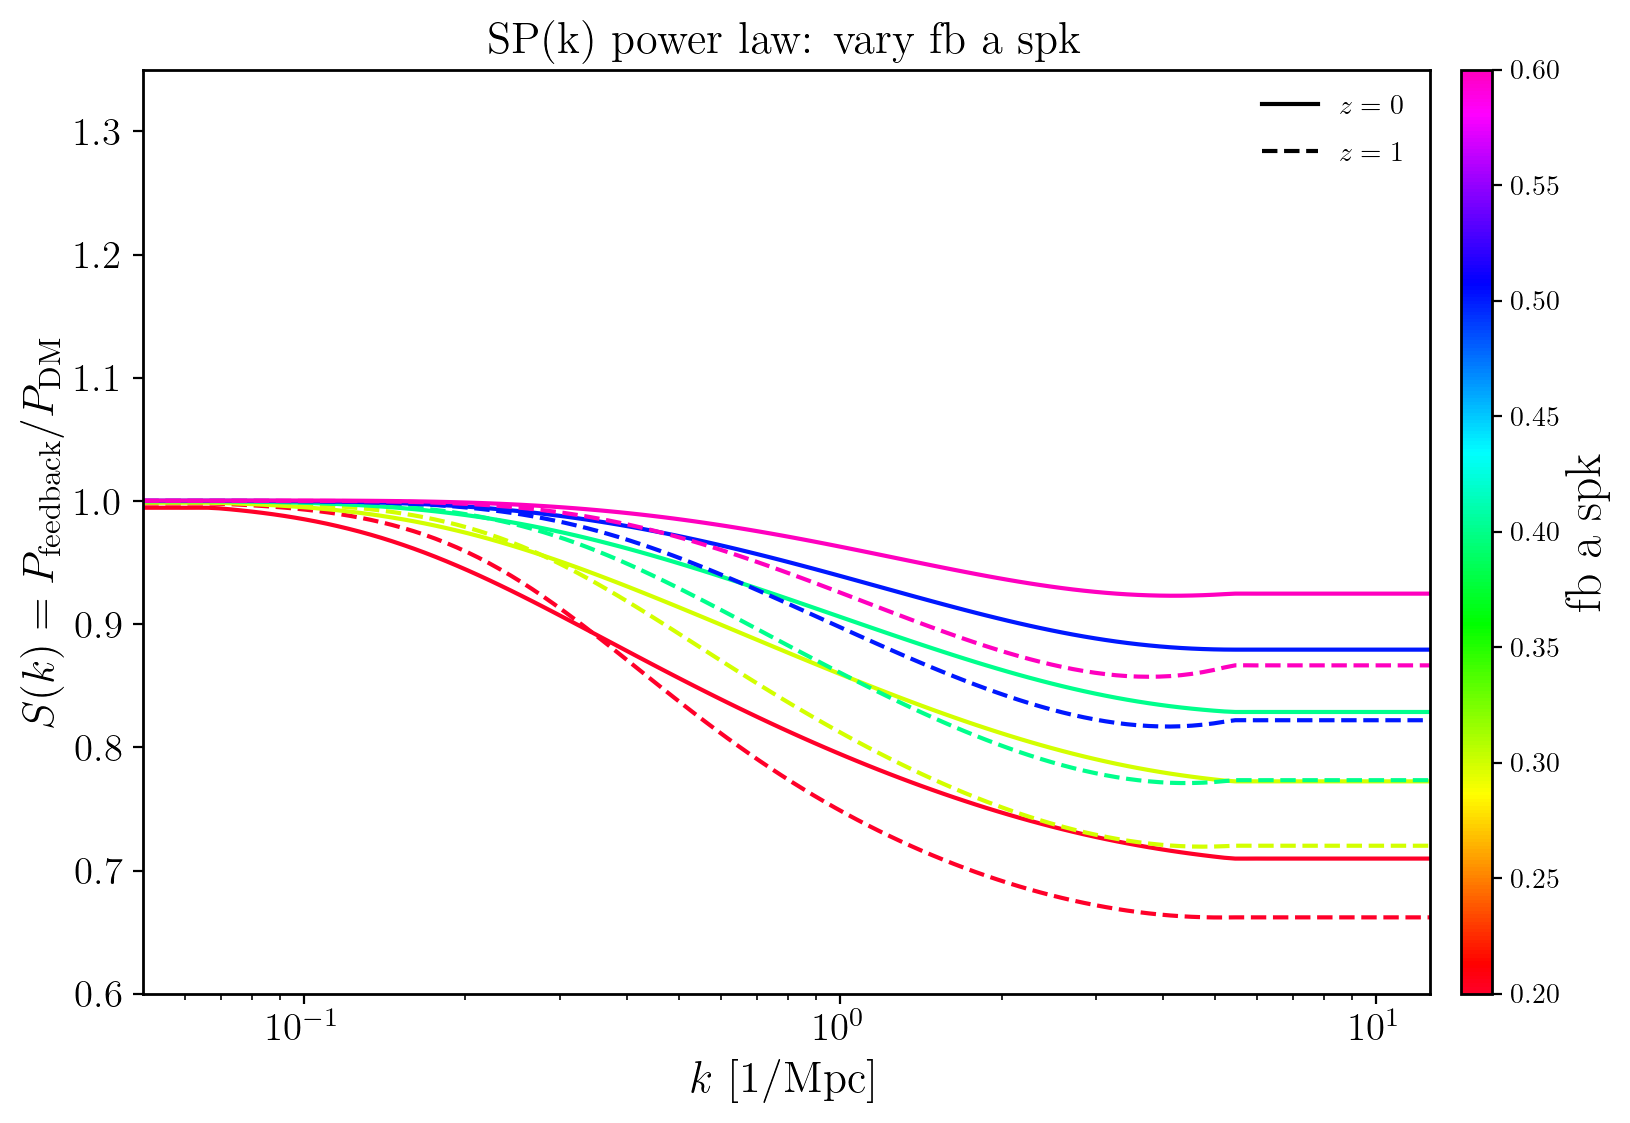

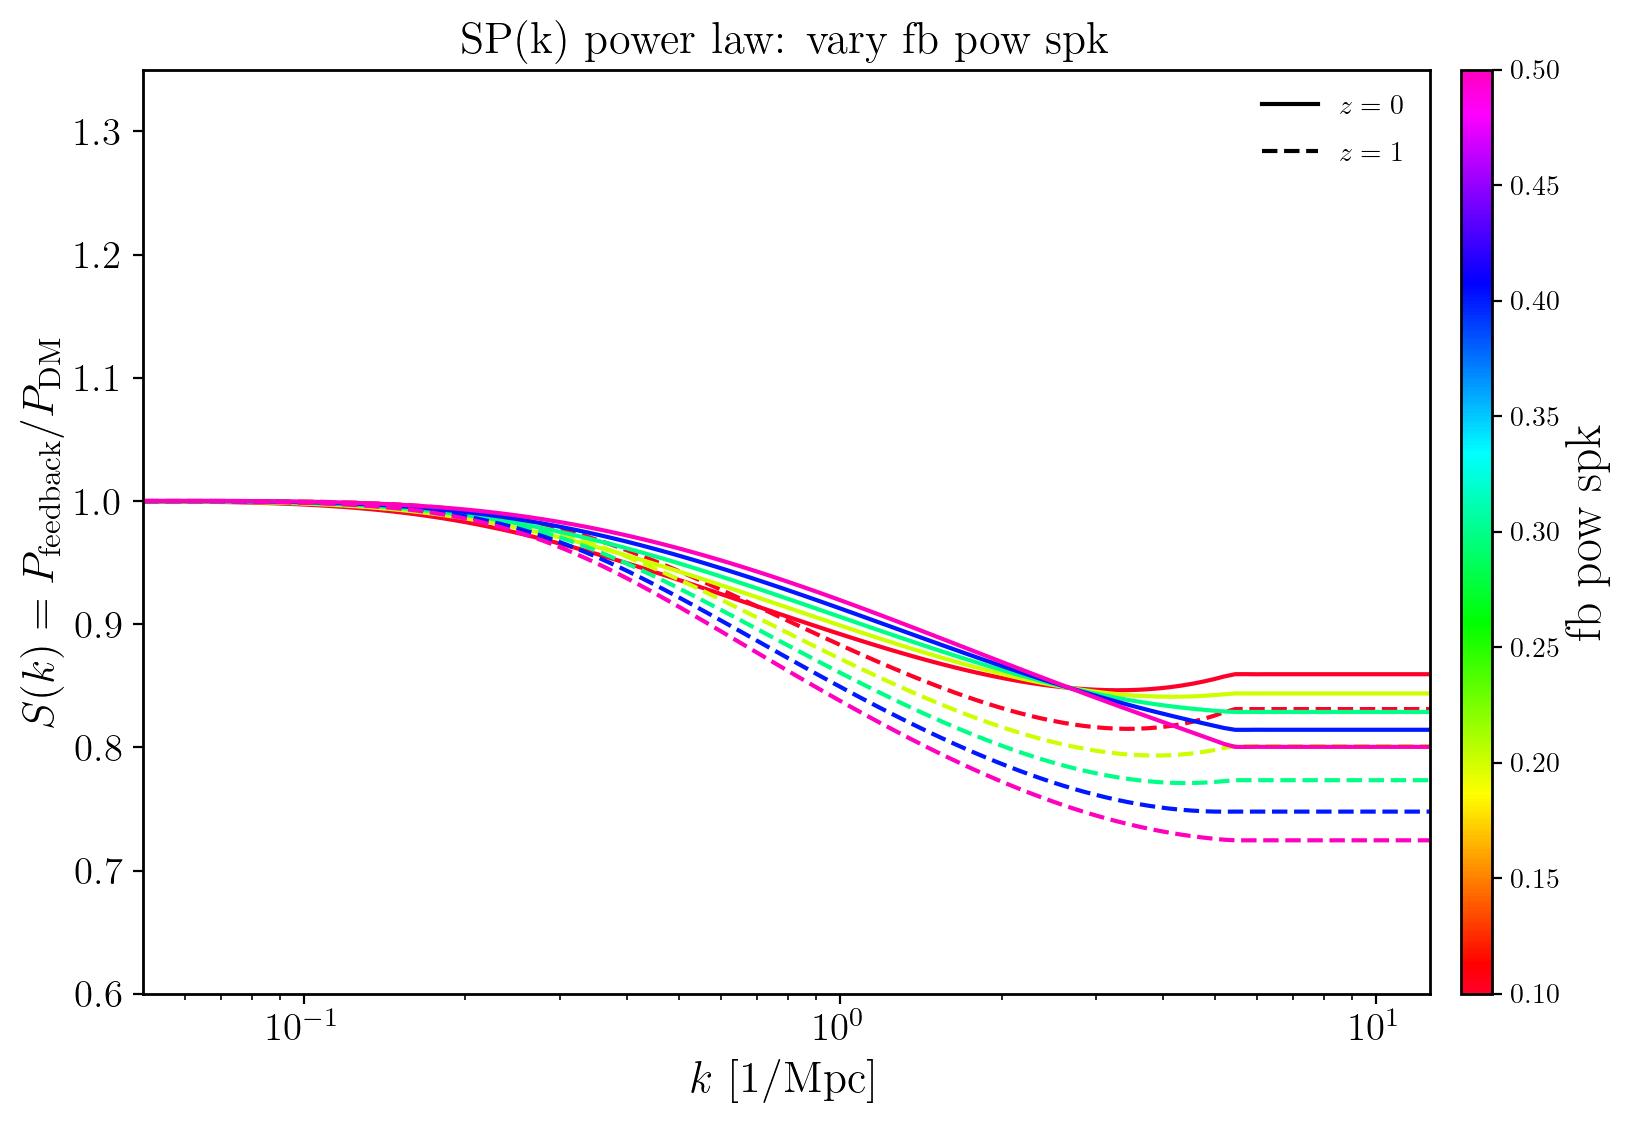

In [18]:
plot_sweeps("SP(k) power law")

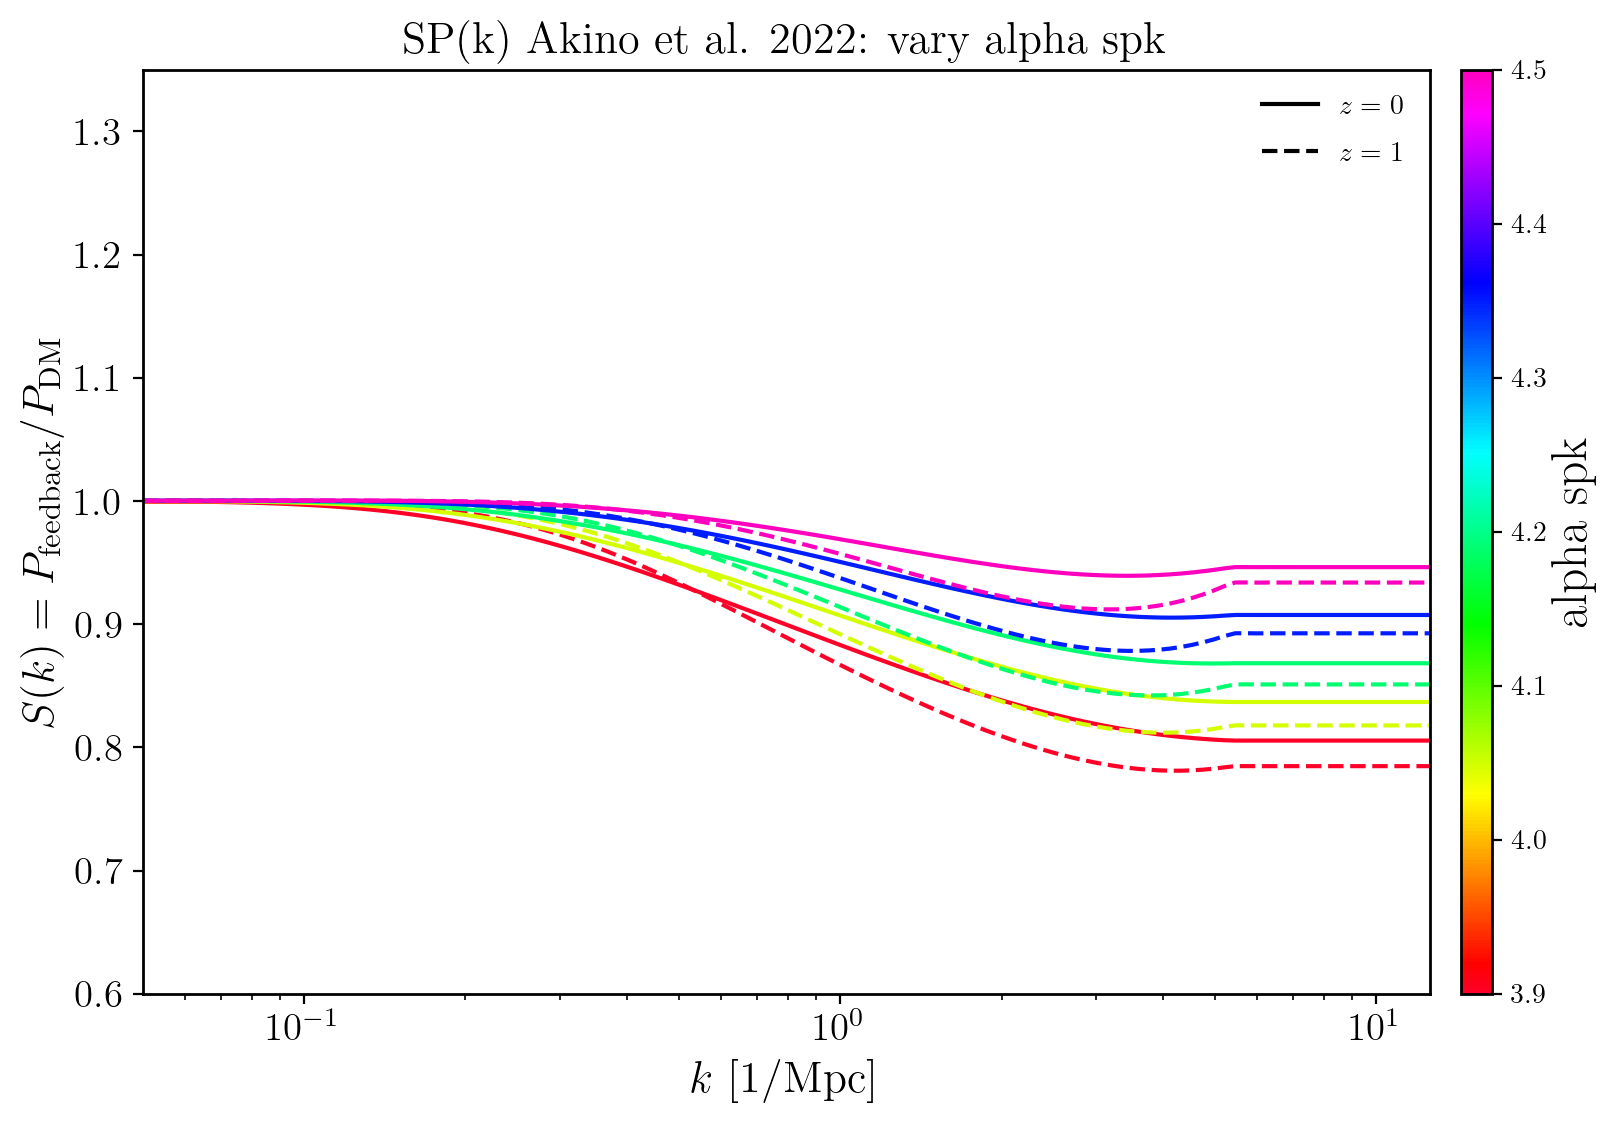

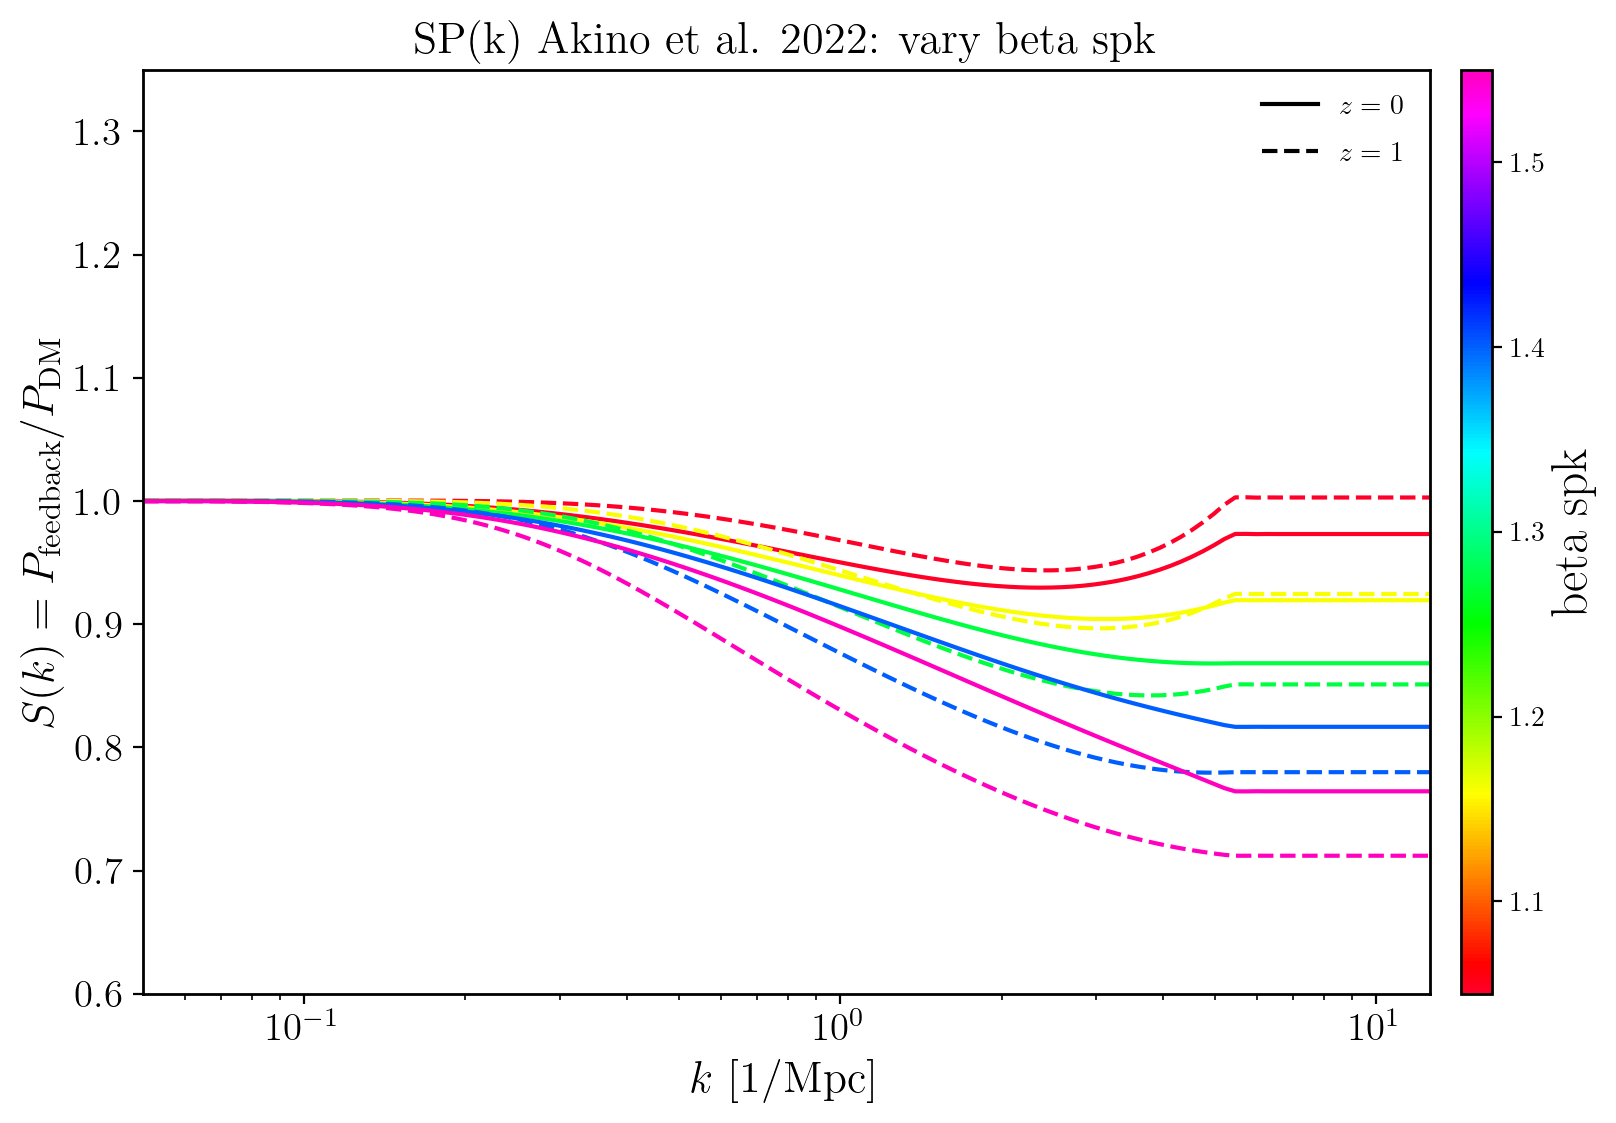

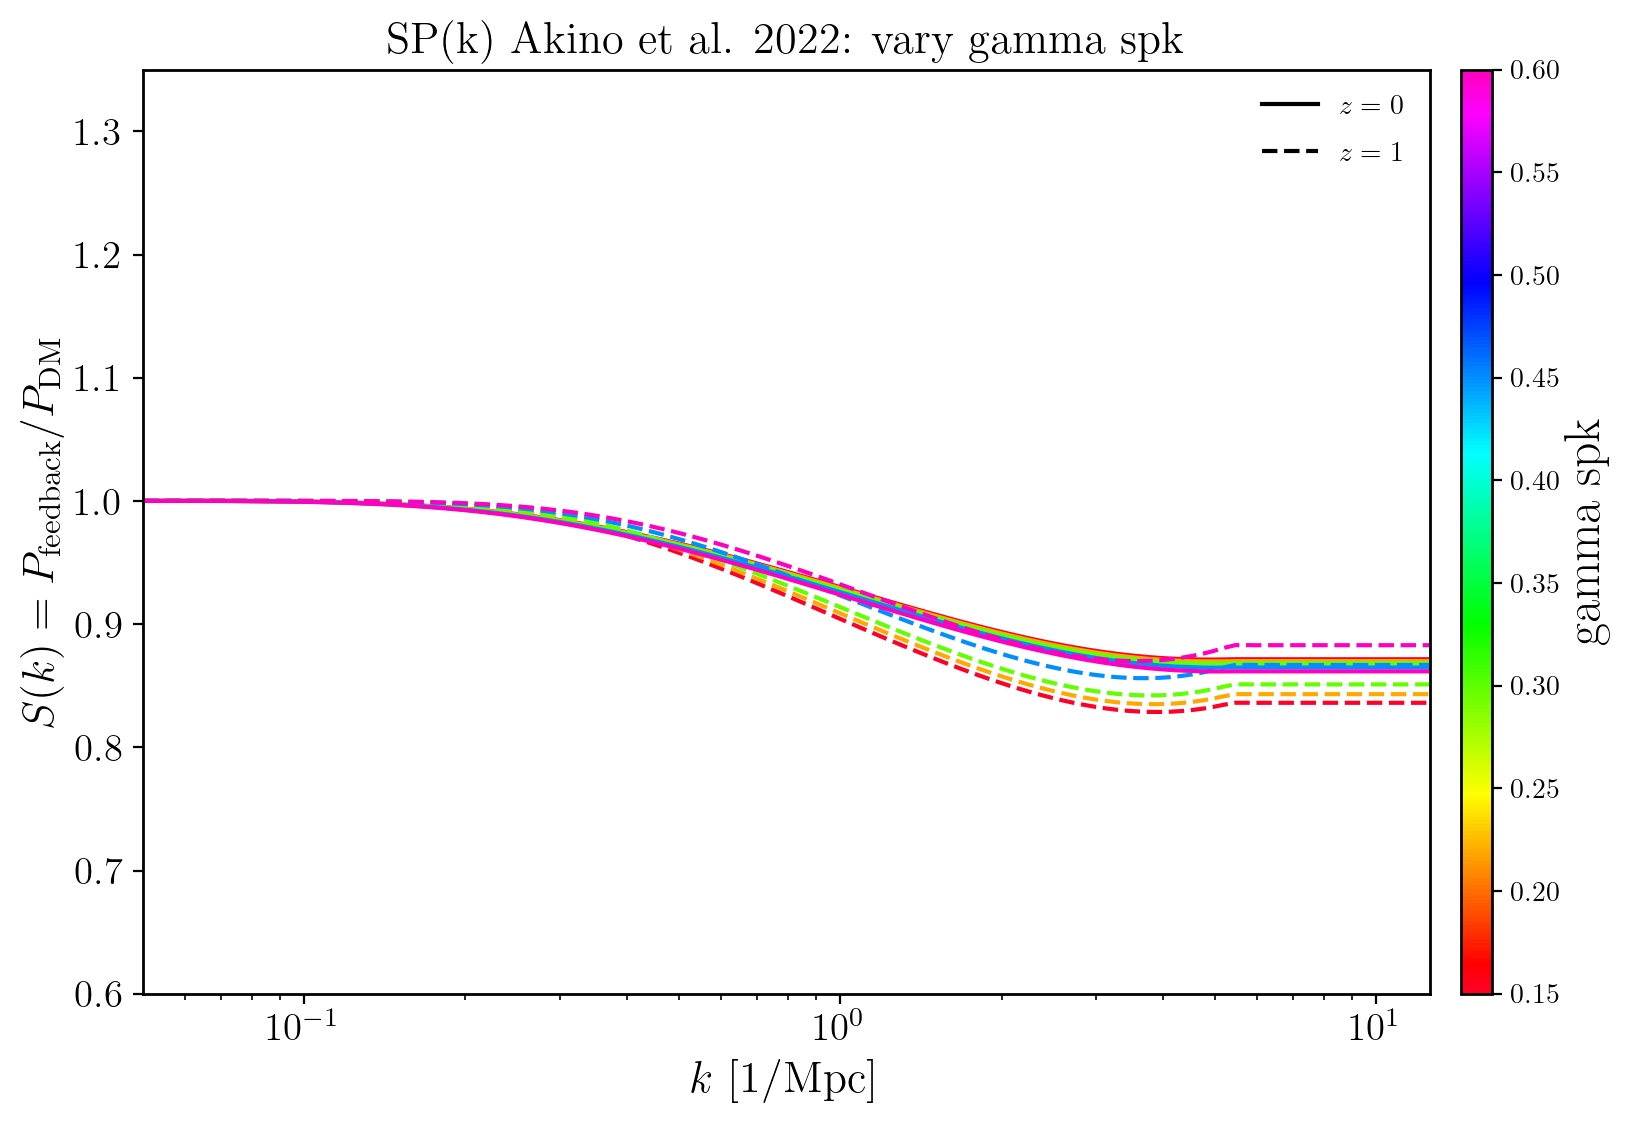

In [19]:
plot_sweeps("SP(k) Akino et al. 2022")

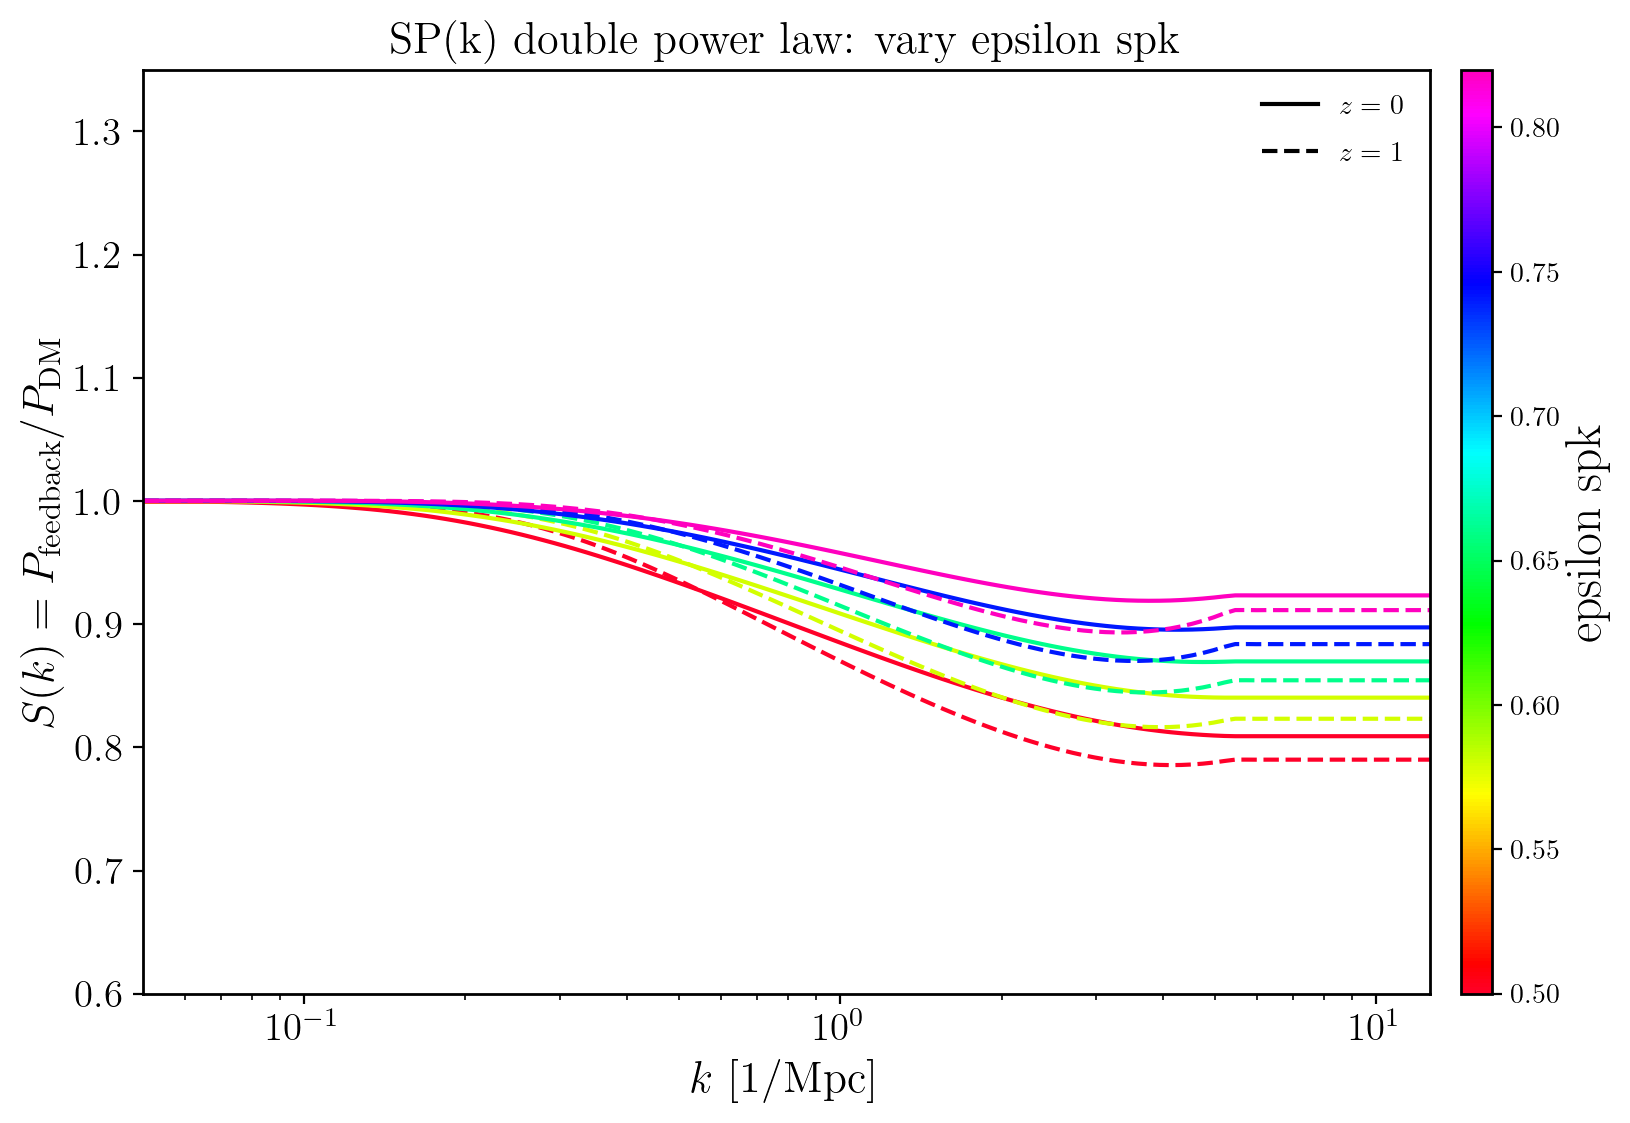

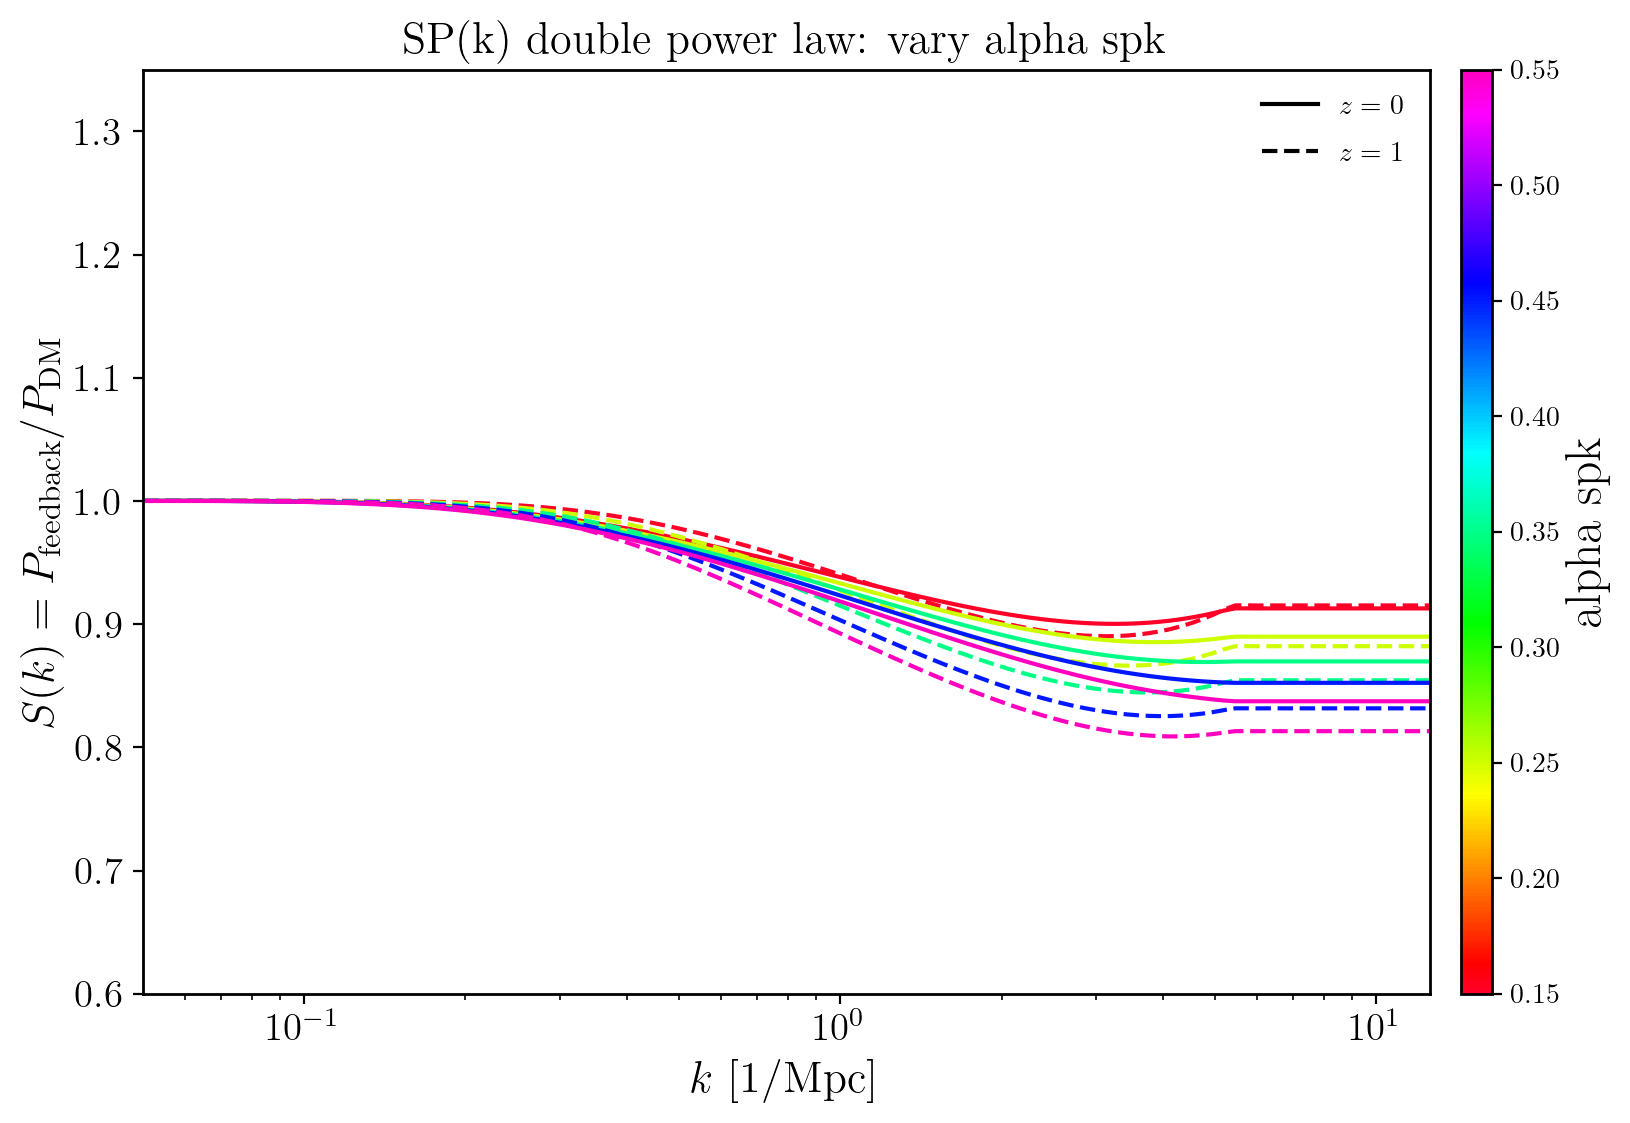

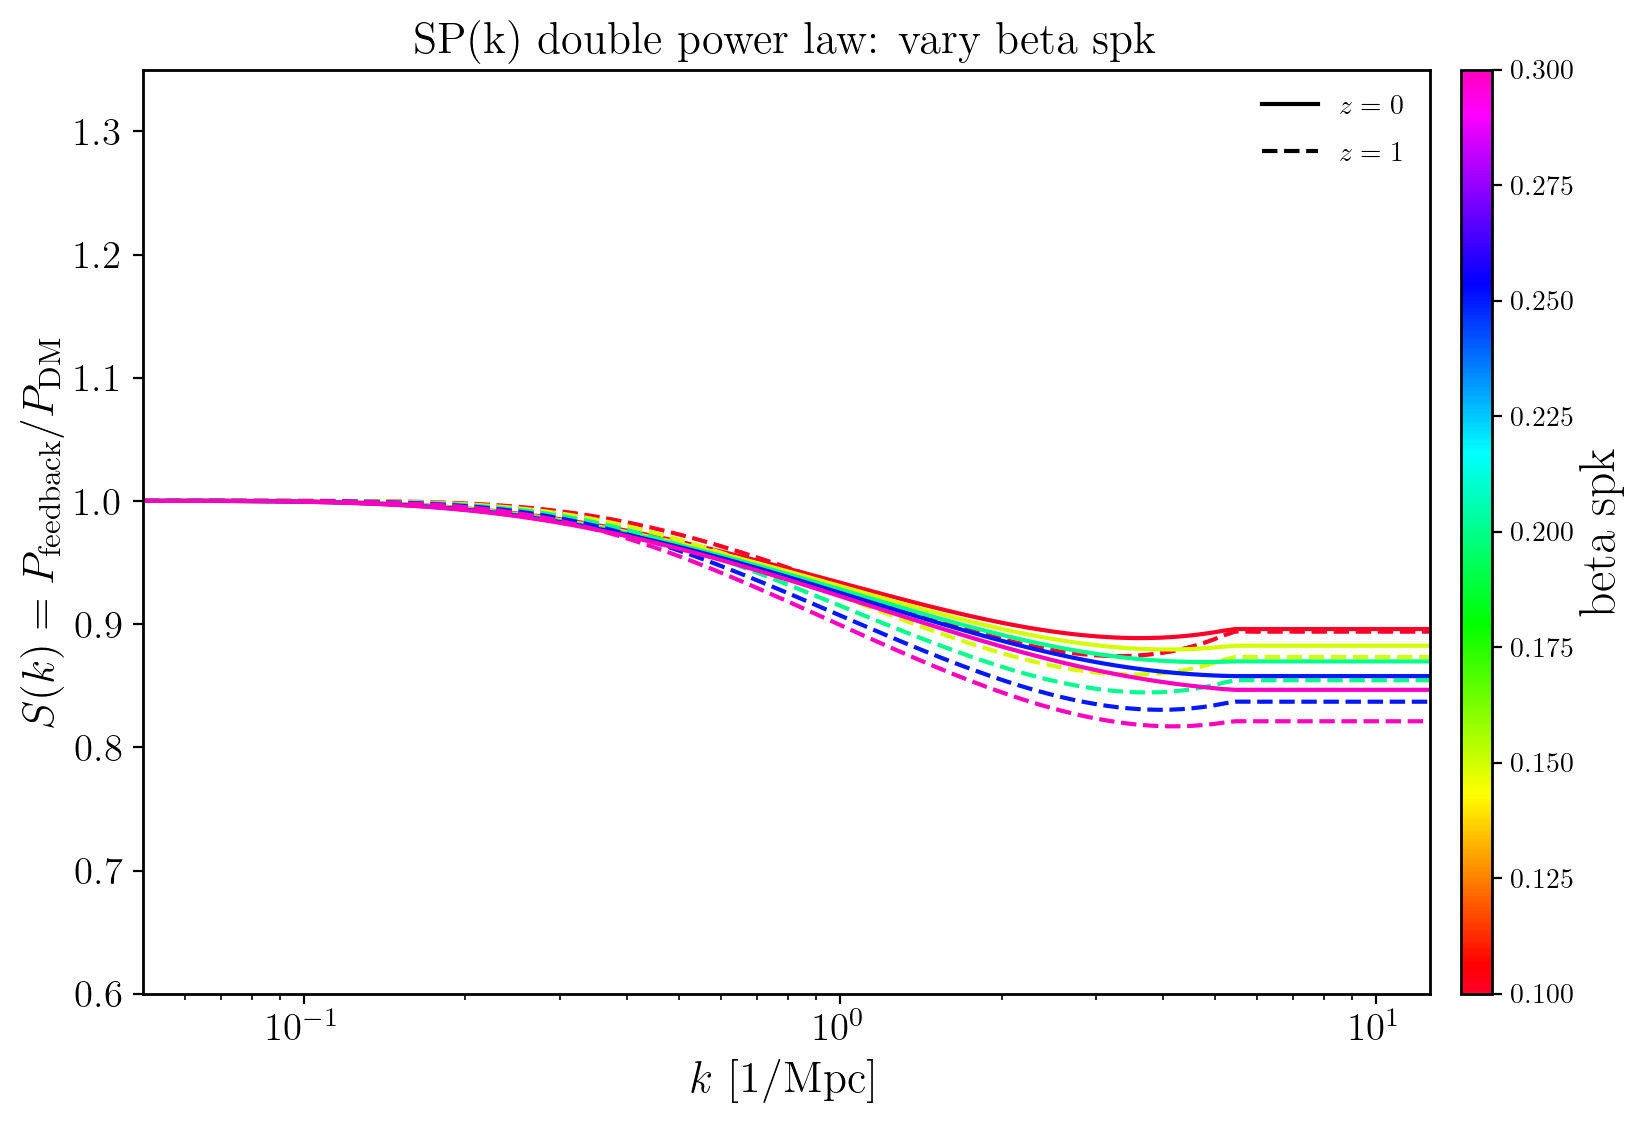

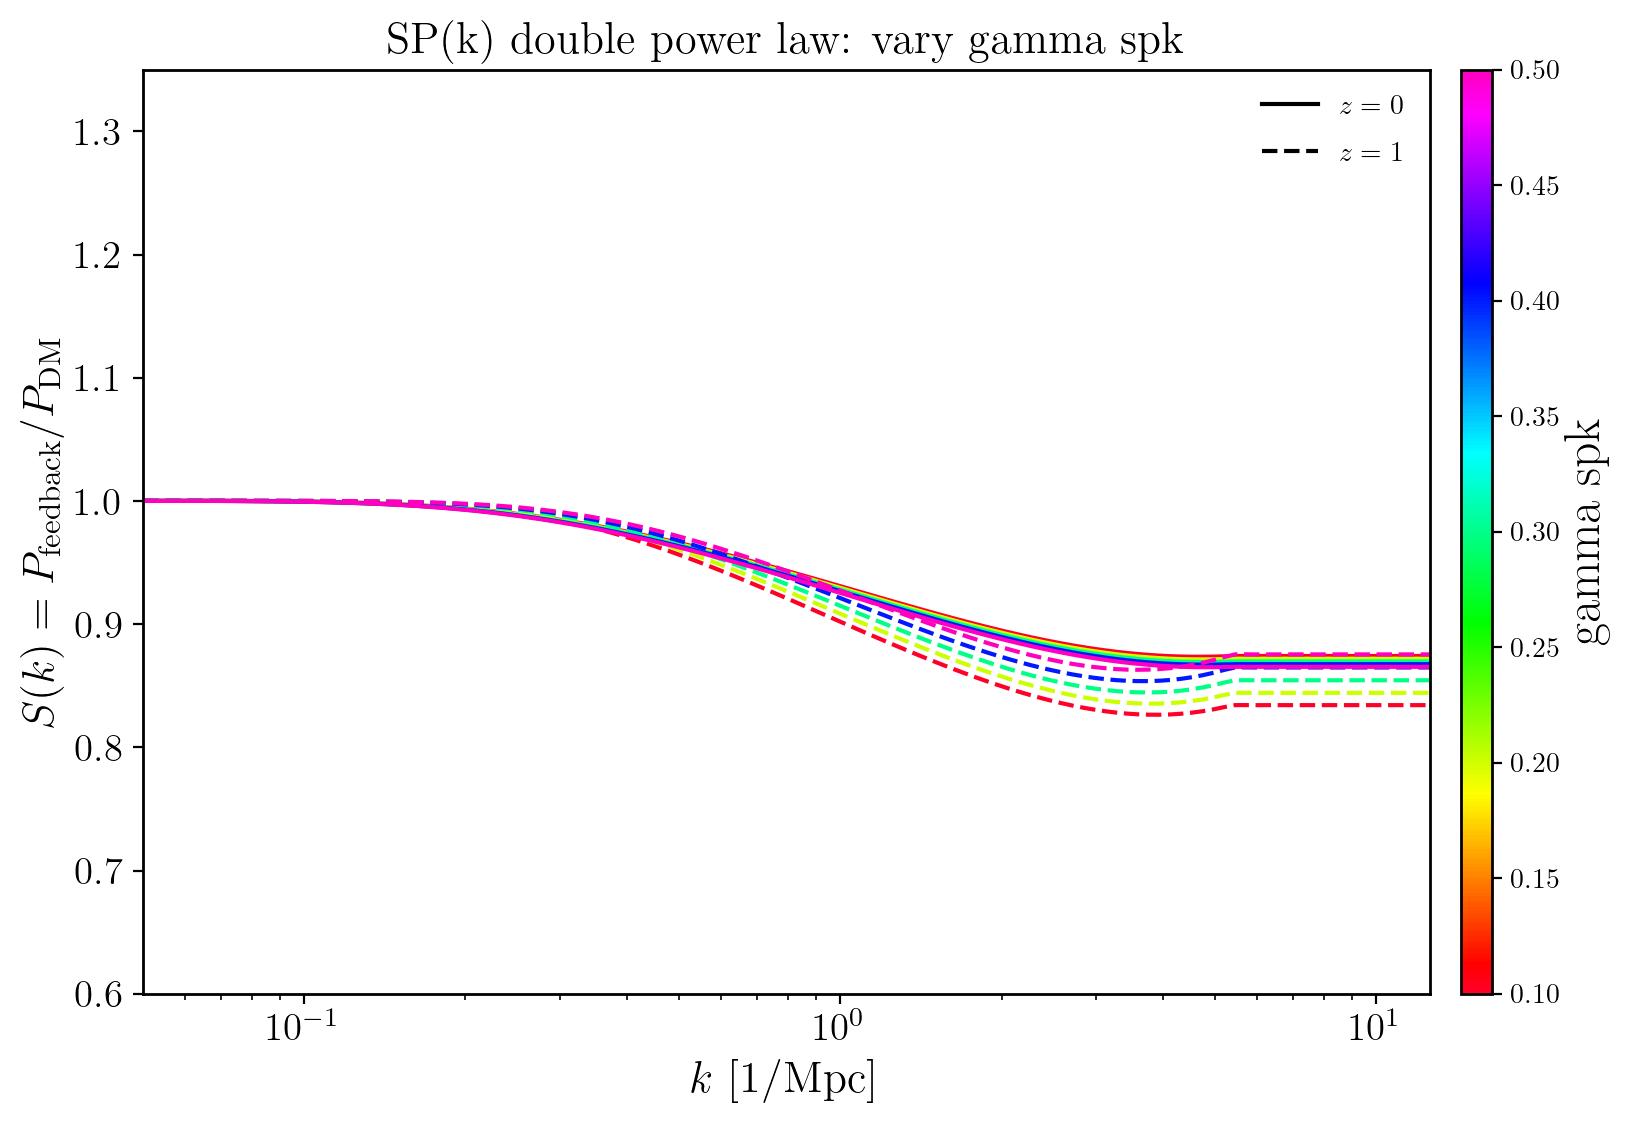

In [20]:
plot_sweeps("SP(k) double power law")

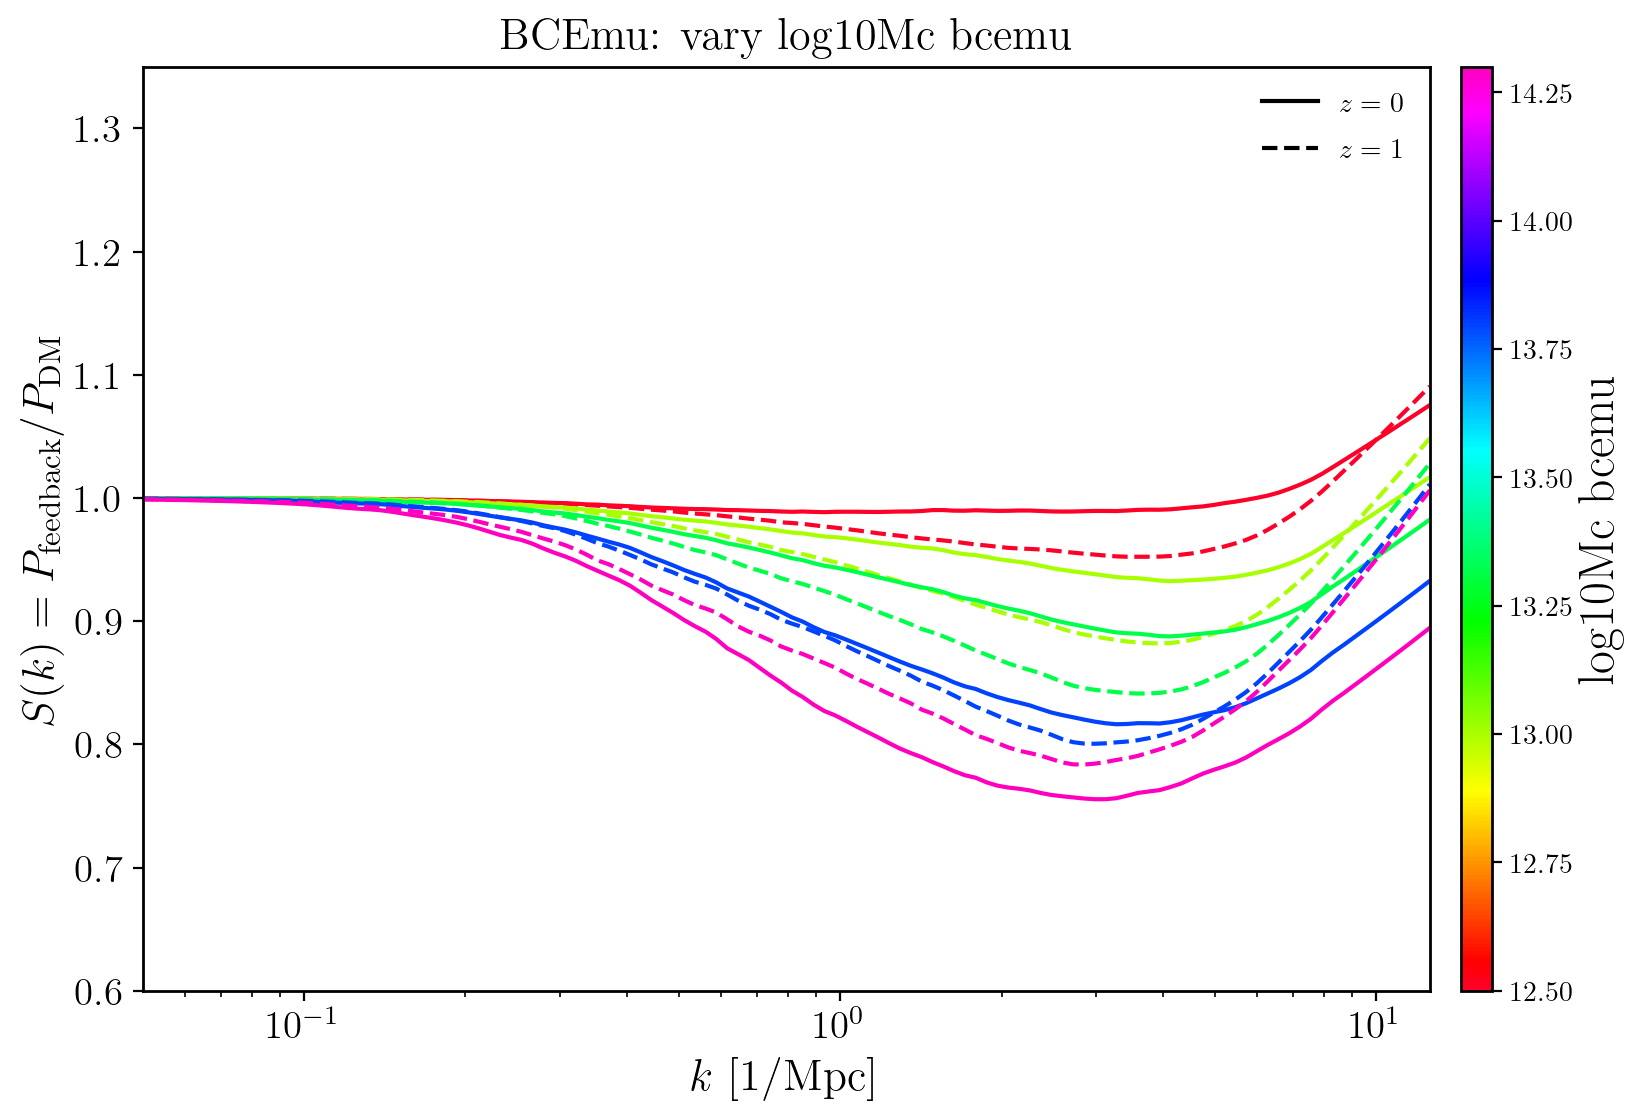

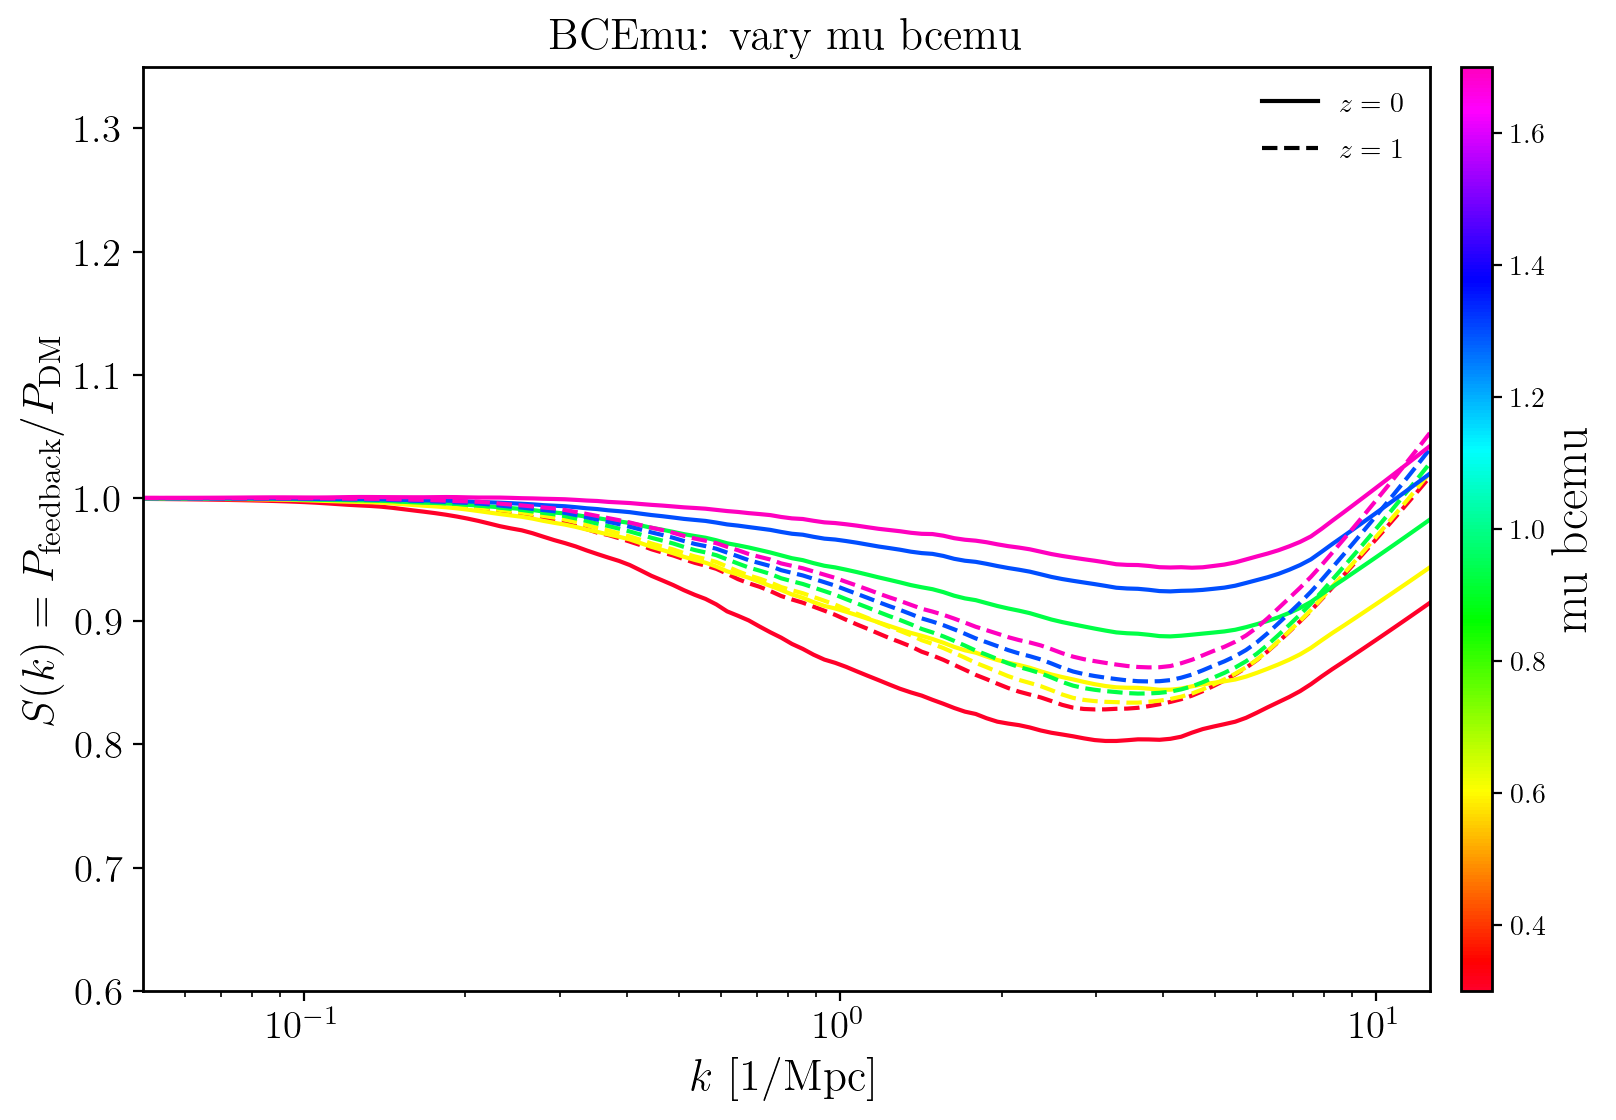

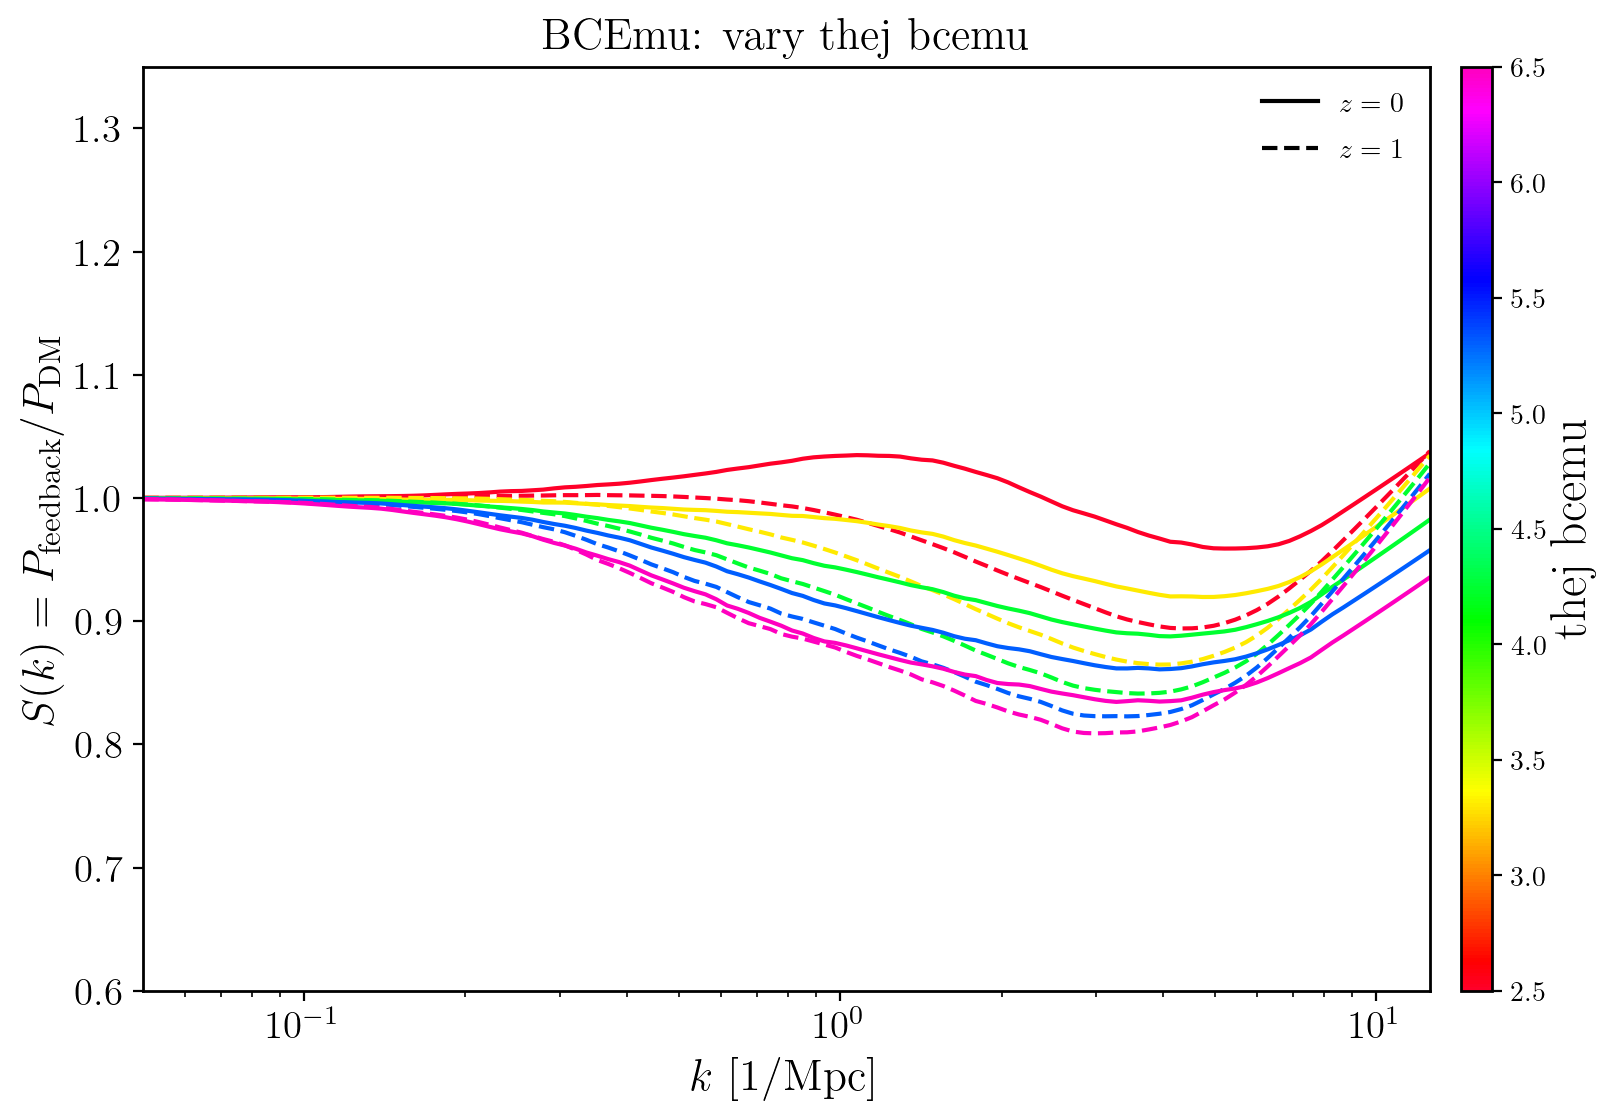

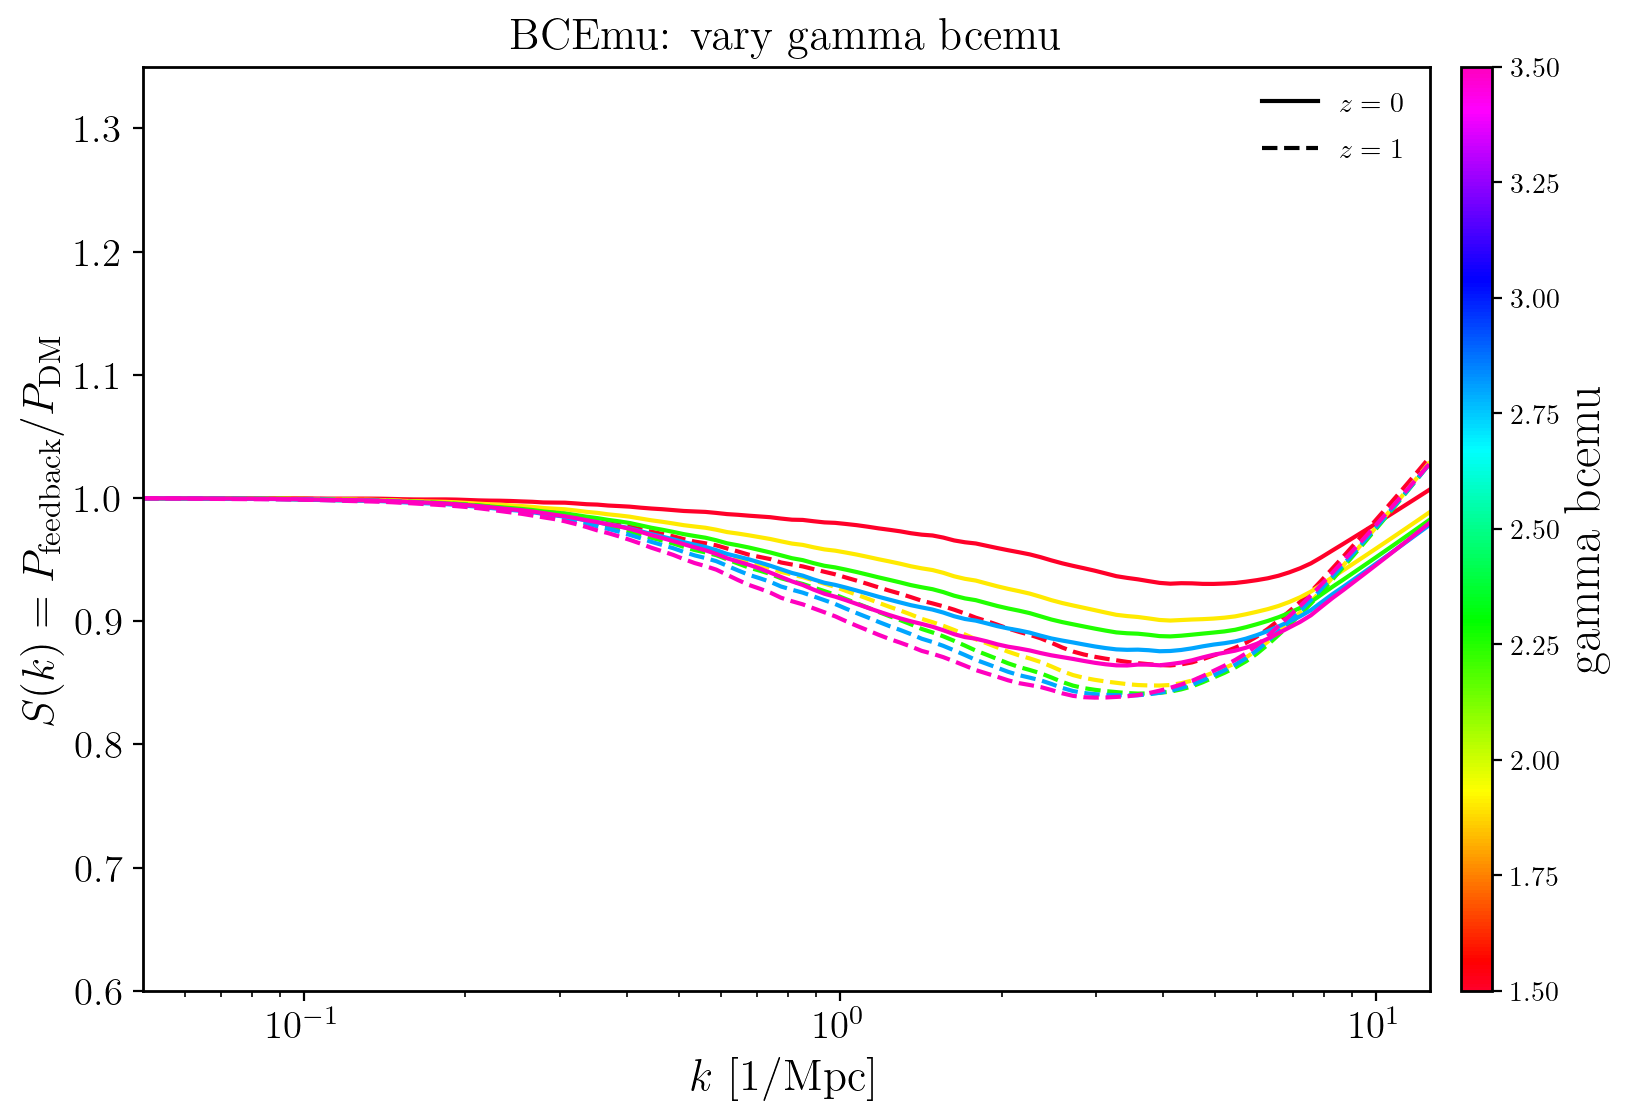

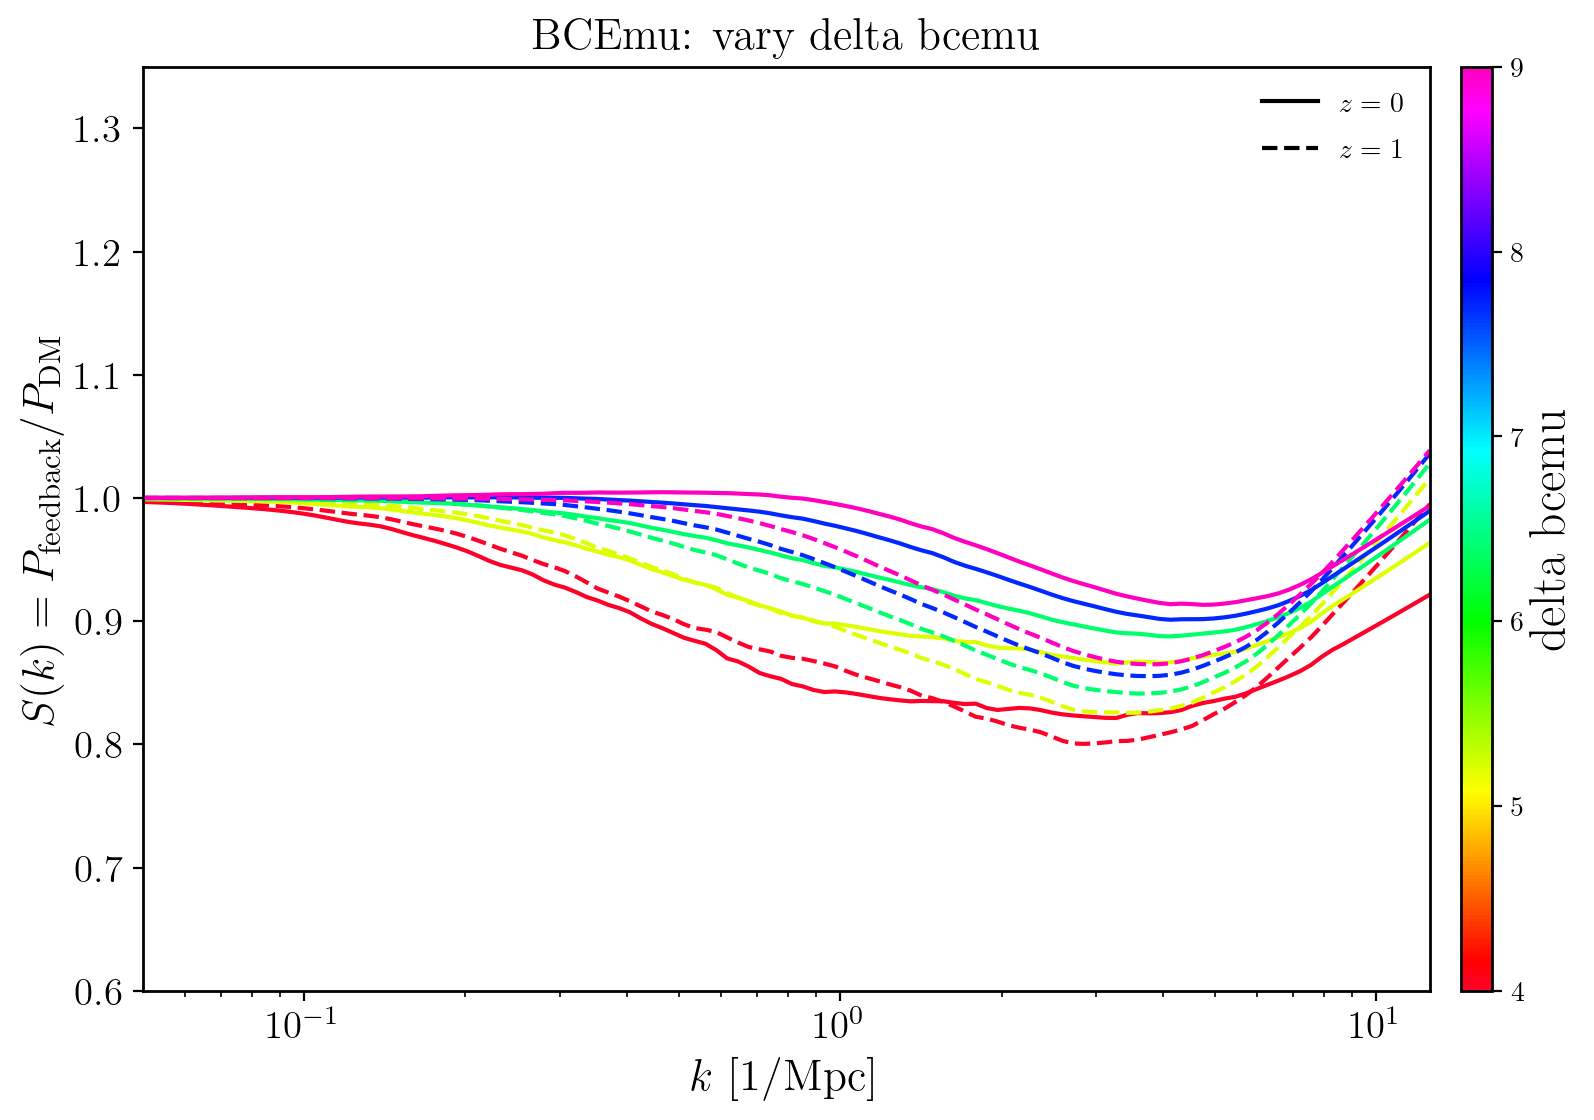

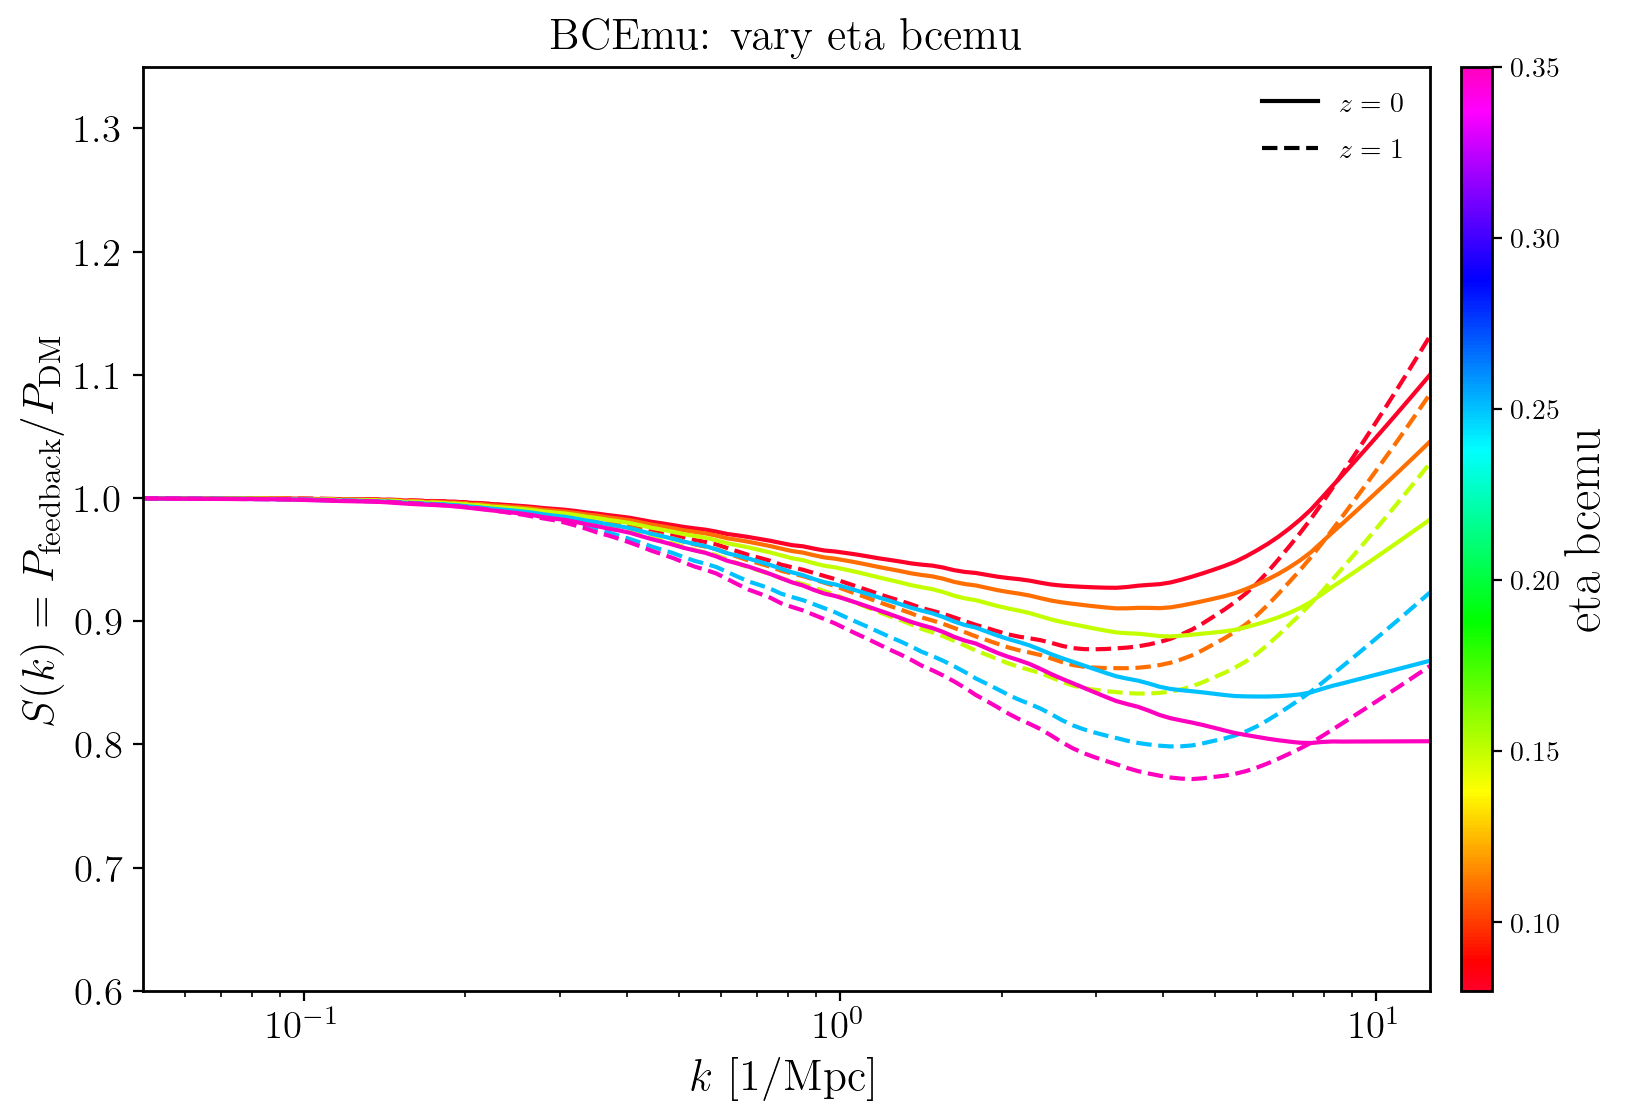

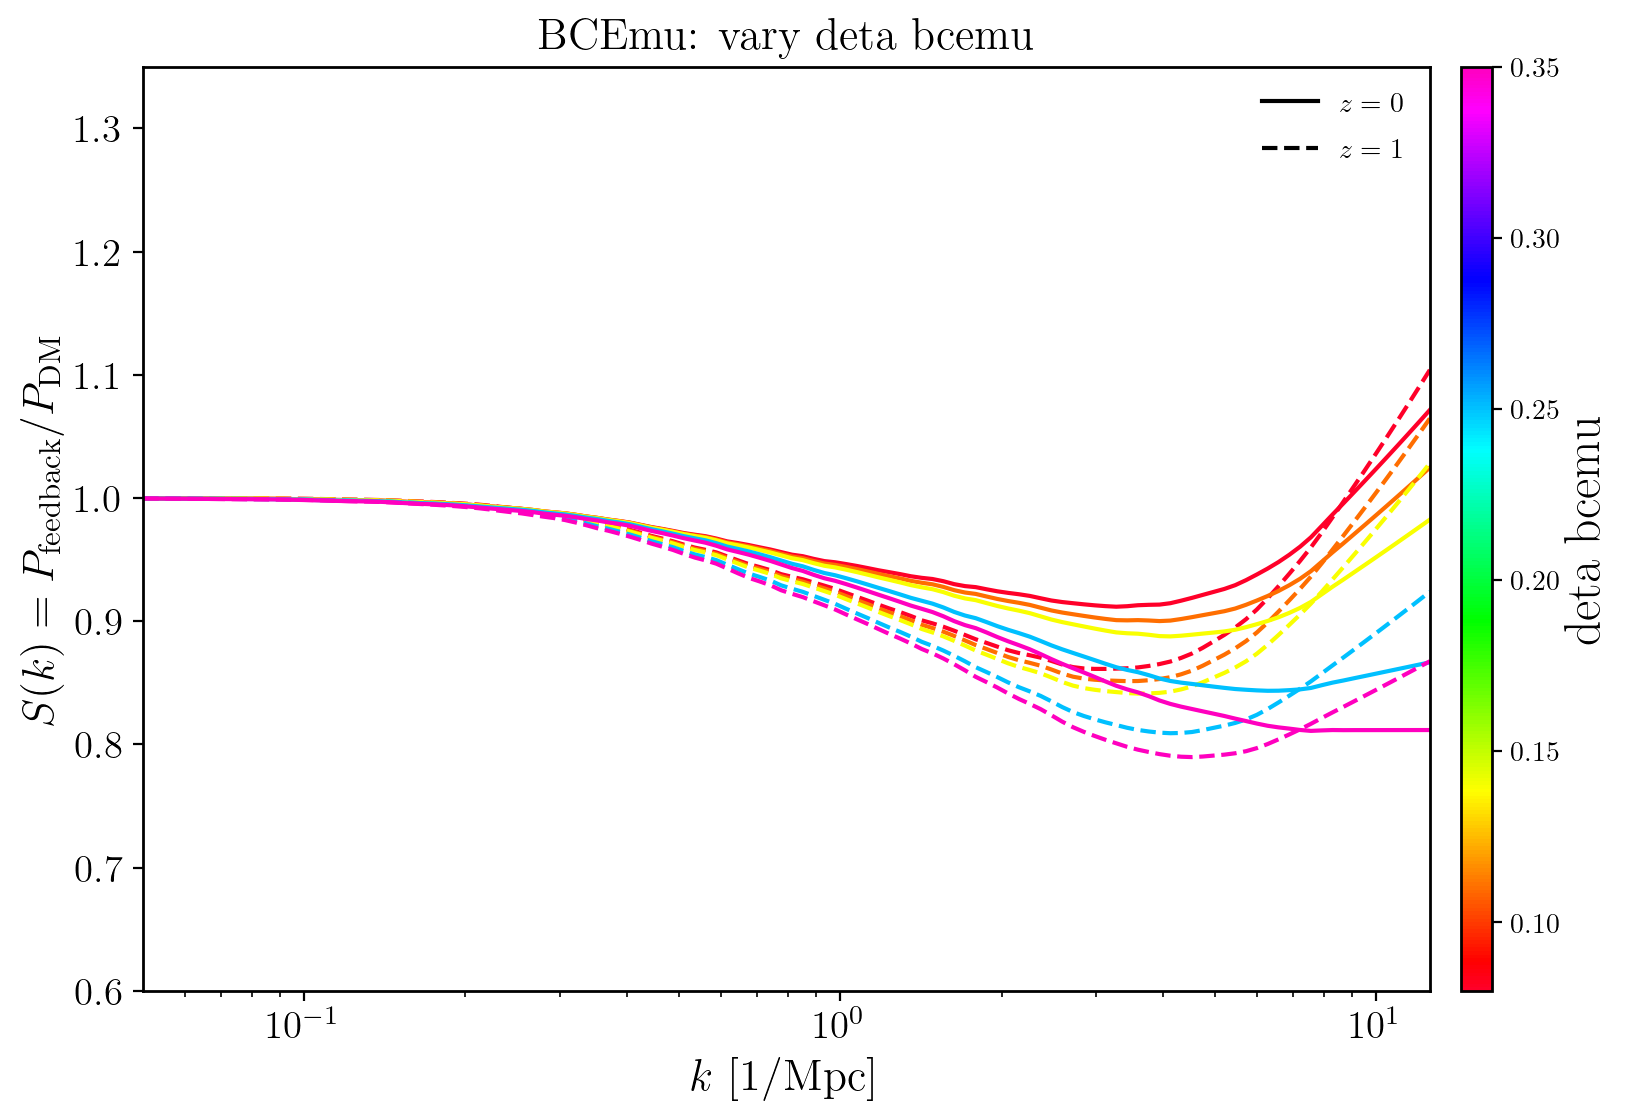

In [21]:
plot_sweeps("BCEmu")

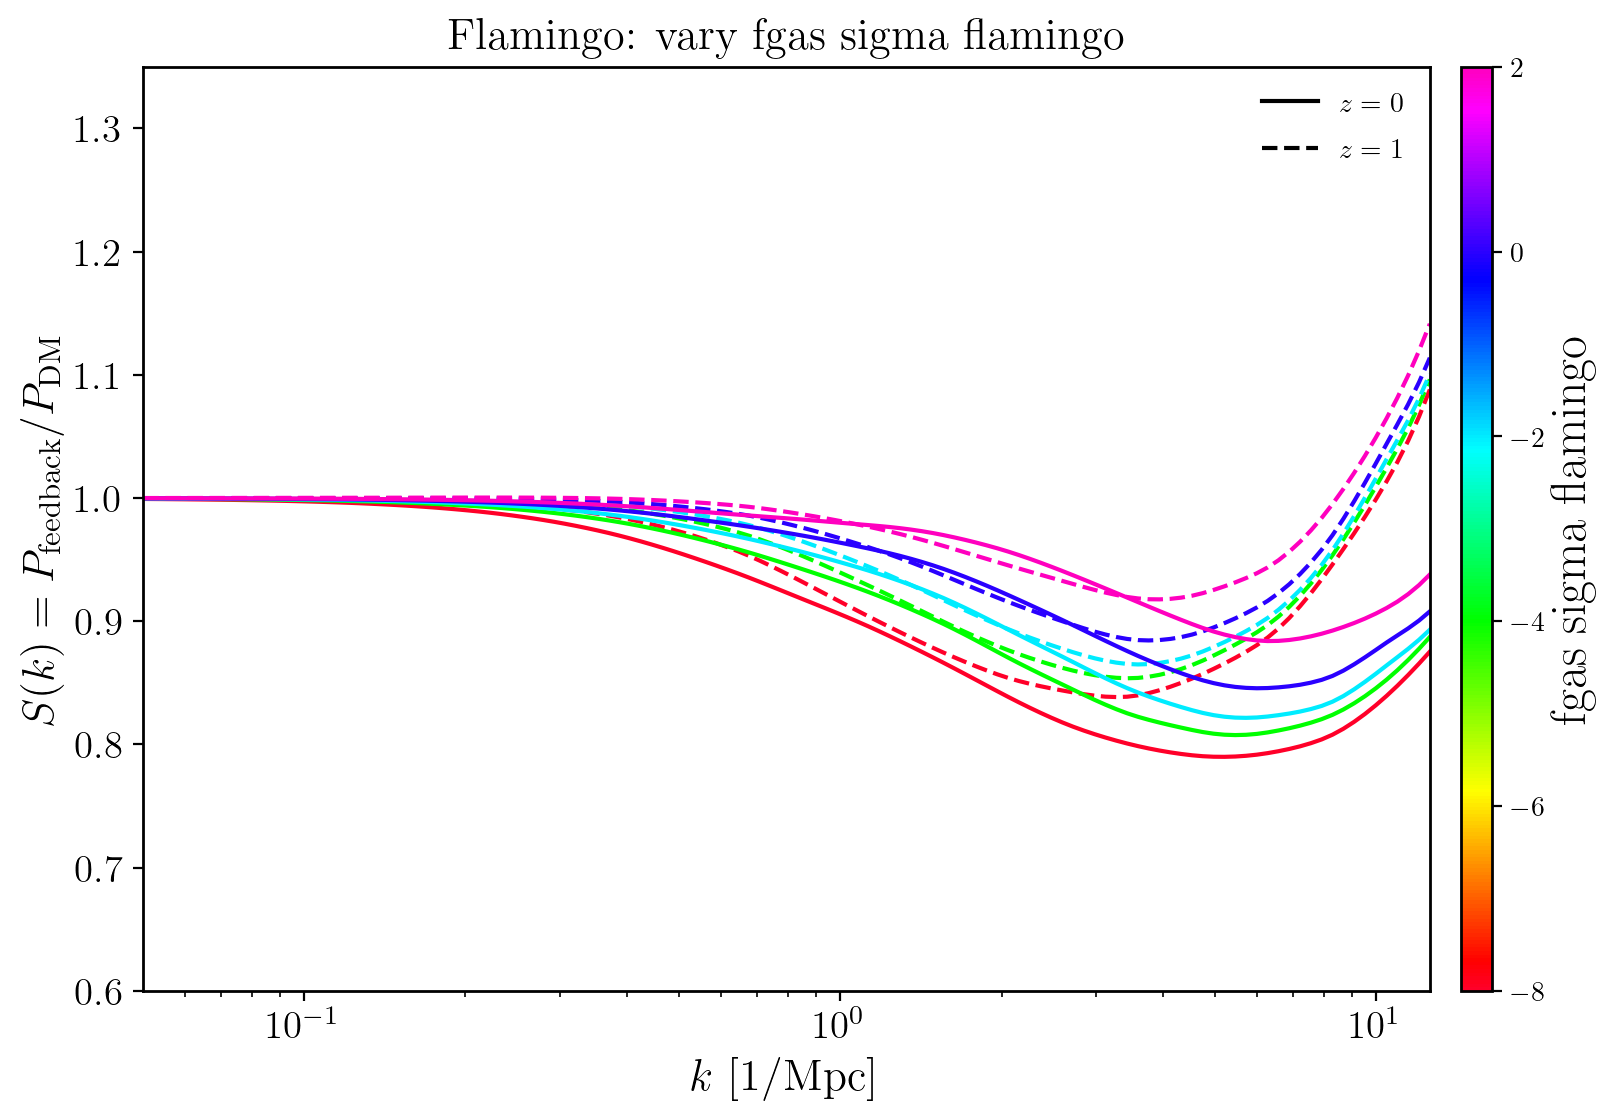

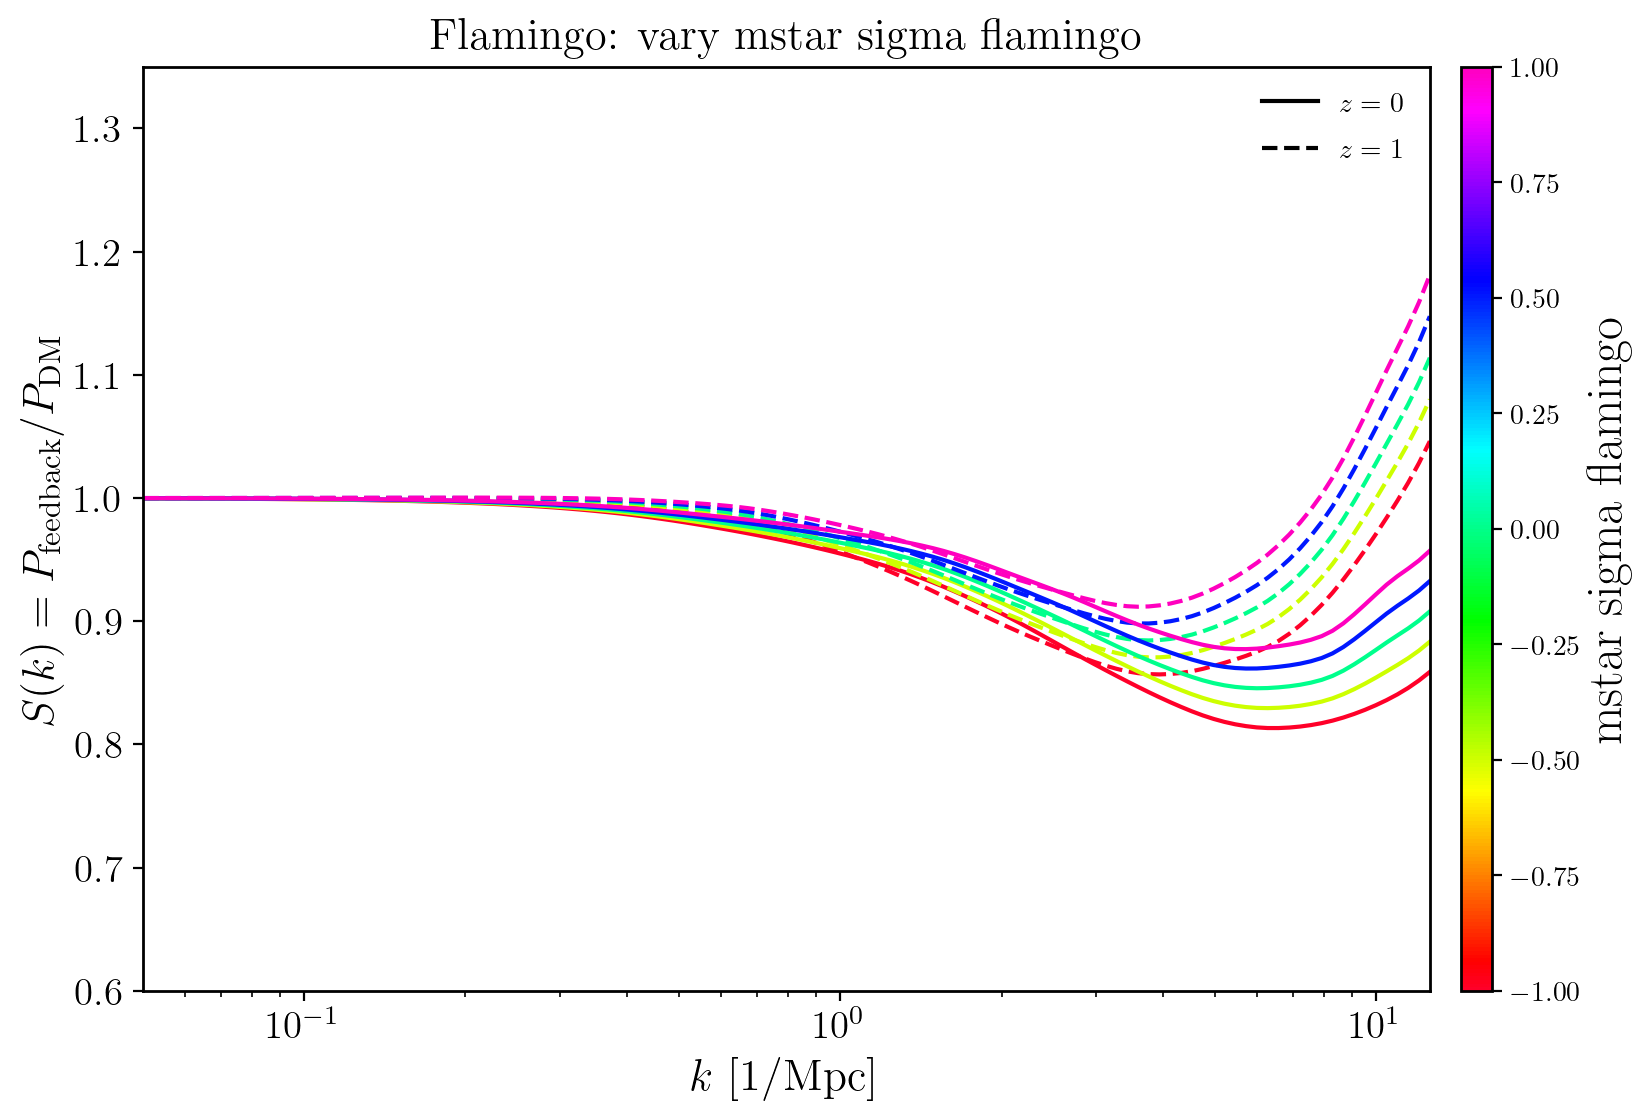

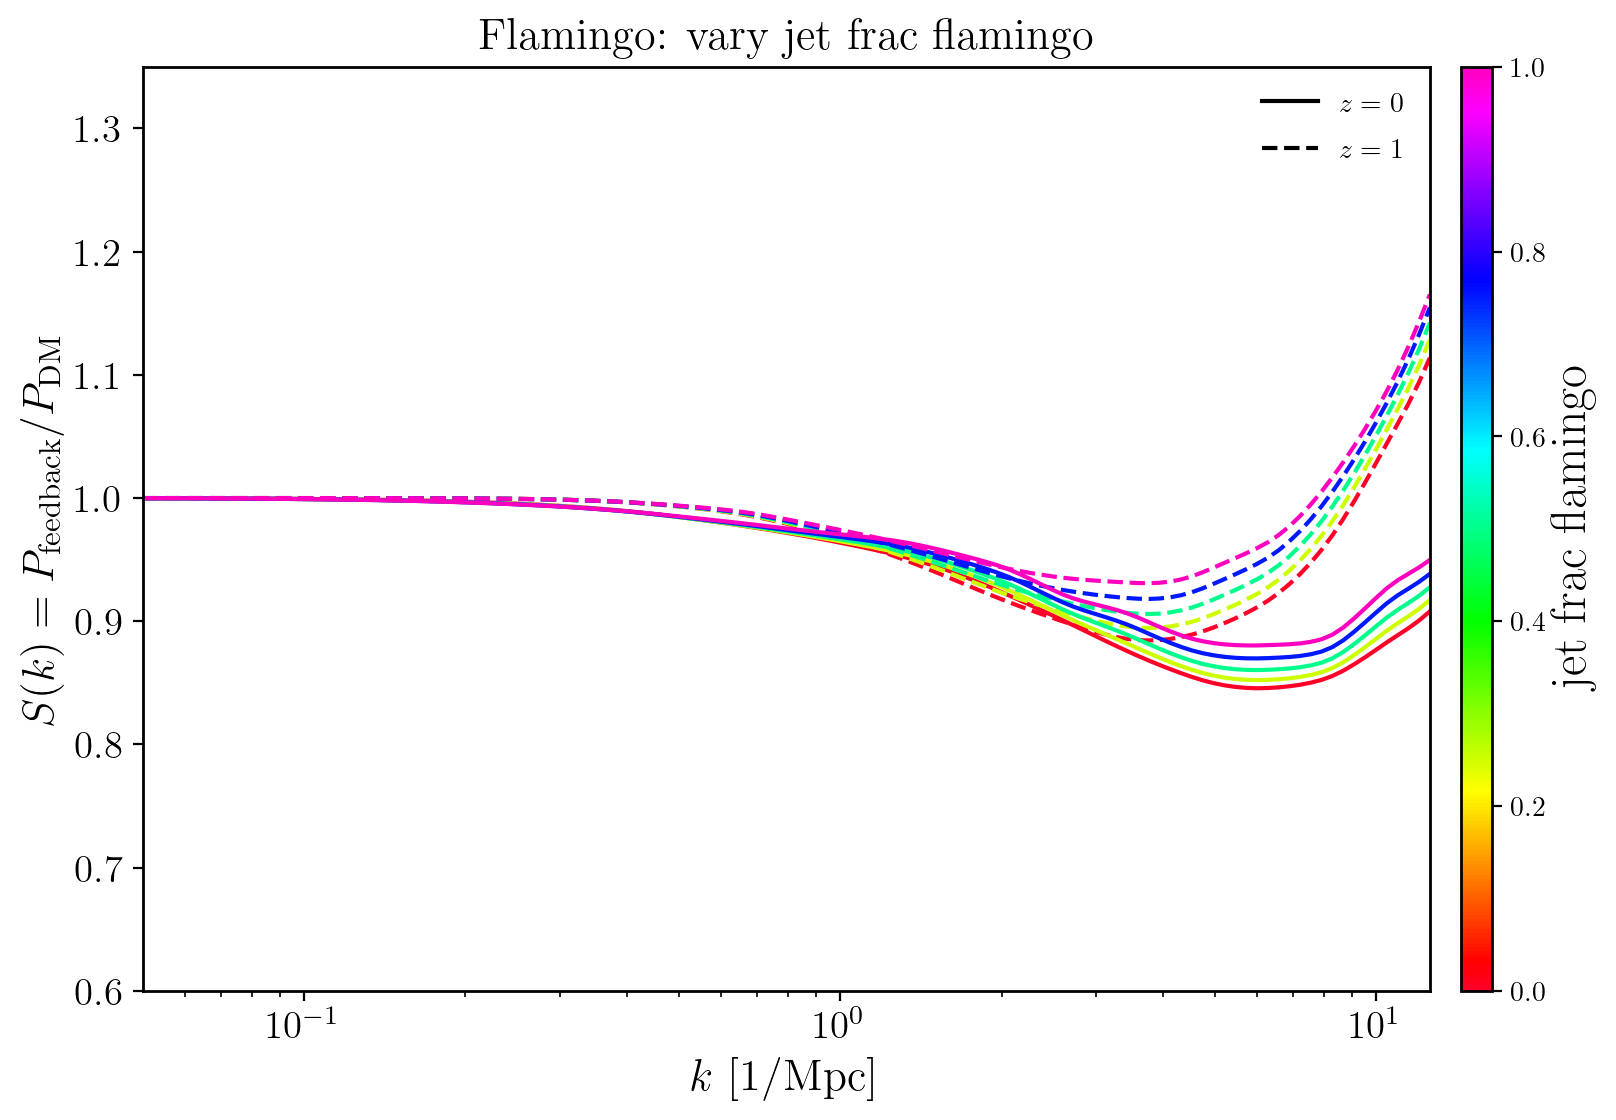

In [22]:
plot_sweeps("Flamingo")

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

...

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

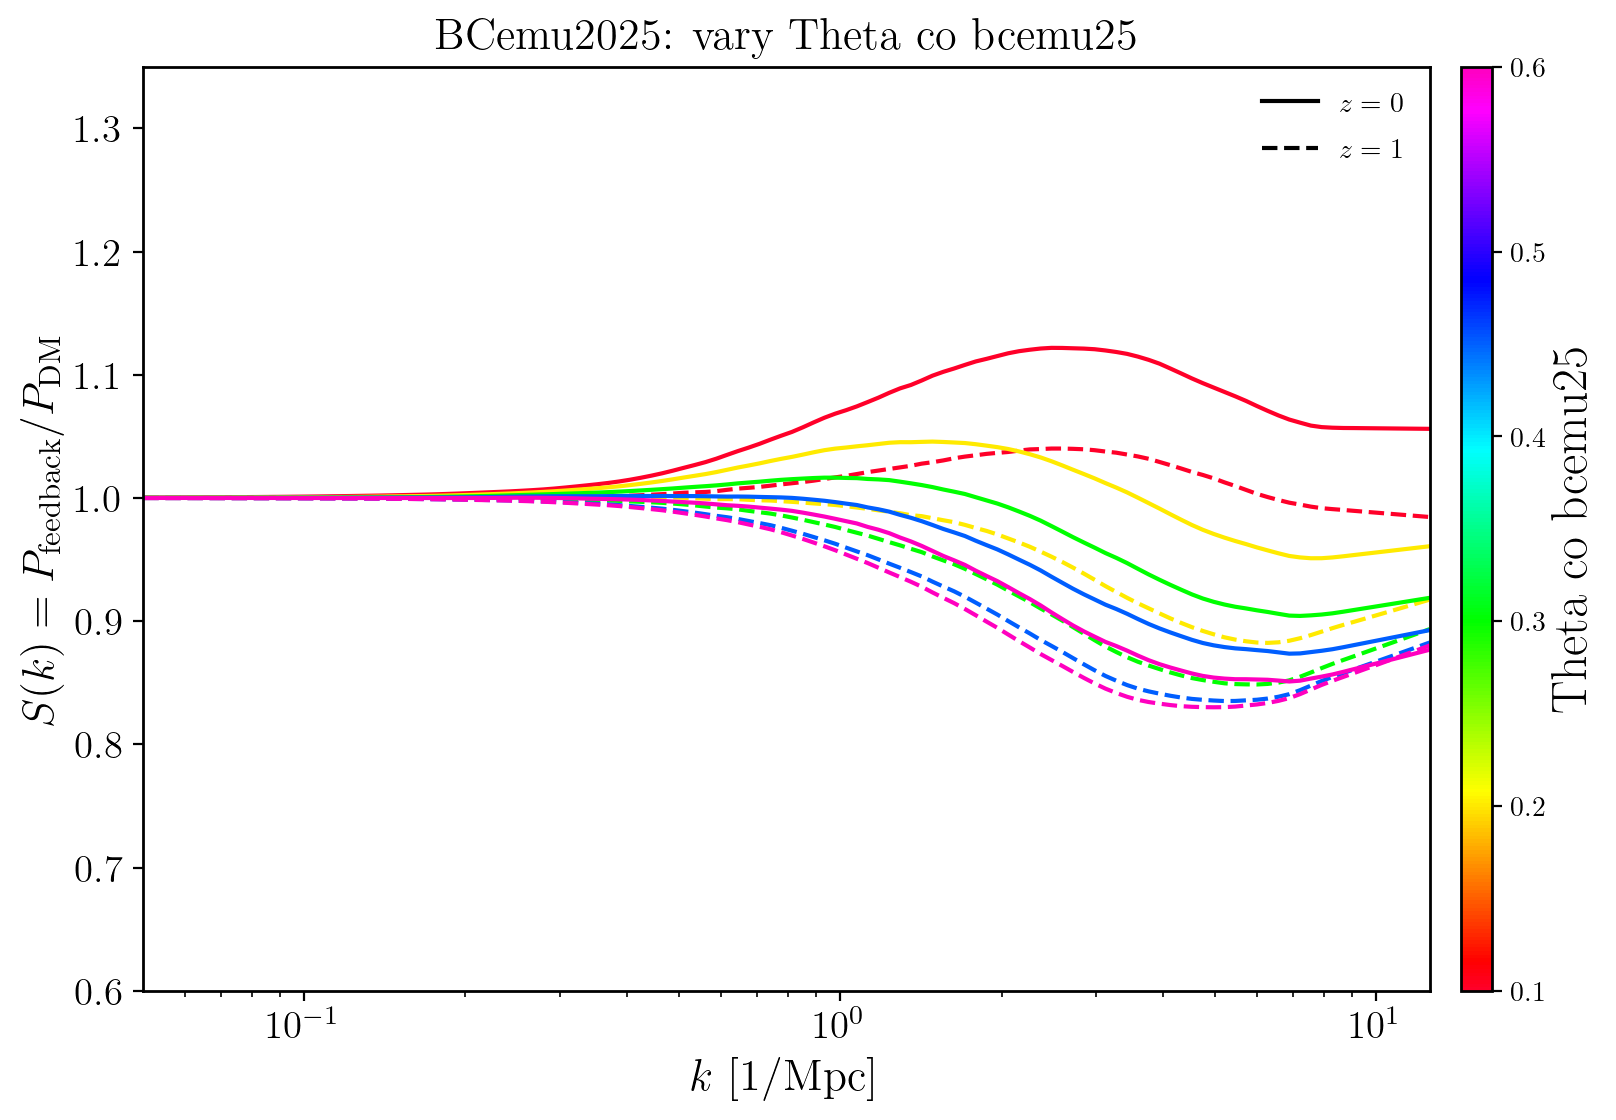

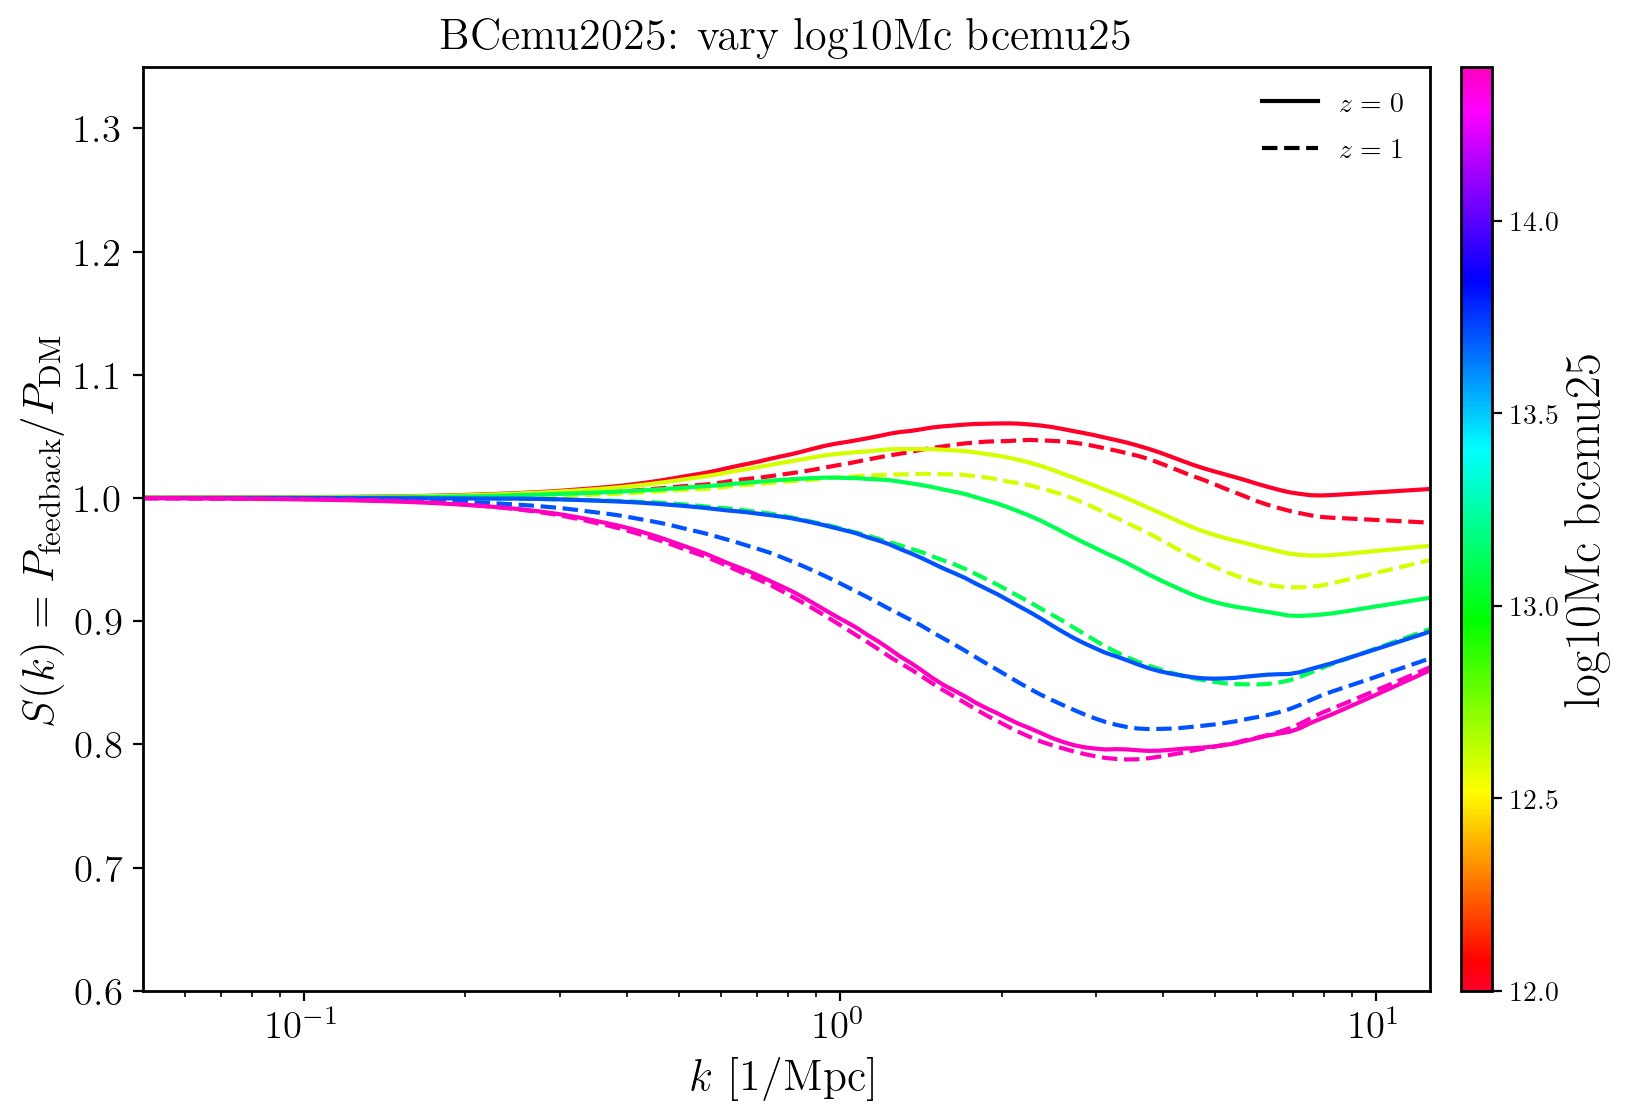

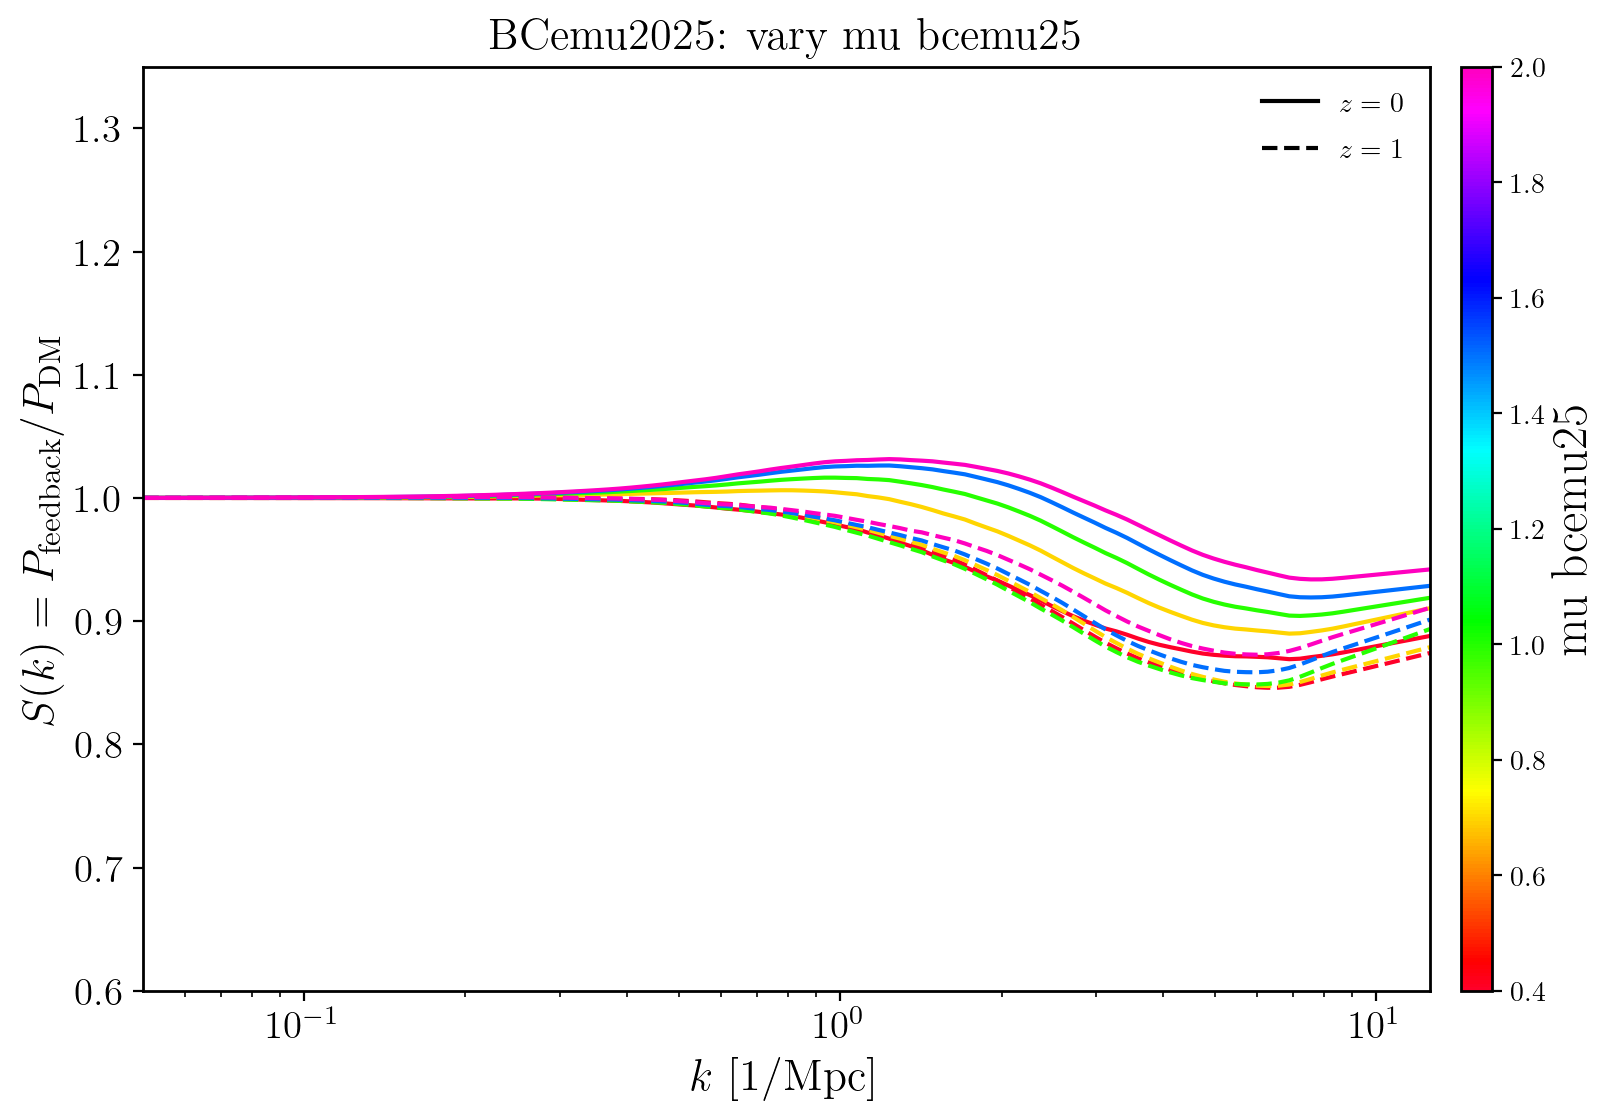

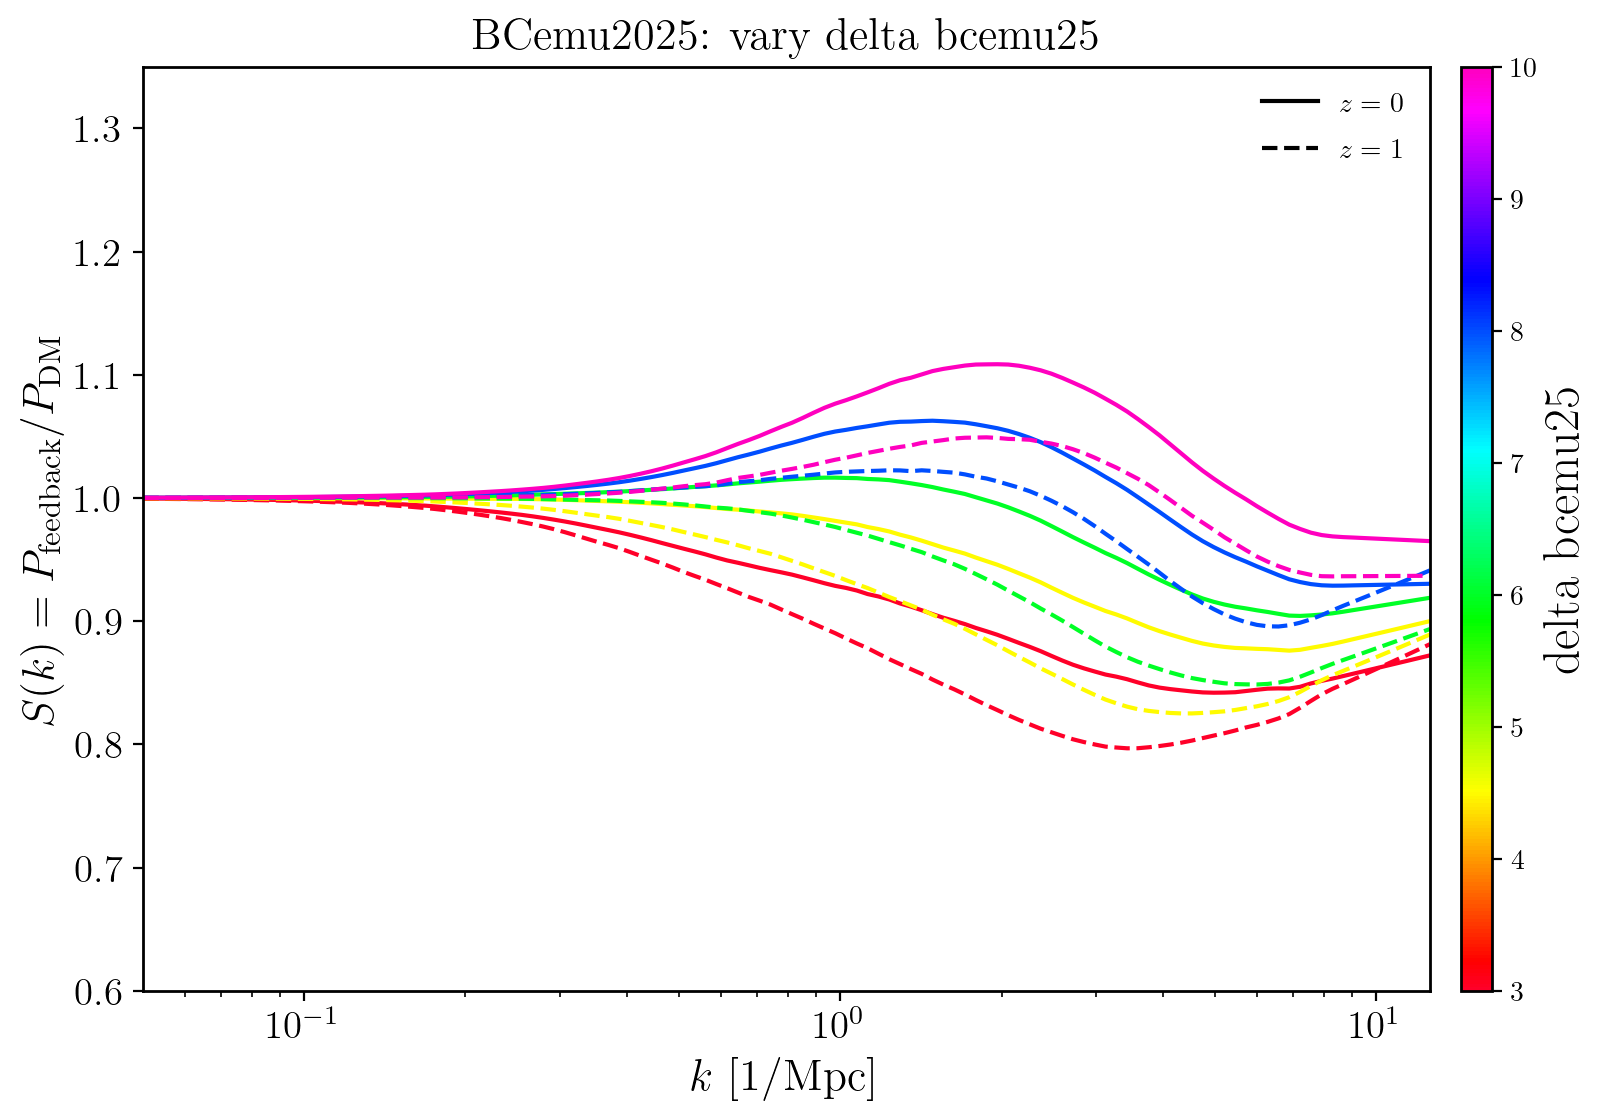

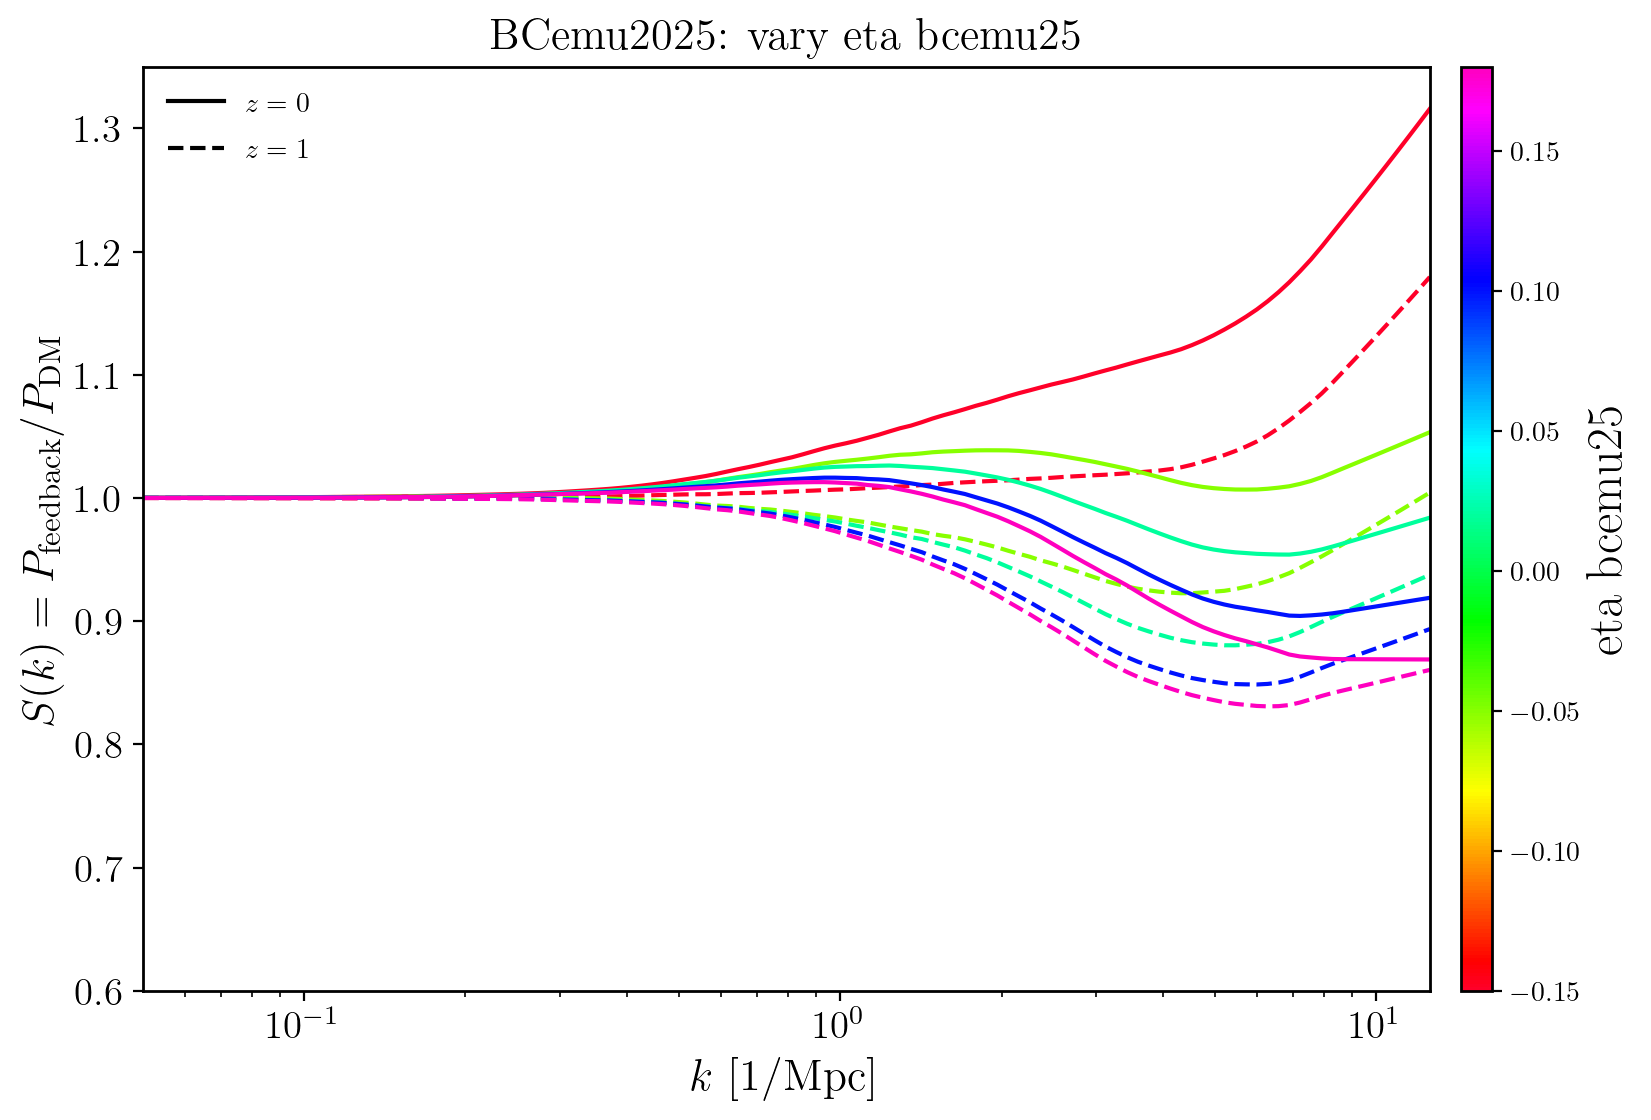

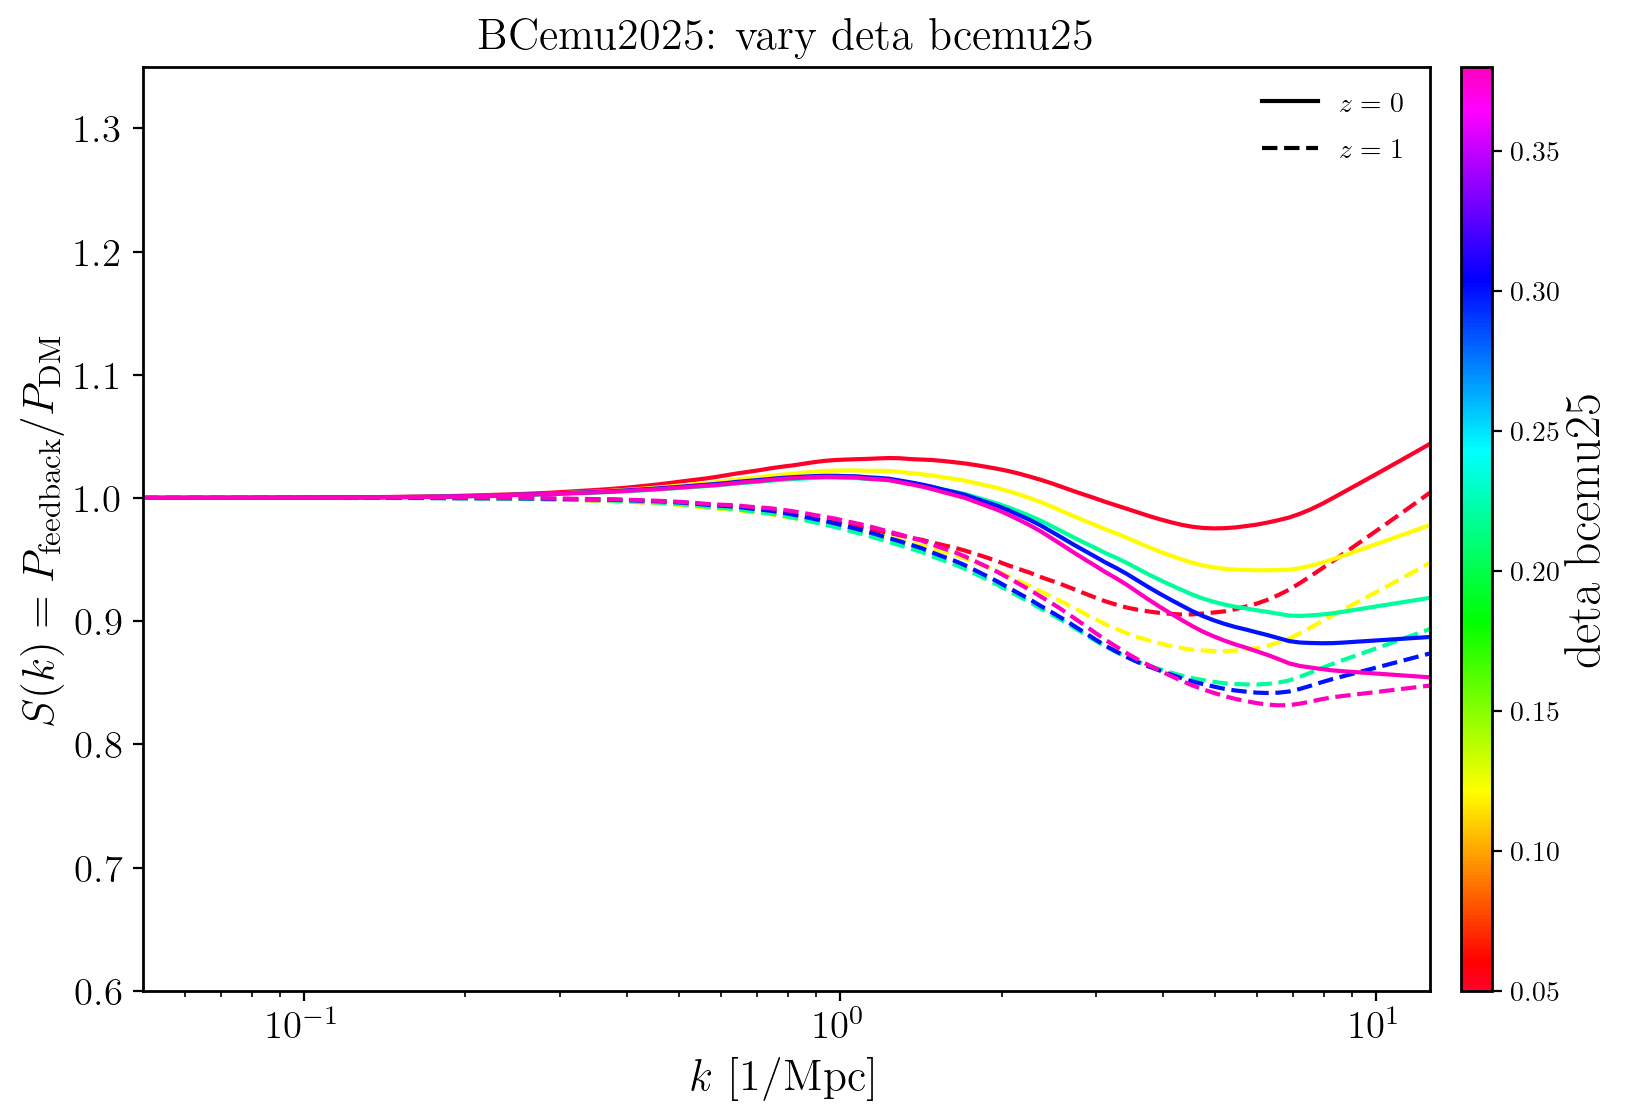

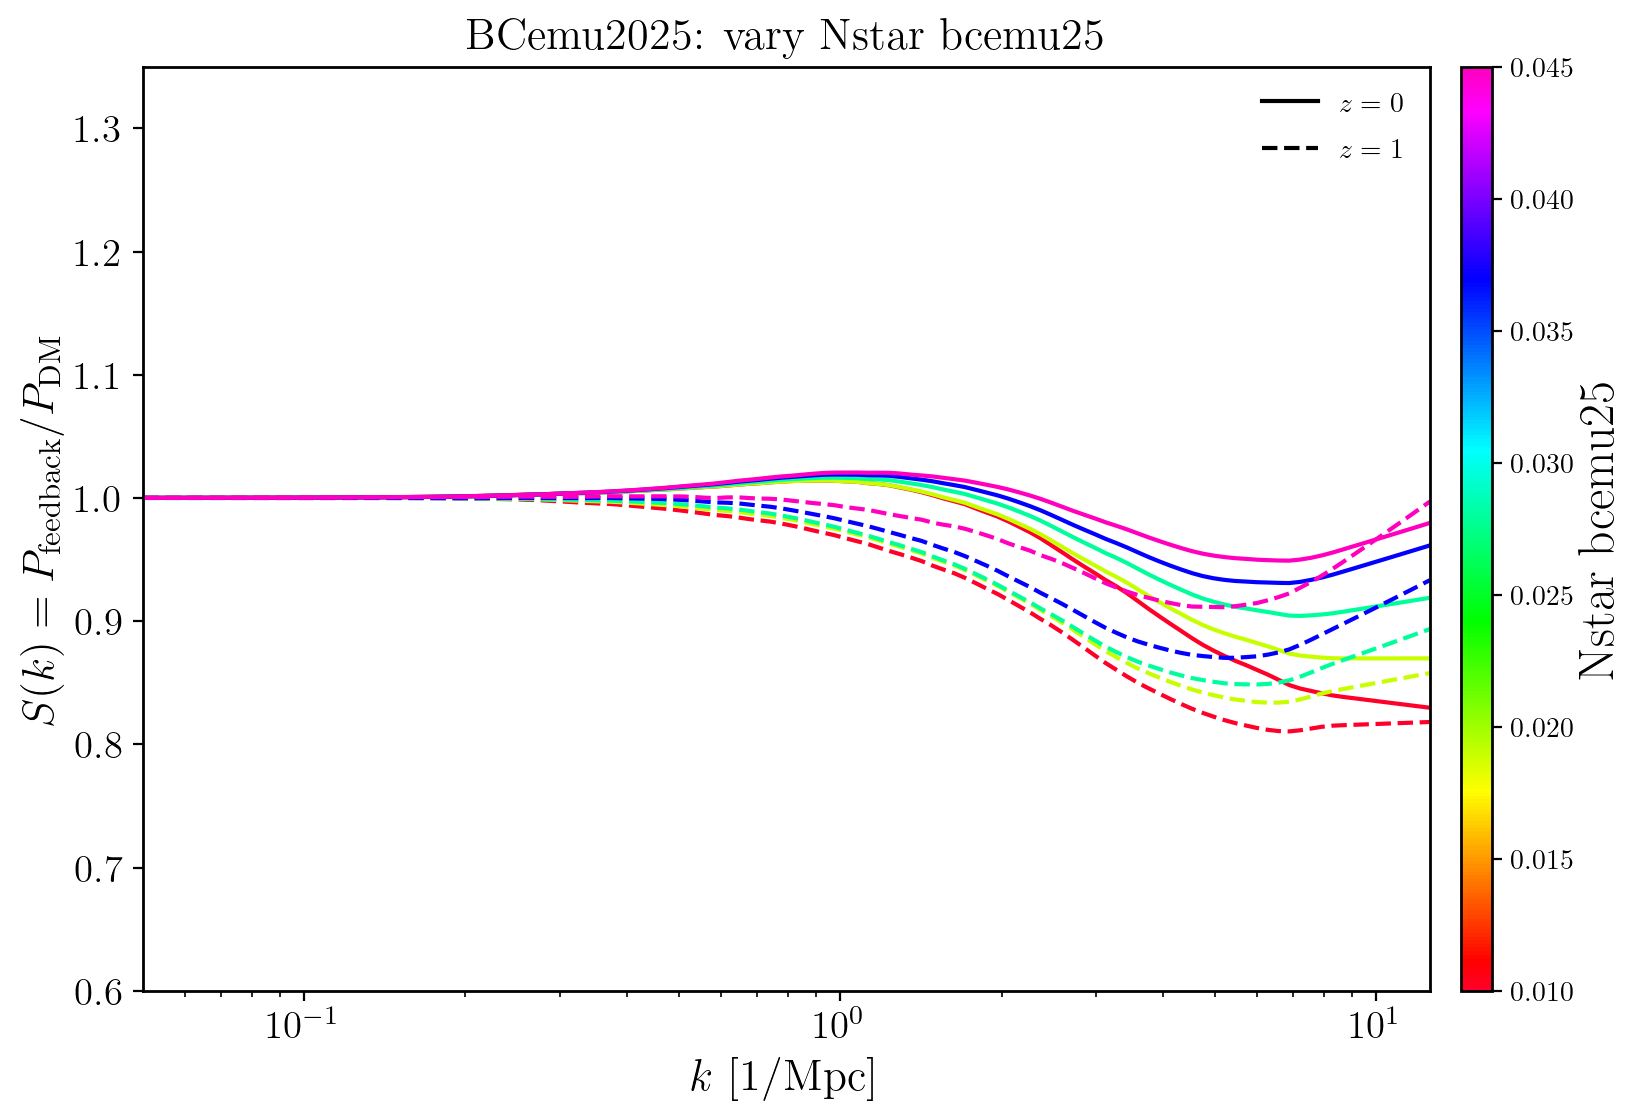

In [23]:
plot_sweeps("BCemu2025")